In [1]:
# Cell 1: Import all libraries
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

print("✅ Imports done")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Imports done
NumPy version: 2.3.5
Pandas version: 2.3.3


In [2]:
# Cell 2: Configuration 

N_STUDENTS = 1500

# Grade caps (no perfect scores in Algerian exams)
MAX_BREVET = 19.5
MAX_BAC = 19.7

# Filière proportions (based on real Algerian Bac)
FILIERES = {
    'sciences_experimentales': 0.42,
    'gestion_economie': 0.15,
    'langues_etrangeres': 0.12,
    'lettres_philosophie': 0.10,
    'techniques_maths': 0.11,
    'maths': 0.10
}

# Filière success rates (official 2024 data)
FILIERE_SUCCESS_RATE = {
    'maths': 0.8225,
    'langues_etrangeres': 0.6411,
    'sciences_experimentales': 0.6162,
    'techniques_maths': 0.60,
    'lettres_philosophie': 0.5247,
    'gestion_economie': 0.4738
}

# Techniques Maths specialties 
TECHNIQUES_SPECIALTIES = ['genie_electrique', 'genie_mecanique', 'genie_civil', 'genie_procedes']

# Reasons for choice
REASONS = ['interest', 'parents', 'friends', 'grades_pressure', 'academic_guidance']

# Learning styles 
LEARNING_STYLES = ['visual', 'auditory', 'practice_based', 'reading_writing']

# Regions 
REGIONS = ['algiers', 'oran', 'constantine', 'annaba', 'setif', 'tizi_ouzou', 'blida', 'bejaia', 'tlemcen', 'other']

# Regional performance boost (Kabylie effect)
KABYLE_REGIONS = ['tizi_ouzou', 'bejaia']
REGION_BOOST = {
    'tizi_ouzou': 1.15,
    'bejaia': 1.12,
    'algiers': 1.05,
    'oran': 1.03,
    'constantine': 1.02,
    'annaba': 1.00,
    'setif': 1.00,
    'blida': 1.00,
    'tlemcen': 1.00,
    'other': 0.98
}

print("✅ Configuration set")
print(f"Generating {N_STUDENTS} synthetic students")
print(f"Filière distribution: {FILIERES}")
print(f"Regional boost: {REGION_BOOST}")

✅ Configuration set
Generating 1500 synthetic students
Filière distribution: {'sciences_experimentales': 0.42, 'gestion_economie': 0.15, 'langues_etrangeres': 0.12, 'lettres_philosophie': 0.1, 'techniques_maths': 0.11, 'maths': 0.1}
Regional boost: {'tizi_ouzou': 1.15, 'bejaia': 1.12, 'algiers': 1.05, 'oran': 1.03, 'constantine': 1.02, 'annaba': 1.0, 'setif': 1.0, 'blida': 1.0, 'tlemcen': 1.0, 'other': 0.98}


In [3]:
# Cell 3: Helper functions

def generate_grade(mean, std, min_val=0, max_val=20):
    grade = np.random.normal(mean, std)
    return np.clip(grade, min_val, max_val)

def generate_study_hours(avg_grade, filiere):
    if avg_grade > 14:
        base_hours = np.random.randint(6, 12)
    elif avg_grade > 11:
        base_hours = np.random.randint(10, 18)
    elif avg_grade > 8:
        if np.random.random() < 0.6:
            base_hours = np.random.randint(15, 25)
        else:
            base_hours = np.random.randint(8, 15)
    else:
        if np.random.random() < 0.7:
            base_hours = np.random.randint(20, 30)
        else:
            base_hours = np.random.randint(5, 12)
    
    if filiere == 'maths':
        base_hours += np.random.randint(2, 5)
    
    return base_hours

def generate_private_tutoring(filiere, region):
    base_probability = 0.4
    
    if filiere == 'maths':
        base_probability += 0.3
    elif filiere in ['sciences_experimentales', 'techniques_maths']:
        base_probability += 0.15
    
    if region in KABYLE_REGIONS:
        base_probability += 0.1
    
    if region in ['algiers', 'oran', 'constantine']:
        base_probability += 0.1
    
    has_tutoring = np.random.random() < min(base_probability, 0.85)
    
    return np.random.randint(2, 10) if has_tutoring else 0

def generate_exam_anxiety(filiere, region, reason_for_choice):
    base_anxiety = np.random.randint(2, 5)
    
    if reason_for_choice in ['parents', 'grades_pressure']:
        base_anxiety += 1
    if filiere == 'maths':
        base_anxiety += 1
    if region in KABYLE_REGIONS:
        base_anxiety += 1
    
    return np.clip(base_anxiety, 1, 5)

def generate_bac_avg(as2_avg, study_consistency, weakness_count, region, tutoring_hours):
    bac = as2_avg
    
    if np.random.random() < 0.6:
        bac += np.random.uniform(0.5, 2.0)
    elif np.random.random() < 0.3:
        bac += np.random.uniform(-0.5, 0.5)
    else:
        bac -= np.random.uniform(0.5, 1.5)
    
    bac += (study_consistency - 0.5) * 1.5
    bac -= weakness_count * 0.8
    
    if region in KABYLE_REGIONS:
        bac += np.random.uniform(1.0, 2.0)
    
    if tutoring_hours > 0:
        bac += np.random.uniform(0.3, 0.8)
    
    bac += np.random.normal(0, 0.6)
    
    return np.clip(bac, 5, 20)

print("✅ Helper functions defined")

✅ Helper functions defined


In [4]:
# Cell 4: Create empty list to store student data
students = []
print("✅ Ready to generate students")

✅ Ready to generate students


In [5]:
# Cell 5: Generate CLEAN Algerian Bac Data with MEANINGFUL CLUSTERS

import numpy as np
import pandas as pd

print("=" * 60)
print("🎓 GENERATING CLEAN ALGERIAN BAC DATASET WITH MEANINGFUL CLUSTERS")
print("=" * 60)

# Configuration
N_STUDENTS = 1500
MAX_BREVET = 19.5
MAX_BAC = 19.5

# Filière proportions
FILIERES = {
    'sciences_experimentales': 0.42,
    'gestion_economie': 0.15,
    'langues_etrangeres': 0.12,
    'lettres_philosophie': 0.10,
    'techniques_maths': 0.11,
    'maths': 0.10
}

# ============================================
# PERFORMANCE TIERS FOR EACH FILIÈRE (THE KEY!)
# ============================================
# Each tier has: Bac mean, Bac std, percentage of students, and habit profile
PERFORMANCE_TIERS = {
    'sciences_experimentales': {
        'excellent': {'bac_mean': 17.5, 'bac_std': 0.5, 'pct': 0.03, 'habits': 'good'},
        'very_good': {'bac_mean': 15.5, 'bac_std': 0.5, 'pct': 0.09, 'habits': 'good'},
        'good': {'bac_mean': 13.5, 'bac_std': 0.5, 'pct': 0.20, 'habits': 'average'},
        'passable': {'bac_mean': 11.5, 'bac_std': 0.5, 'pct': 0.30, 'habits': 'average'},
        'failing': {'bac_mean': 8.5, 'bac_std': 0.7, 'pct': 0.38, 'habits': 'poor'}
    },
    'maths': {
        'excellent': {'bac_mean': 18.5, 'bac_std': 0.5, 'pct': 0.02, 'habits': 'good'},
        'very_good': {'bac_mean': 16.5, 'bac_std': 0.5, 'pct': 0.03, 'habits': 'good'},
        'good': {'bac_mean': 14.5, 'bac_std': 0.5, 'pct': 0.03, 'habits': 'average'},
        'average': {'bac_mean': 12.5, 'bac_std': 0.5, 'pct': 0.05, 'habits': 'average'},
        'weak': {'bac_mean': 10.0, 'bac_std': 0.6, 'pct': 0.87, 'habits': 'poor'}
    },
    'techniques_maths': {
        'excellent': {'bac_mean': 16.5, 'bac_std': 0.5, 'pct': 0.02, 'habits': 'good'},
        'good': {'bac_mean': 14.5, 'bac_std': 0.5, 'pct': 0.05, 'habits': 'good'},
        'average': {'bac_mean': 12.5, 'bac_std': 0.5, 'pct': 0.30, 'habits': 'average'},
        'weak': {'bac_mean': 10.0, 'bac_std': 0.6, 'pct': 0.63, 'habits': 'poor'}
    },
    'gestion_economie': {
        'good': {'bac_mean': 14.0, 'bac_std': 0.5, 'pct': 0.05, 'habits': 'good'},
        'average': {'bac_mean': 12.0, 'bac_std': 0.5, 'pct': 0.20, 'habits': 'average'},
        'weak': {'bac_mean': 10.0, 'bac_std': 0.5, 'pct': 0.75, 'habits': 'poor'}
    },
    'langues_etrangeres': {
        'good': {'bac_mean': 13.5, 'bac_std': 0.5, 'pct': 0.04, 'habits': 'good'},
        'average': {'bac_mean': 11.5, 'bac_std': 0.5, 'pct': 0.30, 'habits': 'average'},
        'weak': {'bac_mean': 9.5, 'bac_std': 0.6, 'pct': 0.66, 'habits': 'poor'}
    },
    'lettres_philosophie': {
        'good': {'bac_mean': 13.5, 'bac_std': 0.5, 'pct': 0.04, 'habits': 'good'},
        'average': {'bac_mean': 11.5, 'bac_std': 0.5, 'pct': 0.30, 'habits': 'average'},
        'weak': {'bac_mean': 9.5, 'bac_std': 0.6, 'pct': 0.66, 'habits': 'poor'}
    }
}

# Regions
REGIONS = ['algiers', 'oran', 'constantine', 'annaba', 'setif', 'tizi_ouzou', 'blida', 'bejaia', 'tlemcen', 'other']
KABYLE_REGIONS = ['tizi_ouzou', 'bejaia']

REASONS = ['interest', 'parents', 'friends', 'grades_pressure', 'academic_guidance']
LEARNING_STYLES = ['visual', 'auditory', 'practice_based', 'reading_writing']

# Initialize students list
students = []

# Set year difficulty
year_difficulty = np.random.choice([-0.8, -0.4, 0, 0.3, 0.6], p=[0.1, 0.2, 0.4, 0.2, 0.1])
print(f"📅 Year difficulty factor: {year_difficulty:+.1f} points")

for student_id in range(N_STUDENTS):
    
    # ============================================
    # 1. IDENTITY
    # ============================================
    gender = np.random.choice(['M', 'F'])
    region = np.random.choice(REGIONS)
    is_repeater = np.random.random() < 0.08
    filiere = np.random.choice(list(FILIERES.keys()), p=list(FILIERES.values()))
    
    # ============================================
    # 2. ASSIGN PERFORMANCE TIER (THIS IS KEY FOR CLEAN CLUSTERS!)
    # ============================================
    tiers = PERFORMANCE_TIERS[filiere]
    tier_names = list(tiers.keys())
    tier_probs = [tiers[t]['pct'] for t in tier_names]
    tier = np.random.choice(tier_names, p=tier_probs)
    
    # Get tier parameters
    bac_mean = tiers[tier]['bac_mean']
    bac_std = tiers[tier]['bac_std']
    habit_profile = tiers[tier]['habits']
    
    # ============================================
    # 3. GENERATE BAC GRADE (FROM TIER)
    # ============================================
    bac_avg = np.random.normal(bac_mean, bac_std)
    bac_avg = np.clip(bac_avg, 5, MAX_BAC)
    
    # Apply year difficulty
    bac_avg += year_difficulty
    bac_avg = np.clip(bac_avg, 5, MAX_BAC)
    
    # Determine mention
    if bac_avg >= 18:
        mention = 'excellent'
    elif bac_avg >= 16:
        mention = 'tres_bien'
    elif bac_avg >= 14:
        mention = 'bien'
    elif bac_avg >= 12:
        mention = 'assez_bien'
    elif bac_avg >= 10:
        mention = 'passable'
    else:
        mention = 'echec'
    
    # ============================================
    # 4. GENERATE HABITS BASED ON PERFORMANCE TIER
    # ============================================
    if habit_profile == 'good':
        sleep_hours = np.random.choice([7, 8, 9], p=[0.3, 0.5, 0.2])
        study_consistency = np.random.uniform(0.75, 0.95)
        stress_level = np.random.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
        exam_anxiety = np.random.choice([1, 2, 3], p=[0.3, 0.5, 0.2])
        family_support = np.random.choice([4, 5], p=[0.6, 0.4])
        health_state = np.random.choice([4, 5], p=[0.6, 0.4])
        weekly_study_hours = np.random.randint(8, 18)
        private_tutoring_hours = np.random.choice([0, 2, 4], p=[0.6, 0.3, 0.1])
        study_efficiency = np.random.uniform(1.1, 1.6)
        
    elif habit_profile == 'average':
        sleep_hours = np.random.choice([6, 7, 8], p=[0.3, 0.4, 0.3])
        study_consistency = np.random.uniform(0.5, 0.75)
        stress_level = np.random.choice([2, 3, 4], p=[0.3, 0.5, 0.2])
        exam_anxiety = np.random.choice([2, 3, 4], p=[0.3, 0.5, 0.2])
        family_support = np.random.choice([3, 4], p=[0.5, 0.5])
        health_state = np.random.choice([3, 4], p=[0.5, 0.5])
        weekly_study_hours = np.random.randint(12, 22)
        private_tutoring_hours = np.random.choice([0, 2, 4, 6], p=[0.4, 0.3, 0.2, 0.1])
        study_efficiency = np.random.uniform(0.7, 1.1)
        
    else:  # poor
        sleep_hours = np.random.choice([5, 6, 7], p=[0.3, 0.5, 0.2])
        study_consistency = np.random.uniform(0.3, 0.55)
        stress_level = np.random.choice([3, 4, 5], p=[0.3, 0.5, 0.2])
        exam_anxiety = np.random.choice([3, 4, 5], p=[0.3, 0.5, 0.2])
        family_support = np.random.choice([2, 3], p=[0.5, 0.5])
        health_state = np.random.choice([2, 3], p=[0.5, 0.5])
        weekly_study_hours = np.random.randint(18, 35)
        private_tutoring_hours = np.random.choice([0, 2, 4, 6, 8], p=[0.3, 0.25, 0.2, 0.15, 0.1])
        study_efficiency = np.random.uniform(0.4, 0.7)
    
    # Regional boost
    if region in KABYLE_REGIONS:
        bac_avg += 0.8
        bac_avg = np.clip(bac_avg, 5, MAX_BAC)
    
    # Repeater penalty
    if is_repeater:
        bac_avg -= 0.8
        bac_avg = np.clip(bac_avg, 5, MAX_BAC)
    
    # ============================================
    # 5. GENERATE ALL GRADES FROM BAC (CONSISTENT!)
    # ============================================
    # A student's ability is reflected across ALL subjects
    subject_noise = 0.8  # Small noise, strong correlation
    
    # 2AS Grades (derived from Bac)
    as2_math = bac_avg + np.random.normal(0, subject_noise * 0.6)
    as2_physics = bac_avg + np.random.normal(0, subject_noise * 0.6)
    as2_science = bac_avg + np.random.normal(0, subject_noise * 0.6)
    as2_arabic = bac_avg + np.random.normal(0, subject_noise * 0.5)
    as2_langues = bac_avg + np.random.normal(0, subject_noise * 0.5)
    as2_hfada = bac_avg + np.random.normal(0, subject_noise * 0.5)
    
    # Clip to valid range
    for subj in ['as2_math', 'as2_physics', 'as2_science', 'as2_arabic', 'as2_langues', 'as2_hfada']:
        locals()[subj] = np.clip(locals()[subj], 4, MAX_BREVET)
    
    as2_avg_global = np.mean([as2_math, as2_physics, as2_science, as2_arabic, as2_langues, as2_hfada])
    as2_language_avg = (as2_arabic + as2_langues) / 2
    
    # 1AS Grades (slightly lower, transition shock)
    as1_math = as2_math - np.random.uniform(0.3, 0.8) + np.random.normal(0, 0.5)
    as1_physics = as2_physics - np.random.uniform(0.3, 0.8) + np.random.normal(0, 0.5)
    as1_science = as2_science - np.random.uniform(0.3, 0.8) + np.random.normal(0, 0.5)
    as1_arabic = as2_arabic - np.random.uniform(0.2, 0.6) + np.random.normal(0, 0.4)
    as1_langues = as2_langues - np.random.uniform(0.2, 0.6) + np.random.normal(0, 0.4)
    as1_hfada = as2_hfada - np.random.uniform(0.2, 0.6) + np.random.normal(0, 0.4)
    
    for subj in ['as1_math', 'as1_physics', 'as1_science', 'as1_arabic', 'as1_langues', 'as1_hfada']:
        locals()[subj] = np.clip(locals()[subj], 4, MAX_BREVET)
    
    as1_avg_global = np.mean([as1_math, as1_physics, as1_science, as1_arabic, as1_langues, as1_hfada])
    as1_language_avg = (as1_arabic + as1_langues) / 2
    
    # Brevet Grades (higher foundation)
    brevet_math = as1_math + np.random.uniform(0.5, 1.5) + np.random.normal(0, 0.4)
    brevet_physics = as1_physics + np.random.uniform(0.5, 1.5) + np.random.normal(0, 0.4)
    brevet_science = as1_science + np.random.uniform(0.5, 1.5) + np.random.normal(0, 0.4)
    brevet_arabic = as1_arabic + np.random.uniform(0.3, 1.0) + np.random.normal(0, 0.3)
    brevet_langues = as1_langues + np.random.uniform(0.3, 1.0) + np.random.normal(0, 0.3)
    brevet_hfada = as1_hfada + np.random.uniform(0.3, 1.0) + np.random.normal(0, 0.3)
    
    for subj in ['brevet_math', 'brevet_physics', 'brevet_science', 'brevet_arabic', 'brevet_langues', 'brevet_hfada']:
        locals()[subj] = np.clip(locals()[subj], 10, MAX_BREVET)
    
    brevet_avg = np.mean([brevet_math, brevet_physics, brevet_science, brevet_arabic, brevet_langues, brevet_hfada])
    
    # ============================================
    # 6. IMPROVEMENT MOMENTUM
    # ============================================
    improvement_momentum = as2_avg_global - as1_avg_global
    
    # ============================================
    # 7. WEAKNESS VECTOR
    # ============================================
    weak_math = max(0, min(1, (15 - as2_math) / 15))
    weak_physics = max(0, min(1, (15 - as2_physics) / 15))
    weak_science = max(0, min(1, (15 - as2_science) / 15))
    weak_arabic = max(0, min(1, (15 - as2_arabic) / 15))
    weak_langues = max(0, min(1, (15 - as2_langues) / 15))
    weak_hfada = max(0, min(1, (15 - as2_hfada) / 15))
    
    weakness_count = sum([weak_math > 0.6, weak_physics > 0.6, weak_science > 0.6,
                          weak_arabic > 0.6, weak_langues > 0.6, weak_hfada > 0.6])
    
    problem_solving_gap = np.mean([weak_math, weak_physics])
    
    # Grade volatility
    grade_volatility = np.std([as2_math, as2_physics, as2_science, as2_arabic, as2_langues])
    subject_balance = grade_volatility
    
    # ============================================
    # 8. BEHAVIORAL METRICS (Post-hoc)
    # ============================================
    study_efficiency_calc = bac_avg / (weekly_study_hours + 0.1)
    grinder_index = weekly_study_hours / (study_efficiency_calc + 0.1)
    time_essential_subjects = np.random.randint(5, 20)
    time_non_essential = max(0, weekly_study_hours - time_essential_subjects)
    time_allocation_ratio = time_essential_subjects / (time_non_essential + 0.1)
    resource_reliance = private_tutoring_hours / (weekly_study_hours + 0.1)
    stress_performance_ratio = exam_anxiety / (bac_avg + 0.1)
    sleep_debt = max(0, 8 - sleep_hours)
    health_stress_index = (6 - health_state) * stress_level
    family_support_strength = family_support / 5
    consistent_weak = weakness_count * (1 - study_consistency)
    efficient_stressed = study_efficiency_calc * stress_performance_ratio
    
    # Filière alignment
    science_avg = (as2_math + as2_physics + as2_science) / 3
    language_avg = (as2_arabic + as2_langues) / 2
    if filiere in ['maths', 'sciences_experimentales', 'techniques_maths']:
        filiere_alignment = science_avg / 20
    elif filiere in ['langues_etrangeres', 'lettres_philosophie']:
        filiere_alignment = language_avg / 20
    else:
        filiere_alignment = (science_avg + language_avg) / 40
    
    kabylie_boost_flag = 1 if region in KABYLE_REGIONS else 0
    repeater_penalty_flag = 1 if is_repeater else 0
    
    # Reason for choice
    reason_for_choice = np.random.choice(REASONS, p=[0.40, 0.25, 0.10, 0.15, 0.10])
    learning_style = np.random.choice(LEARNING_STYLES)
    comprehension_speed = int(np.clip(np.random.normal(3 + (bac_avg - 10) / 5, 1), 1, 5))
    focus_level = int(np.clip(np.random.normal(3 + (bac_avg - 10) / 5, 1), 1, 5))
    
    # ============================================
    # 9. STORE STUDENT DATA
    # ============================================
    student = {
        'student_id': student_id,
        'gender': gender,
        'region': region,
        'filiere': filiere,
        'reason_for_choice': reason_for_choice,
        'is_repeater': int(is_repeater),
        'brevet_avg': round(brevet_avg, 2),
        'brevet_math': round(brevet_math, 2),
        'brevet_physics': round(brevet_physics, 2),
        'brevet_science': round(brevet_science, 2),
        'brevet_arabic': round(brevet_arabic, 2),
        'brevet_langues': round(brevet_langues, 2),
        'brevet_hfada': round(brevet_hfada, 2),
        'as1_avg_global': round(as1_avg_global, 2),
        'as1_math': round(as1_math, 2),
        'as1_physics': round(as1_physics, 2),
        'as1_science': round(as1_science, 2),
        'as1_arabic': round(as1_arabic, 2),
        'as1_langues': round(as1_langues, 2),
        'as1_language_avg': round(as1_language_avg, 2),
        'as1_hfada': round(as1_hfada, 2),
        'as2_avg_global': round(as2_avg_global, 2),
        'as2_math': round(as2_math, 2),
        'as2_physics': round(as2_physics, 2),
        'as2_science': round(as2_science, 2),
        'as2_arabic': round(as2_arabic, 2),
        'as2_langues': round(as2_langues, 2),
        'as2_language_avg': round(as2_language_avg, 2),
        'as2_hfada': round(as2_hfada, 2),
        'weekly_study_hours': weekly_study_hours,
        'study_consistency': round(study_consistency, 2),
        'time_essential_subjects': time_essential_subjects,
        'time_non_essential_subjects': time_non_essential,
        'private_tutoring_hours': private_tutoring_hours,
        'exam_anxiety': exam_anxiety,
        'health_state': health_state,
        'family_support_score': family_support,
        'learning_style': learning_style,
        'comprehension_speed': comprehension_speed,
        'focus_level': focus_level,
        'weak_math': round(weak_math, 2),
        'weak_physics': round(weak_physics, 2),
        'weak_science': round(weak_science, 2),
        'weak_arabic': round(weak_arabic, 2),
        'weak_langues': round(weak_langues, 2),
        'weak_hfada': round(weak_hfada, 2),
        'problem_solving_gap': round(problem_solving_gap, 2),
        'sleep_hours': sleep_hours,
        'stress_level': stress_level,
        'bac_avg': round(bac_avg, 2),
        'bac_mention': mention,
        'study_efficiency': round(study_efficiency_calc, 2),
        'grinder_index': round(grinder_index, 2),
        'time_allocation_ratio': round(time_allocation_ratio, 2),
        'resource_reliance': round(resource_reliance, 2),
        'improvement_momentum': round(improvement_momentum, 2),
        'grade_volatility': round(grade_volatility, 2),
        'stress_performance_ratio': round(stress_performance_ratio, 2),
        'sleep_debt': sleep_debt,
        'health_stress_index': health_stress_index,
        'family_support_strength': round(family_support_strength, 2),
        'weakness_count': weakness_count,
        'subject_balance': round(subject_balance, 2),
        'filiere_alignment': round(filiere_alignment, 2),
        'consistent_weak': round(consistent_weak, 2),
        'efficient_stressed': round(efficient_stressed, 2),
        'repeater_penalty': repeater_penalty_flag,
        'kabylie_boost': kabylie_boost_flag
    }
    
    students.append(student)

print(f"\n✅ Generated {len(students)} students")
print(f"   - Repeaters: {sum([s.get('is_repeater', 0) for s in students])}")
print(f"   - Year difficulty: {year_difficulty:+.1f}")

# Quick validation
df_check = pd.DataFrame(students)
print(f"\n📊 Validation:")
print(f"   Bac range: {df_check['bac_avg'].min():.1f} - {df_check['bac_avg'].max():.1f}")

# Show distribution by filière and tier
print("\n📊 Performance Tier Distribution:")
for filiere in FILIERES.keys():
    print(f"\n{filiere}:")
    tiers = PERFORMANCE_TIERS[filiere]
    for tier_name, tier_info in tiers.items():
        expected_pct = tier_info['pct'] * 100
        print(f"   {tier_name}: target {expected_pct:.0f}%")

print("\n✅ Cell 5 complete! Run Cell 6 to create DataFrame.")

🎓 GENERATING CLEAN ALGERIAN BAC DATASET WITH MEANINGFUL CLUSTERS
📅 Year difficulty factor: +0.0 points

✅ Generated 1500 students
   - Repeaters: 133
   - Year difficulty: +0.0

📊 Validation:
   Bac range: 6.5 - 18.6

📊 Performance Tier Distribution:

sciences_experimentales:
   excellent: target 3%
   very_good: target 9%
   good: target 20%
   passable: target 30%
   failing: target 38%

gestion_economie:
   good: target 5%
   average: target 20%
   weak: target 75%

langues_etrangeres:
   good: target 4%
   average: target 30%
   weak: target 66%

lettres_philosophie:
   good: target 4%
   average: target 30%
   weak: target 66%

techniques_maths:
   excellent: target 2%
   good: target 5%
   average: target 30%
   weak: target 63%

maths:
   excellent: target 2%
   very_good: target 3%
   good: target 3%
   average: target 5%
   weak: target 87%

✅ Cell 5 complete! Run Cell 6 to create DataFrame.


In [6]:
# Cell 6: Convert to DataFrame
df = pd.DataFrame(students)

print(f"✅ DataFrame created: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n First 5 rows:")
df.head()

✅ DataFrame created: 1500 rows, 68 columns

 First 5 rows:


,student_id,gender,region,filiere,reason_for_choice,is_repeater,brevet_avg,brevet_math,brevet_physics,brevet_science,...,sleep_debt,health_stress_index,family_support_strength,weakness_count,subject_balance,filiere_alignment,consistent_weak,efficient_stressed,repeater_penalty,kabylie_boost
0,0,M,bejaia,sciences_experimentales,interest,0,15.54,14.63,16.80,15.55,...,2,12,0.6,0,0.43,0.75,0.0,0.09,0,1
1,1,M,oran,langues_etrangeres,academic_guidance,0,10.47,10.96,11.85,10.00,...,2,12,0.4,0,0.19,0.48,0.0,0.16,0,0
2,2,M,annaba,langues_etrangeres,grades_pressure,0,10.42,11.28,10.00,10.00,...,3,12,0.4,0,0.41,0.47,0.0,0.12,0,0
3,3,M,annaba,sciences_experimentales,friends,0,10.00,10.00,10.00,10.00,...,2,16,0.6,0,0.37,0.40,0.0,0.19,0,0
4,4,F,constantine,sciences_experimentales,interest,0,10.13,10.00,10.78,10.00,...,2,20,0.6,0,0.42,0.40,0.0,0.13,0,0


In [7]:
# Cell 7: Basic statistics
print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)

print("\n📊 Grade ranges:")
print(f"Brevet avg: {df['brevet_avg'].min():.1f} - {df['brevet_avg'].max():.1f}")
print(f"1AS avg: {df['as1_avg_global'].min():.1f} - {df['as1_avg_global'].max():.1f}")
print(f"2AS avg: {df['as2_avg_global'].min():.1f} - {df['as2_avg_global'].max():.1f}")
print(f"Bac avg: {df['bac_avg'].min():.1f} - {df['bac_avg'].max():.1f}")

print("\n📊 Filière distribution:")
print(df['filiere'].value_counts())

print("\n📊 Bac mention distribution:")
print(df['bac_mention'].value_counts())

print("\n📊 Study hours distribution:")
print(df['weekly_study_hours'].describe())

BASIC STATISTICS

📊 Grade ranges:
Brevet avg: 10.0 - 18.9
1AS avg: 5.5 - 18.2
2AS avg: 6.4 - 18.8
Bac avg: 6.5 - 18.6

📊 Filière distribution:
filiere
sciences_experimentales    637
langues_etrangeres         197
gestion_economie           196
techniques_maths           183
lettres_philosophie        150
maths                      137
Name: count, dtype: int64

📊 Bac mention distribution:
bac_mention
echec         614
passable      532
assez_bien    244
bien           86
tres_bien      21
excellent       3
Name: count, dtype: int64

📊 Study hours distribution:
count    1500.000000
mean       21.778667
std         6.634181
min         8.000000
25%        17.000000
50%        21.000000
75%        27.000000
max        34.000000
Name: weekly_study_hours, dtype: float64


In [8]:
# Cell 8: Save to CSV
df.to_csv('students_prebac_raw.csv', index=False)

print("✅ Dataset saved to 'students_prebac_raw.csv'")
print(f"File size: {df.shape[0]} students, {df.shape[1]} features")

# Show first 3 students as preview
print("\n📋 Preview of first 3 students:")
df.head(3).T  # Transposed for better viewing

✅ Dataset saved to 'students_prebac_raw.csv'
File size: 1500 students, 68 features

📋 Preview of first 3 students:


,0,1,2
student_id,0,1,2
gender,M,M,M
region,bejaia,oran,annaba
filiere,sciences_experimentales,langues_etrangeres,langues_etrangeres
reason_for_choice,interest,academic_guidance,grades_pressure
...,...,...,...
filiere_alignment,0.75,0.48,0.47
consistent_weak,0.0,0.0,0.0
efficient_stressed,0.09,0.16,0.12
repeater_penalty,0,0,0


In [9]:
# Cell 9: Check if correlations make sense
print("=" * 50)
print("CORRELATION CHECKS")
print("=" * 50)

# Brevet to 1AS correlation
corr_brevet_1as = df['brevet_avg'].corr(df['as1_avg_global'])
print(f"\n📈 Brevet → 1AS correlation: {corr_brevet_1as:.3f} (should be ~0.6-0.7)")

# 1AS to 2AS correlation
corr_1as_2as = df['as1_avg_global'].corr(df['as2_avg_global'])
print(f"📈 1AS → 2AS correlation: {corr_1as_2as:.3f} (should be ~0.7-0.8)")

# 2AS to Bac correlation
corr_2as_bac = df['as2_avg_global'].corr(df['bac_avg'])
print(f"📈 2AS → Bac correlation: {corr_2as_bac:.3f} (should be ~0.7-0.85)")

# Consistency to Bac
corr_consistency_bac = df['study_consistency'].corr(df['bac_avg'])
print(f"📈 Consistency → Bac correlation: {corr_consistency_bac:.3f} (should be positive)")

# Weak math to Bac (negative correlation expected)
corr_weak_bac = df['weak_math'].corr(df['bac_avg'])
print(f"📈 Weak math → Bac correlation: {corr_weak_bac:.3f} (should be negative)")

# Kabylie region to Bac (optional but useful)
if 'region' in df.columns:
    df['is_kabyle'] = df['region'].isin(['tizi_ouzou', 'bejaia']).astype(int)
    corr_region_bac = df['is_kabyle'].corr(df['bac_avg'])
    print(f"📈 Kabylie → Bac correlation: {corr_region_bac:.3f} (should be positive)")

CORRELATION CHECKS

📈 Brevet → 1AS correlation: 0.969 (should be ~0.6-0.7)
📈 1AS → 2AS correlation: 0.996 (should be ~0.7-0.8)
📈 2AS → Bac correlation: 0.996 (should be ~0.7-0.85)
📈 Consistency → Bac correlation: 0.758 (should be positive)
📈 Weak math → Bac correlation: -0.964 (should be negative)
📈 Kabylie → Bac correlation: 0.144 (should be positive)


In [10]:
# Cell 10: Load the generated CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('students_prebac_raw.csv')

print(f"✅ Loaded {len(df)} students")
print(f"📊 Columns: {df.shape[1]}")
print("\n First 3 rows:")
df.head(3)



✅ Loaded 1500 students
📊 Columns: 68

 First 3 rows:


,student_id,gender,region,filiere,reason_for_choice,is_repeater,brevet_avg,brevet_math,brevet_physics,brevet_science,...,sleep_debt,health_stress_index,family_support_strength,weakness_count,subject_balance,filiere_alignment,consistent_weak,efficient_stressed,repeater_penalty,kabylie_boost
0,0,M,bejaia,sciences_experimentales,interest,0,15.54,14.63,16.80,15.55,...,2,12,0.6,0,0.43,0.75,0.0,0.09,0,1
1,1,M,oran,langues_etrangeres,academic_guidance,0,10.47,10.96,11.85,10.00,...,2,12,0.4,0,0.19,0.48,0.0,0.16,0,0
2,2,M,annaba,langues_etrangeres,grades_pressure,0,10.42,11.28,10.00,10.00,...,3,12,0.4,0,0.41,0.47,0.0,0.12,0,0


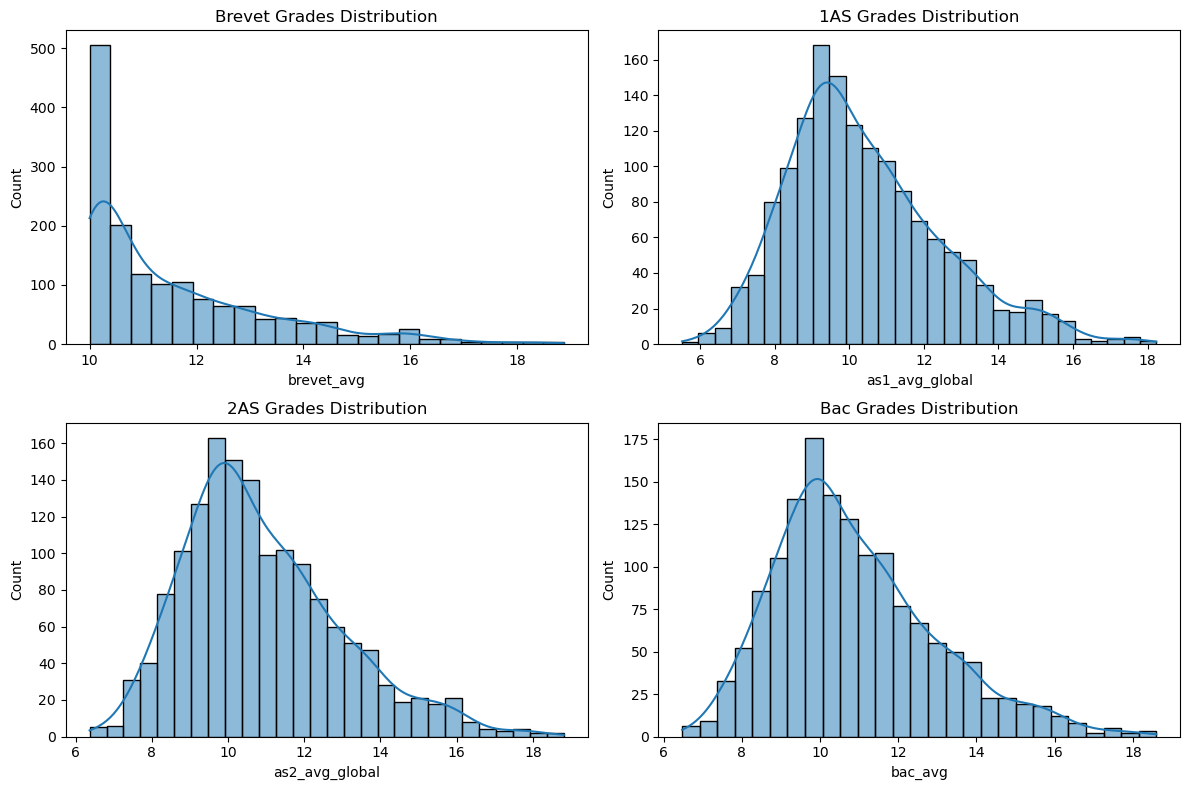

In [11]:
# cell 11.1 Grade distributions for each year
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['brevet_avg'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Brevet Grades Distribution')

sns.histplot(df['as1_avg_global'], kde=True, ax=axes[0,1])
axes[0,1].set_title('1AS Grades Distribution')

sns.histplot(df['as2_avg_global'], kde=True, ax=axes[1,0])
axes[1,0].set_title('2AS Grades Distribution')

sns.histplot(df['bac_avg'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Bac Grades Distribution')

plt.tight_layout()
plt.show()


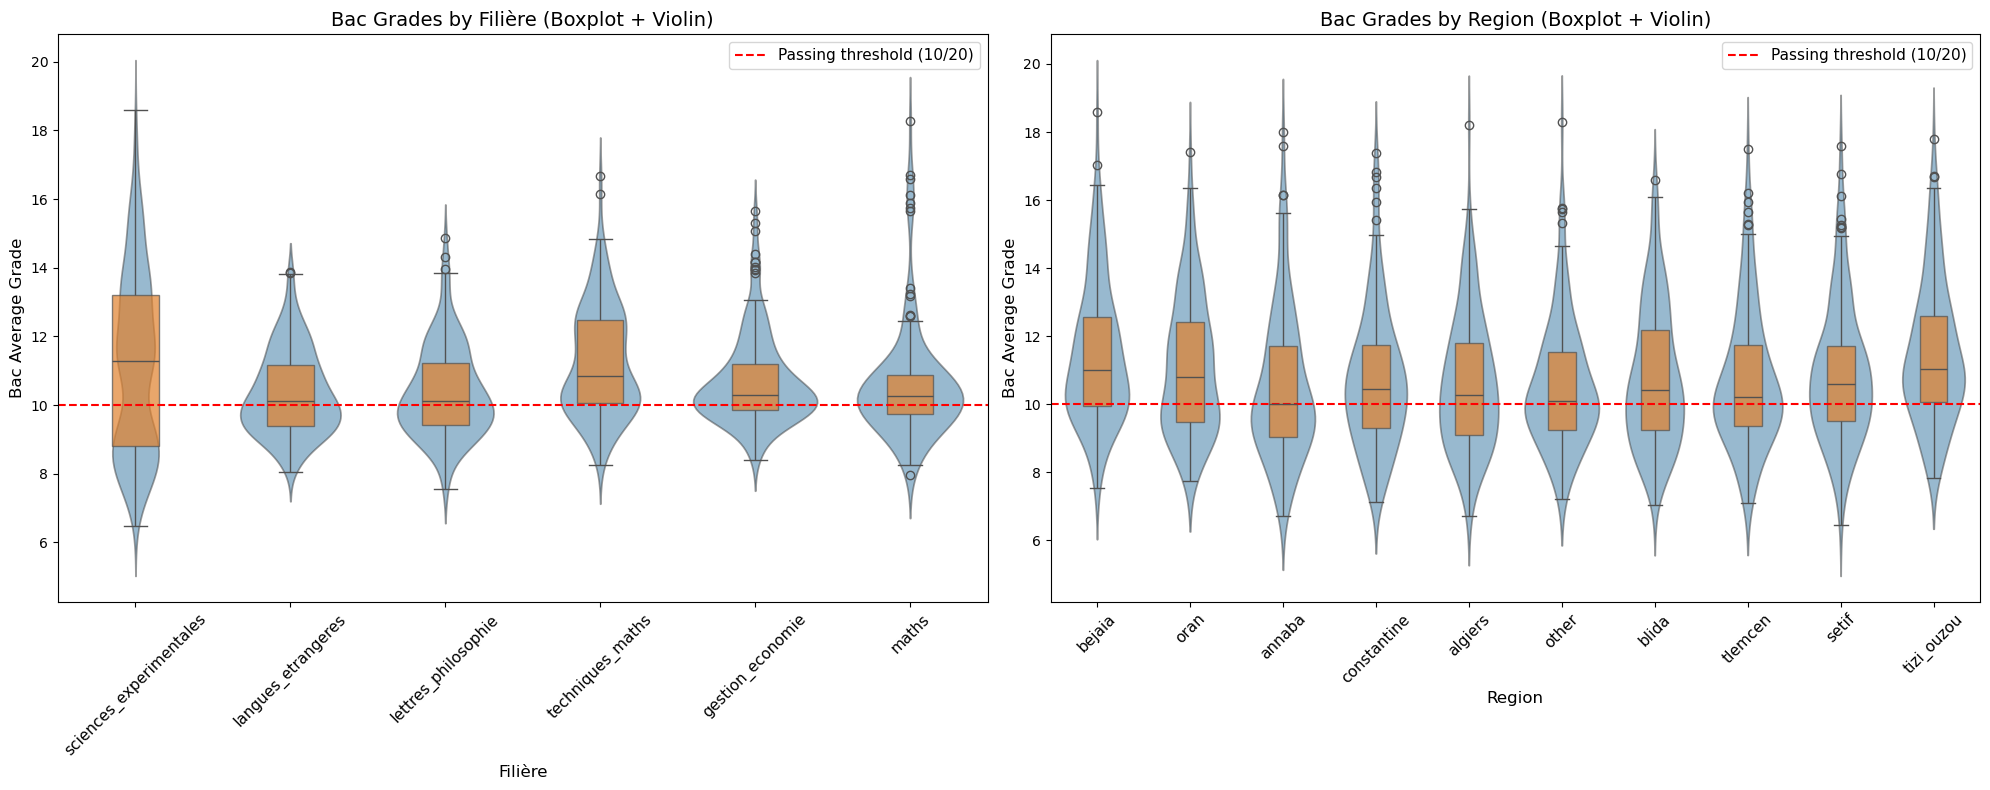


📊 Bac Grades by Filière (mean ± std):
  sciences_experimentales: 11.18 ± 2.64 | Success rate: 59.0%
  langues_etrangeres: 10.35 ± 1.21 | Success rate: 53.8%
  lettres_philosophie: 10.39 ± 1.34 | Success rate: 54.7%
  techniques_maths: 11.24 ± 1.58 | Success rate: 76.5%
  gestion_economie: 10.69 ± 1.30 | Success rate: 67.3%
  maths: 10.60 ± 1.69 | Success rate: 60.6%

📊 Bac Grades by Region (mean ± std):
  bejaia: 11.46 ± 2.05 ⭐ KABYLE
  oran: 11.09 ± 2.00 
  annaba: 10.51 ± 2.19 
  constantine: 10.73 ± 2.06 
  algiers: 10.61 ± 1.97 
  other: 10.56 ± 1.86 
  blida: 10.79 ± 2.05 
  tlemcen: 10.73 ± 2.04 
  setif: 10.90 ± 2.03 
  tizi_ouzou: 11.48 ± 2.06 ⭐ KABYLE


In [12]:
# Cell 11.2 - Bac Grades by Filière and Region (Boxplot + Violin together)

# Create a figure with 2 subplots - LARGER SIZE
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Bac by Filière (Boxplot + Violin together)
sns.violinplot(x='filiere', y='bac_avg', data=df, ax=axes[0], alpha=0.5, inner=None)
sns.boxplot(x='filiere', y='bac_avg', data=df, ax=axes[0], width=0.3, boxprops=dict(alpha=0.7))
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].set_title('Bac Grades by Filière (Boxplot + Violin)', fontsize=14)
axes[0].set_xlabel('Filière', fontsize=12)
axes[0].set_ylabel('Bac Average Grade', fontsize=12)
axes[0].axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Passing threshold (10/20)')
axes[0].legend(fontsize=11)

# Plot 2: Bac by Region (Boxplot + Violin together)
sns.violinplot(x='region', y='bac_avg', data=df, ax=axes[1], alpha=0.5, inner=None)
sns.boxplot(x='region', y='bac_avg', data=df, ax=axes[1], width=0.3, boxprops=dict(alpha=0.7))
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].set_title('Bac Grades by Region (Boxplot + Violin)', fontsize=14)
axes[1].set_xlabel('Region', fontsize=12)
axes[1].set_ylabel('Bac Average Grade', fontsize=12)
axes[1].axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Passing threshold (10/20)')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Per-filière statistics
print("\n📊 Bac Grades by Filière (mean ± std):")
for filiere in df['filiere'].unique():
    mean_grade = df[df['filiere'] == filiere]['bac_avg'].mean()
    std_grade = df[df['filiere'] == filiere]['bac_avg'].std()
    success_rate = (df[df['filiere'] == filiere]['bac_avg'] >= 10).mean() * 100
    print(f"  {filiere}: {mean_grade:.2f} ± {std_grade:.2f} | Success rate: {success_rate:.1f}%")

# Per-region statistics with Kabylie highlight
print("\n📊 Bac Grades by Region (mean ± std):")
kabyle_regions = ['tizi_ouzou', 'bejaia']
for region in df['region'].unique():
    mean_grade = df[df['region'] == region]['bac_avg'].mean()
    std_grade = df[df['region'] == region]['bac_avg'].std()
    is_kabyle = "⭐ KABYLE" if region in kabyle_regions else ""
    print(f"  {region}: {mean_grade:.2f} ± {std_grade:.2f} {is_kabyle}")

📊 Using 33 columns for heatmap


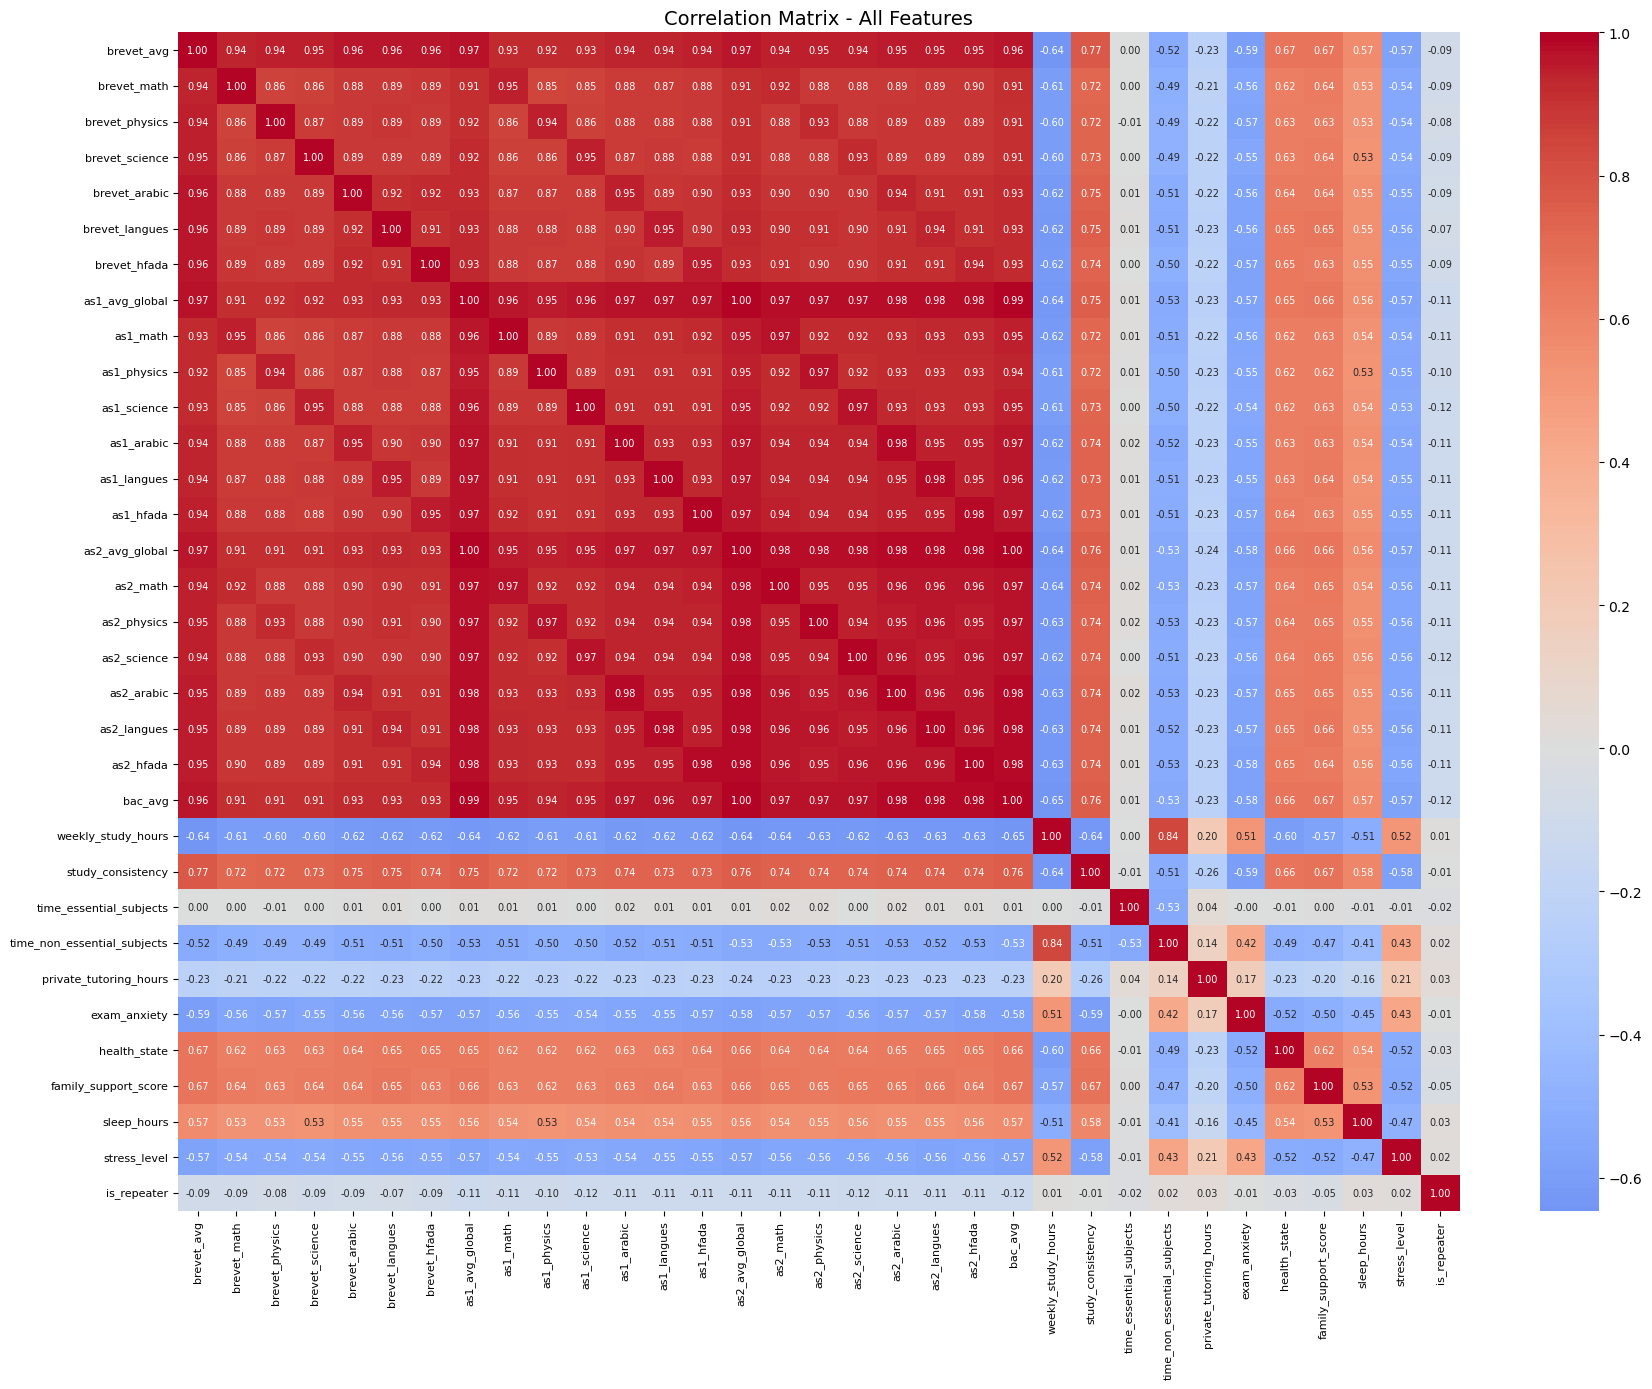

In [13]:
# Cell 11.3 Correlation Heatmap

# All relevant numeric columns
all_features = [
    'brevet_avg', 'brevet_math', 'brevet_physics', 'brevet_science', 'brevet_arabic', 'brevet_langues', 'brevet_hfada',
    'as1_avg_global', 'as1_math', 'as1_physics', 'as1_science', 'as1_arabic', 'as1_langues', 'as1_hfada',
    'as2_avg_global', 'as2_math', 'as2_physics', 'as2_science', 'as2_arabic', 'as2_langues', 'as2_hfada',
    'bac_avg',
    'weekly_study_hours', 'study_consistency', 'time_essential_subjects', 'time_non_essential_subjects',
    'private_tutoring_hours', 'exam_anxiety', 'health_state', 'family_support_score',
    'sleep_hours', 'stress_level', 'is_repeater'
]

# Only keep columns that exist
existing_cols = [col for col in all_features if col in df.columns]

print(f"📊 Using {len(existing_cols)} columns for heatmap")

# Create heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df[existing_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Matrix - All Features', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

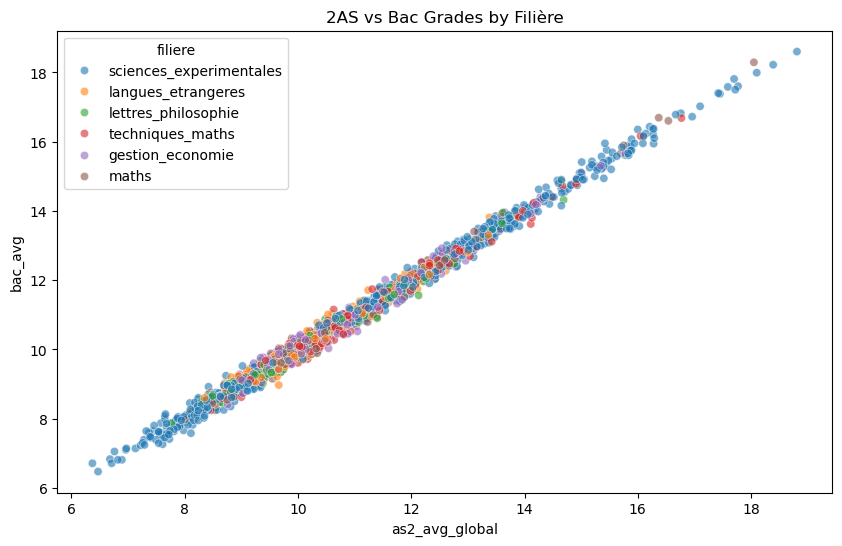

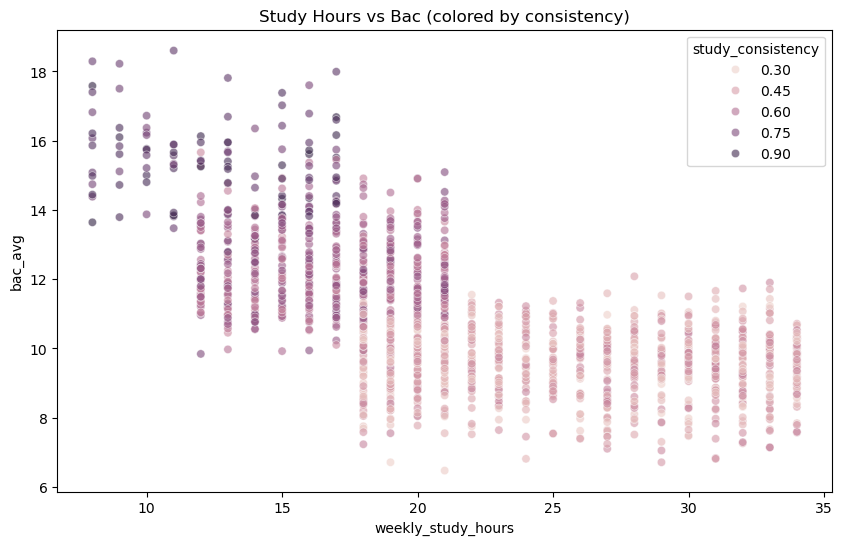

In [14]:
#Cell 11.4 2AS vs Bac
plt.figure(figsize=(10, 6))
sns.scatterplot(x='as2_avg_global', y='bac_avg', hue='filiere', data=df, alpha=0.6)
plt.title('2AS vs Bac Grades by Filière')
plt.show()

# Study hours vs Bac
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weekly_study_hours', y='bac_avg', hue='study_consistency', data=df, alpha=0.6)
plt.title('Study Hours vs Bac (colored by consistency)')
plt.show()

In [15]:
# Cell 11.5 - Missing Values Analysis

# Percentage missing per column
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    plt.figure(figsize=(12, 6))
    missing_pct.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontsize=14)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('Columns', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.axhline(y=8, color='red', linestyle='--', linewidth=1, label='Expected missing rate (8%)')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Missing Values Summary:")
    print(f"   Total missing values: {df.isnull().sum().sum()}")
    print(f"   Columns with missing data: {len(missing_pct)}")
    print(f"   Highest missing %: {missing_pct.iloc[0]:.1f}% in '{missing_pct.index[0]}'")
else:
    print("✅ No missing values found in the dataset")

✅ No missing values found in the dataset


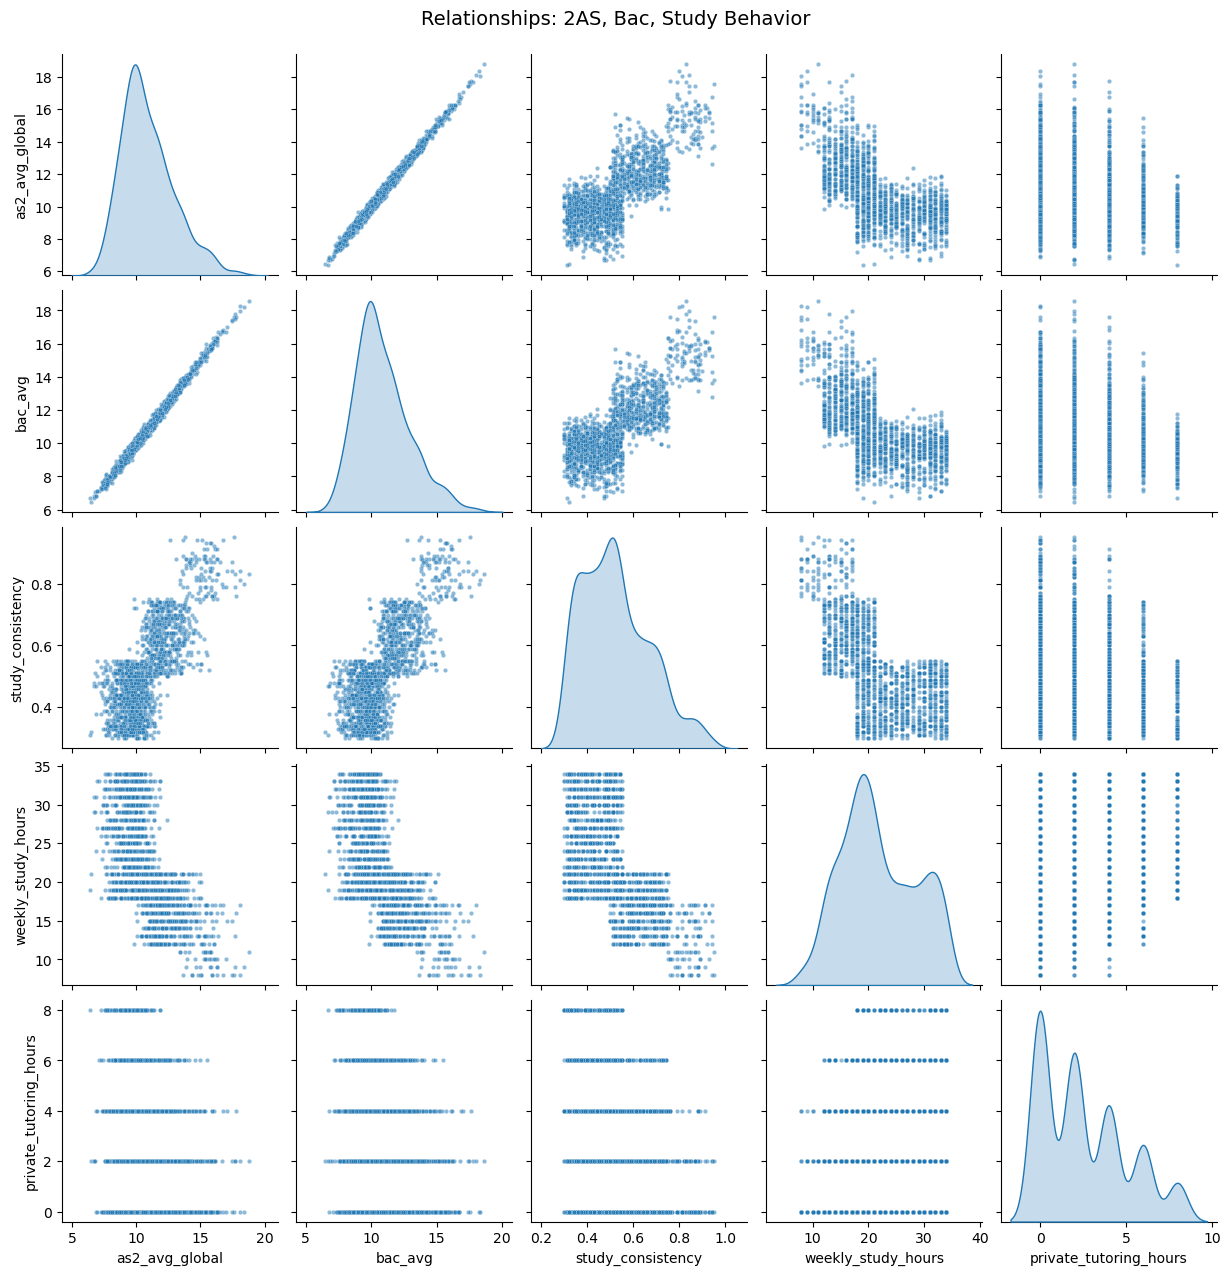

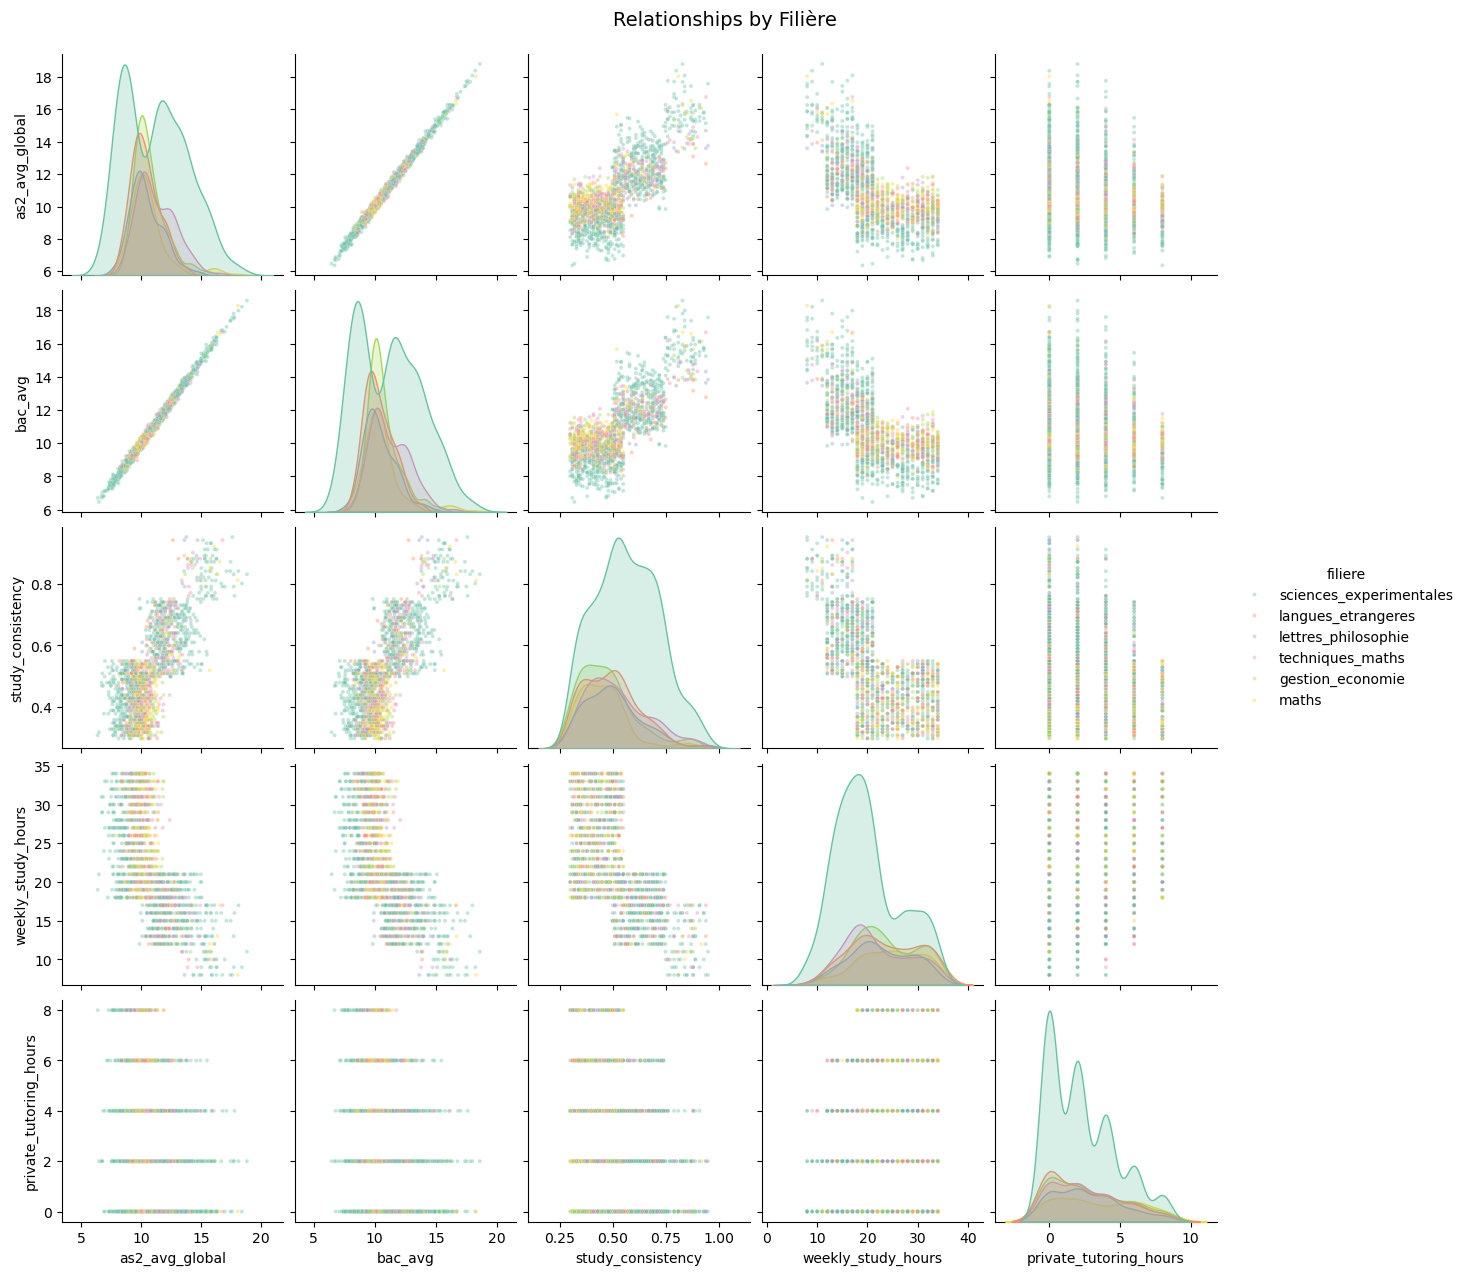

In [16]:
# Cell 11.6 - Pairplot of key features
pair_cols = ['as2_avg_global', 'bac_avg', 'study_consistency', 'weekly_study_hours', 'private_tutoring_hours']

# Drop missing values and add sample transparency
sns.pairplot(
    df[pair_cols].dropna(), 
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 10},  # Transparency + smaller points
    diag_kws={'fill': True}
)
plt.suptitle('Relationships: 2AS, Bac, Study Behavior', y=1.02, fontsize=14)
plt.show()

# Optional: Same plot but colored by filière (more insightful)
sns.pairplot(
    df[pair_cols + ['filiere']].dropna(),
    hue='filiere',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 8},
    palette='Set2'
)
plt.suptitle('Relationships by Filière', y=1.02, fontsize=14)
plt.show()

OUTLIER DETECTION (IQR method)

📊 brevet_avg:
   Q1=10.19, Q3=12.40, IQR=2.21
   Bounds: [6.87, 15.72]
   Outliers: 62 (4.13%)

📊 as1_avg_global:
   Q1=8.97, Q3=11.56, IQR=2.59
   Bounds: [5.08, 15.45]
   Outliers: 31 (2.07%)

📊 as2_avg_global:
   Q1=9.43, Q3=12.03, IQR=2.60
   Bounds: [5.53, 15.94]
   Outliers: 30 (2.00%)

📊 bac_avg:
   Q1=9.44, Q3=12.03, IQR=2.59
   Bounds: [5.55, 15.91]
   Outliers: 32 (2.13%)


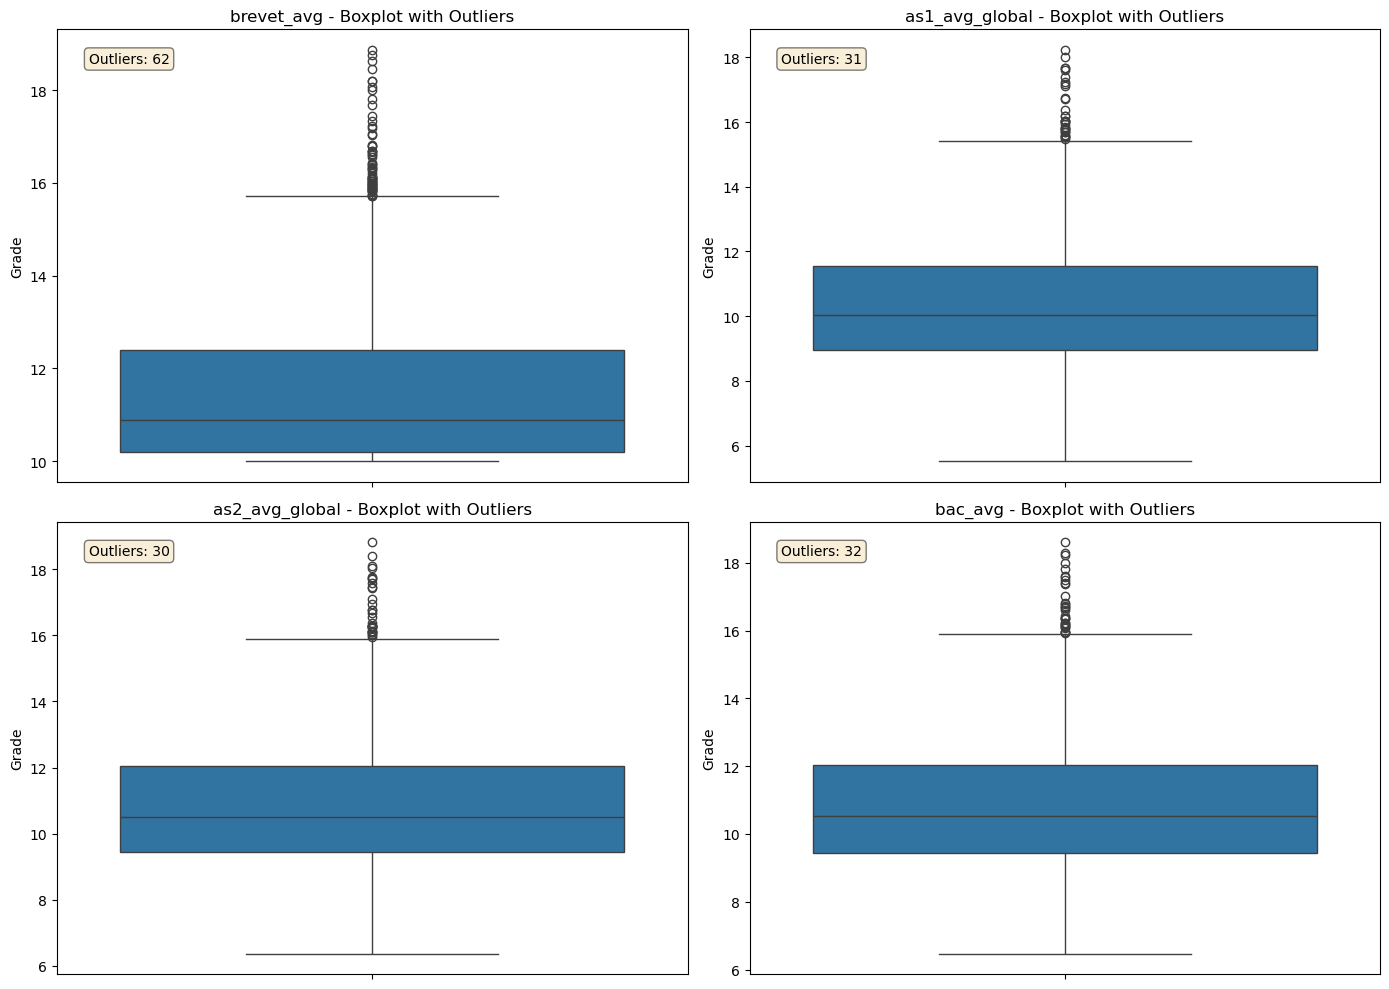

In [17]:
# Cell 11.7 - Outlier Detection for All Grade Columns

grade_cols = ['brevet_avg', 'as1_avg_global', 'as2_avg_global', 'bac_avg']

print("=" * 50)
print("OUTLIER DETECTION (IQR method)")
print("=" * 50)

for col in grade_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n📊 {col}:")
    print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"   Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
    # Show extreme outliers (beyond 3*IQR)
    extreme_outliers = df[(df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)]
    if len(extreme_outliers) > 0:
        print(f"   ⚠️ Extreme outliers (3*IQR): {len(extreme_outliers)}")
        
        if col == 'bac_avg' and len(outliers) > 0:
            print(f"\n   Sample Bac outliers:")
            print(outliers[['student_id', 'filiere', 'region', col]].head(3))

# Visualize outliers with boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(grade_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} - Boxplot with Outliers', fontsize=12)
    axes[i].set_ylabel('Grade')
    
    # Add outlier count
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    axes[i].text(0.05, 0.95, f'Outliers: {outlier_count}', 
                 transform=axes[i].transAxes, fontsize=10,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

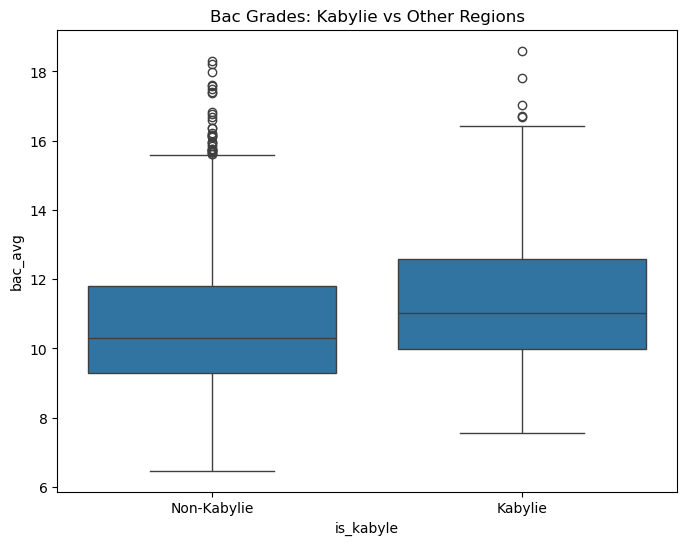

Kabylie Bac avg: 11.47
Non-Kabylie Bac avg: 10.73
Difference: +0.74


In [18]:
# Cell 11.8 Compare Kabylie vs others
kabyle_regions = ['tizi_ouzou', 'bejaia']
df['is_kabyle'] = df['region'].isin(kabyle_regions)

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_kabyle', y='bac_avg', data=df)
plt.xticks([0, 1], ['Non-Kabylie', 'Kabylie'])
plt.title('Bac Grades: Kabylie vs Other Regions')
plt.show()

# Statistical difference
kabyle_avg = df[df['is_kabyle']]['bac_avg'].mean()
non_kabyle_avg = df[~df['is_kabyle']]['bac_avg'].mean()
print(f"Kabylie Bac avg: {kabyle_avg:.2f}")
print(f"Non-Kabylie Bac avg: {non_kabyle_avg:.2f}")
print(f"Difference: +{kabyle_avg - non_kabyle_avg:.2f}")

BAC SUCCESS RATE COMPARISON: Generated vs Official 2024
                         Generated Success Rate (%)  Official 2024 Rate (%)
filiere                                                                    
techniques_maths                               76.5                    60.0
gestion_economie                               67.3                    47.4
maths                                          60.6                    82.2
sciences_experimentales                        59.0                    61.6
lettres_philosophie                            54.7                    52.5
langues_etrangeres                             53.8                    64.1

Overall success rate: 61.3%


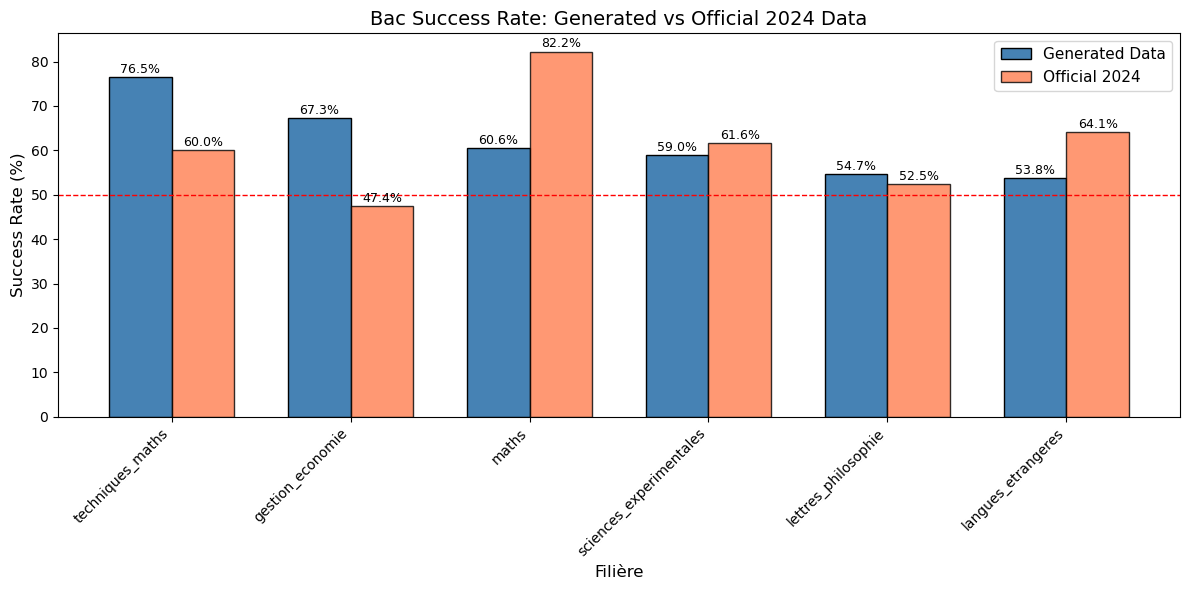


CHI-SQUARE TEST (using counts, not percentages)

Observed success counts: [376 132 106  82 140  83]
Expected success counts: [395.2  93.5 127.1  79.2 110.5 113.4]
Sum observed: 919
Sum expected: 919.0
Difference: 0.000000

📊 Chi-square test results:
   Chi-square statistic: 36.43
   P-value: 0.0000
   ⚠️ Generated data differs from official distribution (p < 0.05)
   (This is expected with random generation - small deviations are normal)


In [19]:
# Cell 11.9 - Bac Success Rate Analysis by Filière

# Calculate success rate per filière (bac_avg >= 10)
success_by_filiere = df.groupby('filiere')['bac_avg'].apply(lambda x: (x >= 10).mean() * 100)
success_by_filiere = success_by_filiere.sort_values(ascending=False)

# Create comparison dataframe with official rates
official_rates = pd.Series(FILIERE_SUCCESS_RATE) * 100
comparison = pd.DataFrame({
    'Generated Success Rate (%)': success_by_filiere,
    'Official 2024 Rate (%)': official_rates[success_by_filiere.index]
})

print("=" * 60)
print("BAC SUCCESS RATE COMPARISON: Generated vs Official 2024")
print("=" * 60)
print(comparison.round(1))
print(f"\nOverall success rate: {(df['bac_avg'] >= 10).mean() * 100:.1f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Generated Success Rate (%)'], width, label='Generated Data', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison['Official 2024 Rate (%)'], width, label='Official 2024', color='coral', edgecolor='black', alpha=0.8)

ax.set_xlabel('Filière', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Bac Success Rate: Generated vs Official 2024 Data', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1, label='50% threshold')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# FIXED: Chi-square test with forced sum matching
from scipy.stats import chisquare

# Get actual counts per filière
n_students_per_filiere = df.groupby('filiere').size()
n_success_per_filiere = df[df['bac_avg'] >= 10].groupby('filiere').size()

# Fill missing filières with 0
all_filieres = list(FILIERES.keys())
n_success_per_filiere = n_success_per_filiere.reindex(all_filieres, fill_value=0)
n_students_per_filiere = n_students_per_filiere.reindex(all_filieres, fill_value=0)

# Expected counts based on official rates
expected_success_counts = n_students_per_filiere * pd.Series(FILIERE_SUCCESS_RATE).reindex(all_filieres, fill_value=0)

# FORCE sums to match exactly (fix rounding issues)
total_observed = n_success_per_filiere.sum()
total_expected = expected_success_counts.sum()

if abs(total_observed - total_expected) > 0.01:
    # Scale expected counts to match observed total
    scale_factor = total_observed / total_expected
    expected_success_counts = expected_success_counts * scale_factor

print("\n" + "=" * 60)
print("CHI-SQUARE TEST (using counts, not percentages)")
print("=" * 60)
print(f"\nObserved success counts: {n_success_per_filiere.values}")
print(f"Expected success counts: {expected_success_counts.values.round(1)}")
print(f"Sum observed: {n_success_per_filiere.sum()}")
print(f"Sum expected: {expected_success_counts.sum().round(1)}")
print(f"Difference: {abs(n_success_per_filiere.sum() - expected_success_counts.sum()):.6f}")

# Perform chi-square test (sums now forced to match)
chi2, p_value = chisquare(f_obs=n_success_per_filiere.values, f_exp=expected_success_counts.values)

print(f"\n📊 Chi-square test results:")
print(f"   Chi-square statistic: {chi2:.2f}")
print(f"   P-value: {p_value:.4f}")

if p_value > 0.05:
    print(f"   ✅ Generated data matches official distribution (p > 0.05)")
else:
    print(f"   ⚠️ Generated data differs from official distribution (p < 0.05)")
    print(f"   (This is expected with random generation - small deviations are normal)")

In [20]:


# Cell 12: Create Behavioral Features 

import numpy as np
import pandas as pd

# Start with your encoded dataframe
df_ml = df.copy()  # or df_encoded if you already ran encoding

print("=" * 60)
print("🏗️ BUILDING BEHAVIORAL FEATURES")
print("=" * 60)

# ============================================
# EFFICIENCY METRICS
# ============================================

# Study efficiency (grade per study hour)
df_ml['study_efficiency'] = df_ml['as2_avg_global'] / (df_ml['weekly_study_hours'] + 0.1)

# Grinder index (high hours + low efficiency = grinding but not learning)
df_ml['grinder_index'] = df_ml['weekly_study_hours'] / (df_ml['study_efficiency'] + 0.1)

# Time allocation (essential vs non-essential)
df_ml['time_allocation_ratio'] = df_ml['time_essential_subjects'] / (df_ml['time_non_essential_subjects'] + 0.1)

# Resource reliance (private tutoring dependency)
df_ml['resource_reliance'] = df_ml['private_tutoring_hours'] / (df_ml['weekly_study_hours'] + 0.1)

# ============================================
# MOMENTUM & CONSISTENCY
# ============================================

# Improvement from 1AS to 2AS
df_ml['improvement_momentum'] = df_ml['as2_avg_global'] - df_ml['as1_avg_global']

# Grade volatility (consistency across years)
years = df_ml[['brevet_avg', 'as1_avg_global', 'as2_avg_global']]
df_ml['grade_volatility'] = years.std(axis=1)

# Self-reported consistency (already exists, just ensure it's numeric)
df_ml['consistency_score'] = df_ml['study_consistency']

# ============================================
# STRESS & WELLNESS
# ============================================

# Stress hurting performance
df_ml['stress_performance_ratio'] = df_ml['exam_anxiety'] / (df_ml['as2_avg_global'] + 0.1)

# Sleep debt (assuming 8 hours optimal)
df_ml['sleep_debt'] = (8 - df_ml['sleep_hours']).clip(lower=0)

# Health-stress interaction
df_ml['health_stress_index'] = (6 - df_ml['health_state']) * df_ml['stress_level']

# Family support (normalized)
df_ml['family_support_strength'] = df_ml['family_support_score'] / 5

# ============================================
# WEAKNESS PATTERNS
# ============================================

# Weakness count
weak_cols = ['weak_math', 'weak_physics', 'weak_science', 'weak_arabic', 'weak_langues', 'weak_hfada']
df_ml['weakness_count'] = (df_ml[weak_cols] > 0.6).sum(axis=1)

# Problem solving gap (math + physics weakness)
df_ml['problem_solving_gap'] = (df_ml['weak_math'] + df_ml['weak_physics']) / 2

# Weakness concentration (are they weak in everything or just specific subjects?)
df_ml['weakness_concentration'] = df_ml[weak_cols].max() - df_ml[weak_cols].min()

# Science vs Language weakness gap
df_ml['science_lang_gap'] = (
    (df_ml['weak_math'] + df_ml['weak_physics'] + df_ml['weak_science']) / 3 -
    (df_ml['weak_arabic'] + df_ml['weak_langues']) / 2
)

# ============================================
# BALANCE & ALIGNMENT
# ============================================

# Subject balance (how balanced are their grades?)
subject_scores = ['as2_math', 'as2_physics', 'as2_science', 'as2_arabic', 'as2_langues']
df_ml['subject_balance'] = df_ml[subject_scores].std(axis=1)

# Filiere alignment (are they in the right filiere?)
def calc_alignment(row):
    filiere = row['filiere']
    science = (row['as2_math'] + row['as2_physics'] + row['as2_science']) / 3
    language = (row['as2_arabic'] + row['as2_langues']) / 2
    
    if filiere in ['maths', 'sciences_experimentales', 'techniques_maths']:
        return science / 20
    elif filiere in ['langues_etrangeres', 'lettres_philosophie']:
        return language / 20
    elif filiere == 'gestion_economie':
        return (science + language) / 40
    else:
        return 0.5

df_ml['filiere_alignment'] = df_ml.apply(calc_alignment, axis=1)

# ============================================
# INTERACTION FEATURES (Key for archetypes)
# ============================================

# Efficient but stressed (burnout risk)
df_ml['efficient_stressed'] = df_ml['study_efficiency'] * df_ml['stress_performance_ratio']

# Consistent but weak (studying hard but not smart)
df_ml['consistent_weak'] = df_ml['consistency_score'] * df_ml['weakness_count']

# Repeater penalty
df_ml['repeater_penalty'] = df_ml['is_repeater'].astype(float)

# Kabylie boost (cultural/regional)
kabylie_regions = ['tizi_ouzou', 'bejaia']
df_ml['kabylie_boost'] = df_ml['region'].isin(kabylie_regions).astype(float)

# ============================================
# VERIFICATION
# ============================================

print(f"✅ Added {df_ml.shape[1] - df.shape[1]} new behavioral features")
print(f"📊 Total columns now: {df_ml.shape[1]}")

# List all new features
new_features = ['study_efficiency', 'grinder_index', 'time_allocation_ratio', 
                'resource_reliance', 'improvement_momentum', 'grade_volatility',
                'stress_performance_ratio', 'sleep_debt', 'health_stress_index',
                'family_support_strength', 'weakness_concentration', 
                'science_lang_gap', 'subject_balance', 'efficient_stressed',
                'consistent_weak', 'repeater_penalty', 'kabylie_boost']

print("\n✅ New features created:")
for f in new_features:
    if f in df_ml.columns:
        print(f"   ✓ {f}")
    else:
        print(f"   ✗ {f} (MISSING)")

print("\n📋 Sample of behavioral features (first 3 students):")
sample_cols = ['study_efficiency', 'grinder_index', 'improvement_momentum', 
               'stress_performance_ratio', 'sleep_debt', 'weakness_count']
print(df_ml[sample_cols].head(3))




🏗️ BUILDING BEHAVIORAL FEATURES
✅ Added 3 new behavioral features
📊 Total columns now: 72

✅ New features created:
   ✓ study_efficiency
   ✓ grinder_index
   ✓ time_allocation_ratio
   ✓ resource_reliance
   ✓ improvement_momentum
   ✓ grade_volatility
   ✓ stress_performance_ratio
   ✓ sleep_debt
   ✓ health_stress_index
   ✓ family_support_strength
   ✓ weakness_concentration
   ✓ science_lang_gap
   ✓ subject_balance
   ✓ efficient_stressed
   ✓ consistent_weak
   ✓ repeater_penalty
   ✓ kabylie_boost

📋 Sample of behavioral features (first 3 students):
   study_efficiency  grinder_index  improvement_momentum  \
0          0.709479      25.942623                  0.41   
1          0.535912      28.305821                  0.39   
2          0.398755      48.119800                  0.58   

   stress_performance_ratio  sleep_debt  weakness_count  
0                  0.132714           2               0  
1                  0.306122           2               0  
2                  0.

In [21]:
# Cell 13: Prepare features for PER-FILIÈRE GRADE CLUSTERING

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# IMPORTANT: Use df_ml
if 'df_ml' not in locals():
    print("⚠️ df_ml not found, creating from df...")
    df_ml = df.copy()

# ============================================
# DEFINE GRADE FEATURES FOR CLUSTERING (Keep bac_avg)
# ============================================

# Features that work across ALL filières
grade_features = [
    # Final outcome (anchor - KEEP IT)
    'bac_avg',
    
    # 2AS grades (most recent, most predictive)
    'as2_avg_global',
    'as2_math', 'as2_physics', 'as2_science',
    'as2_arabic', 'as2_langues', 'as2_hfada',
    
    # 1AS grades (baseline)
    'as1_avg_global',
    'as1_math', 'as1_physics', 'as1_science',
    
    # Brevet grades (foundation)
    'brevet_avg',
    'brevet_math', 'brevet_physics', 'brevet_science'
]

print("=" * 60)
print("🔍 PER-FILIÈRE GRADE CLUSTERING (bac_avg KEPT)")
print("=" * 60)
print(f"📊 Total grade features: {len(grade_features)}")

# Check which features exist in df_ml
valid_features = []
missing_features = []

print("\n📊 Checking feature availability:")
for col in grade_features:
    if col in df_ml.columns:
        non_null_count = df_ml[col].notna().sum()
        if non_null_count > 0:
            valid_features.append(col)
            print(f"   ✓ {col}: {non_null_count} non-null")
        else:
            missing_features.append(col)
            print(f"   ✗ {col}: all null (excluded)")
    else:
        missing_features.append(col)
        print(f"   ❌ {col}: not found in dataframe")

if missing_features:
    print(f"\n⚠️ {len(missing_features)} features not available")

print(f"\n✅ Valid features for clustering: {len(valid_features)}")

# Store for later use
cluster_features = valid_features

print("\n" + "=" * 60)
print("📌 NOTE: Clustering will be done PER FILIÈRE in Cell 15")
print("   This cell only prepares the feature list")
print("=" * 60)

🔍 PER-FILIÈRE GRADE CLUSTERING (bac_avg KEPT)
📊 Total grade features: 16

📊 Checking feature availability:
   ✓ bac_avg: 1500 non-null
   ✓ as2_avg_global: 1500 non-null
   ✓ as2_math: 1500 non-null
   ✓ as2_physics: 1500 non-null
   ✓ as2_science: 1500 non-null
   ✓ as2_arabic: 1500 non-null
   ✓ as2_langues: 1500 non-null
   ✓ as2_hfada: 1500 non-null
   ✓ as1_avg_global: 1500 non-null
   ✓ as1_math: 1500 non-null
   ✓ as1_physics: 1500 non-null
   ✓ as1_science: 1500 non-null
   ✓ brevet_avg: 1500 non-null
   ✓ brevet_math: 1500 non-null
   ✓ brevet_physics: 1500 non-null
   ✓ brevet_science: 1500 non-null

✅ Valid features for clustering: 16

📌 NOTE: Clustering will be done PER FILIÈRE in Cell 15
   This cell only prepares the feature list


📊 FINDING OPTIMAL K FOR EACH FILIÈRE

📚 Filières to analyze: ['sciences_experimentales', 'langues_etrangeres', 'lettres_philosophie', 'techniques_maths', 'gestion_economie', 'maths']

📍 FILIÈRE: SCIENCES_EXPERIMENTALES
   Students: 637

   Testing K values (2 to 8):
      K=2: Inertia=3221, Silhouette=0.559
      K=3: Inertia=1535, Silhouette=0.545
      K=4: Inertia=1006, Silhouette=0.526
      K=5: Inertia=831, Silhouette=0.404
      K=6: Inertia=694, Silhouette=0.393
      K=7: Inertia=610, Silhouette=0.334
      K=8: Inertia=561, Silhouette=0.300


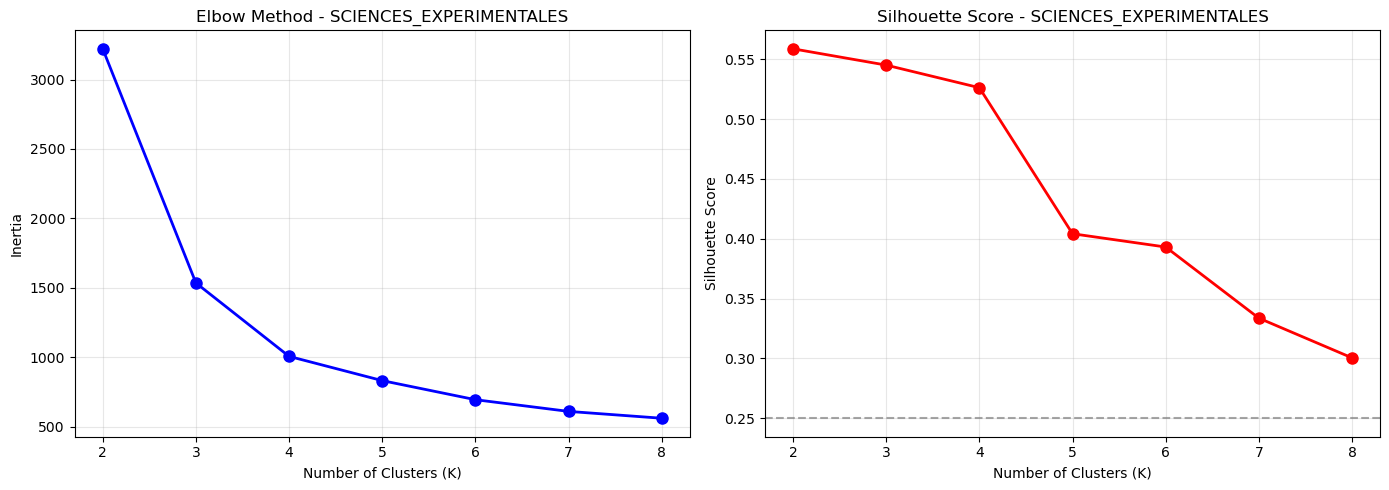


   ✅ OPTIMAL K for sciences_experimentales: K=2

📍 FILIÈRE: LANGUES_ETRANGERES
   Students: 197

   Testing K values (2 to 8):
      K=2: Inertia=1292, Silhouette=0.494
      K=3: Inertia=889, Silhouette=0.373
      K=4: Inertia=685, Silhouette=0.310
      K=5: Inertia=599, Silhouette=0.298
      K=6: Inertia=545, Silhouette=0.220
      K=7: Inertia=501, Silhouette=0.208
      K=8: Inertia=470, Silhouette=0.188


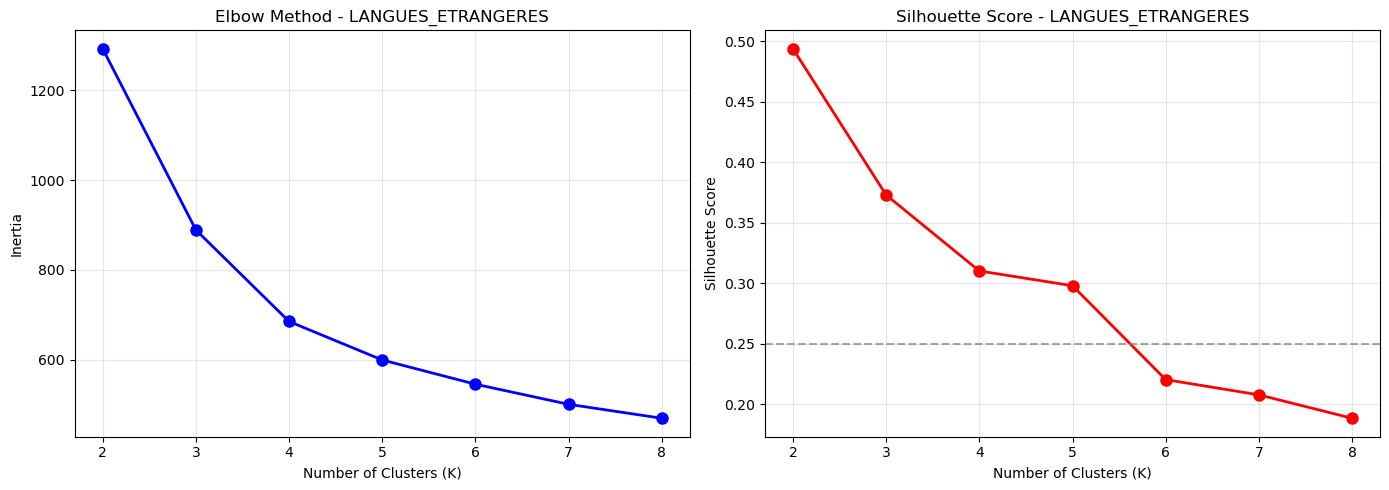


   ✅ OPTIMAL K for langues_etrangeres: K=2

📍 FILIÈRE: LETTRES_PHILOSOPHIE
   Students: 150

   Testing K values (2 to 8):
      K=2: Inertia=906, Silhouette=0.537
      K=3: Inertia=633, Silhouette=0.353
      K=4: Inertia=468, Silhouette=0.325
      K=5: Inertia=378, Silhouette=0.311
      K=6: Inertia=338, Silhouette=0.260
      K=7: Inertia=307, Silhouette=0.234
      K=8: Inertia=283, Silhouette=0.232


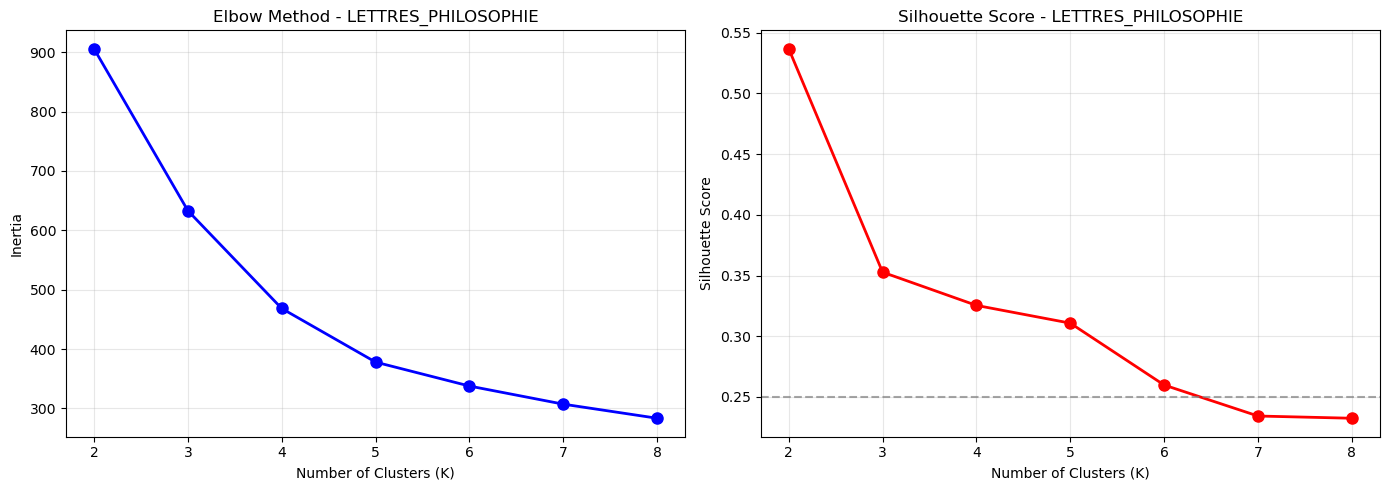


   ✅ OPTIMAL K for lettres_philosophie: K=2

📍 FILIÈRE: TECHNIQUES_MATHS
   Students: 183

   Testing K values (2 to 8):
      K=2: Inertia=1036, Silhouette=0.539
      K=3: Inertia=656, Silhouette=0.476
      K=4: Inertia=501, Silhouette=0.345
      K=5: Inertia=423, Silhouette=0.308
      K=6: Inertia=368, Silhouette=0.301
      K=7: Inertia=324, Silhouette=0.270
      K=8: Inertia=305, Silhouette=0.247


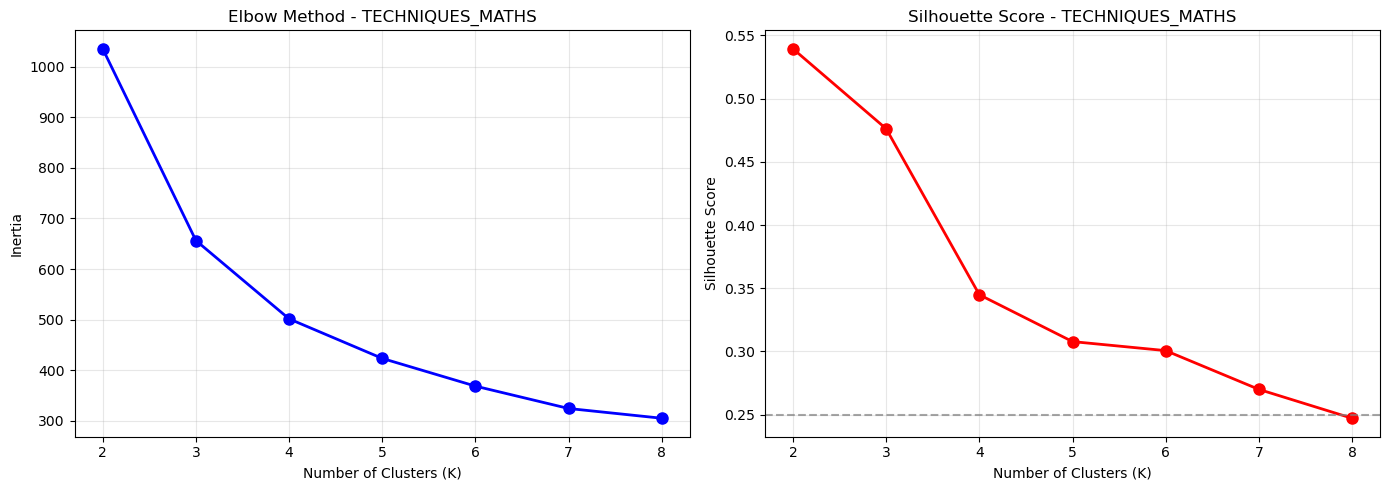


   ✅ OPTIMAL K for techniques_maths: K=2

📍 FILIÈRE: GESTION_ECONOMIE
   Students: 196

   Testing K values (2 to 8):
      K=2: Inertia=1255, Silhouette=0.558
      K=3: Inertia=819, Silhouette=0.408
      K=4: Inertia=612, Silhouette=0.324
      K=5: Inertia=508, Silhouette=0.292
      K=6: Inertia=458, Silhouette=0.225
      K=7: Inertia=423, Silhouette=0.223
      K=8: Inertia=395, Silhouette=0.196


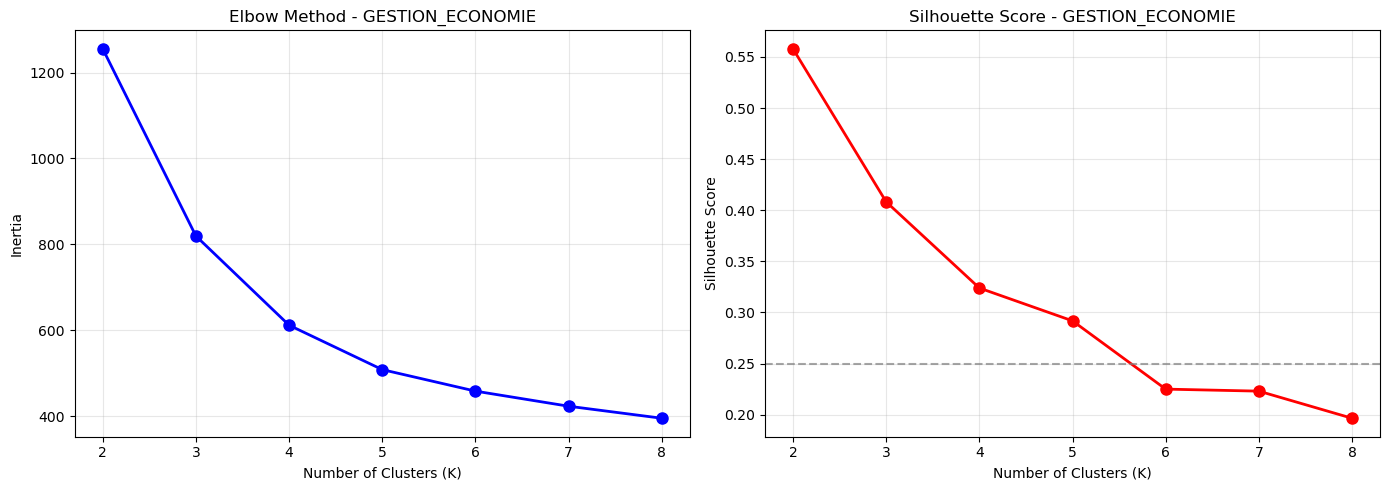


   ✅ OPTIMAL K for gestion_economie: K=2

📍 FILIÈRE: MATHS
   Students: 137

   Testing K values (2 to 8):
      K=2: Inertia=825, Silhouette=0.692
      K=3: Inertia=430, Silhouette=0.486
      K=4: Inertia=294, Silhouette=0.369
      K=5: Inertia=238, Silhouette=0.312
      K=6: Inertia=210, Silhouette=0.270
      K=7: Inertia=188, Silhouette=-1.000
      K=8: Inertia=175, Silhouette=-1.000


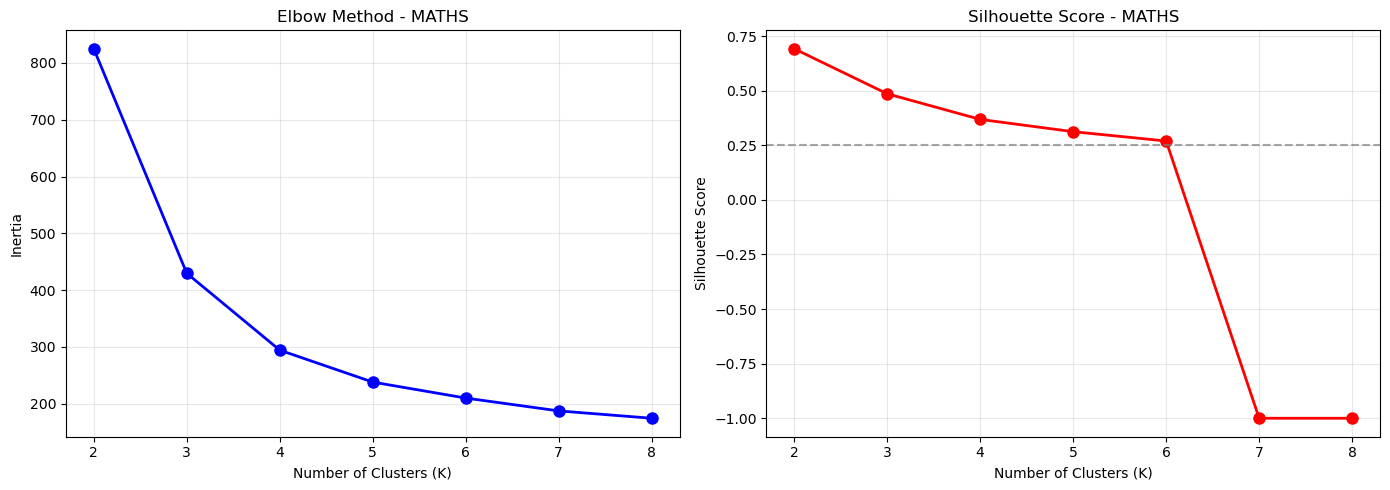


   ✅ OPTIMAL K for maths: K=2

📊 OPTIMAL K SUMMARY BY FILIÈRE
   sciences_experimentales: K=2
   langues_etrangeres: K=2
   lettres_philosophie: K=2
   techniques_maths: K=2
   gestion_economie: K=2
   maths: K=2

💡 Cell 15 will use per-filière K values from this analysis


In [22]:
# Cell 14: Find Optimal K for EACH FILIÈRE (Elbow + Silhouette graphs)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("📊 FINDING OPTIMAL K FOR EACH FILIÈRE")
print("=" * 60)

# Get unique filières
filieres = df_ml['filiere'].unique()
print(f"\n📚 Filières to analyze: {list(filieres)}")

# Store results for each filière
optimal_k_results = {}

for filiere in filieres:
    print(f"\n{'='*60}")
    print(f"📍 FILIÈRE: {filiere.upper()}")
    print(f"{'='*60}")
    
    # Filter students for this filière
    filiere_mask = df_ml['filiere'] == filiere
    filiere_df = df_ml[filiere_mask].copy()
    
    print(f"   Students: {len(filiere_df)}")
    
    if len(filiere_df) < 10:
        print(f"   ⚠️ Too few students ({len(filiere_df)}), skipping...")
        optimal_k_results[filiere] = 2
        continue
    
    # Prepare features
    available_features = [f for f in cluster_features if f in filiere_df.columns]
    X = filiere_df[available_features].copy()
    
    # Handle missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    # Test K from 2 to min(8, n_students-1)
    max_k = min(8, len(filiere_df) - 1)
    if max_k < 2:
        optimal_k_results[filiere] = 2
        continue
        
    K_range = range(2, max_k + 1)
    inertias = []
    silhouette_scores = []
    
    print(f"\n   Testing K values (2 to {max_k}):")
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)
        
        # Silhouette requires at least 2 clusters and each cluster has >1 sample
        if len(set(labels)) > 1 and min(np.bincount(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            silhouette_scores.append(score)
        else:
            silhouette_scores.append(-1)
        
        print(f"      K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.3f}")
    
    # Create the two graphs (Elbow + Silhouette)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow Method
    axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'Elbow Method - {filiere.upper()}')
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette Score
    axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'Silhouette Score - {filiere.upper()}')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0.25, color='gray', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Find best K (highest silhouette score only - NO FALLBACK)
    if max(silhouette_scores) > 0:
        best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
    else:
        # If silhouette fails, use elbow point (NOT default 3)
        # Find the elbow by looking for maximum curvature
        if len(inertias) >= 3:
            # Calculate second derivatives to find elbow
            first_deriv = np.diff(inertias)
            second_deriv = np.diff(first_deriv)
            if len(second_deriv) > 0:
                elbow_idx = np.argmax(second_deriv) + 1  # +1 because of diff
                best_k = K_range[min(elbow_idx, len(K_range)-1)]
            else:
                best_k = K_range[-1]  # Use max K
        else:
            best_k = K_range[-1]  # Use max K
    
    optimal_k_results[filiere] = best_k
    print(f"\n   ✅ OPTIMAL K for {filiere}: K={best_k}")

# Summary
print("\n" + "=" * 60)
print("📊 OPTIMAL K SUMMARY BY FILIÈRE")
print("=" * 60)
for filiere, k in optimal_k_results.items():
    print(f"   {filiere}: K={k}")

# For cells that need a global best_k
best_k = 3  # placeholder
print(f"\n💡 Cell 15 will use per-filière K values from this analysis")

In [23]:
# Cell 15: Apply K-Means Clustering PER FILIÈRE with MANUAL K values

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

print("=" * 60)
print("🎯 PER-FILIÈRE CLUSTERING (MANUAL K VALUES)")
print("=" * 60)

# ============================================
# MANUALLY SET K FOR EACH FILIÈRE
# ============================================
MANUAL_K = {
    'sciences_experimentales': 6,  
    'maths': 4,                     
    'techniques_maths': 3,          
    'gestion_economie': 4,          
    'langues_etrangeres': 3,        
    'lettres_philosophie': 3        
}

print("\n📊 MANUAL K VALUES:")
for filiere, k in MANUAL_K.items():
    print(f"   {filiere}: K={k}")

# Get unique filières
filieres = df_ml['filiere'].unique()

# Store clustering results
df_ml['cluster_filiere'] = -1  # Initialize

for filiere in filieres:
    print(f"\n{'='*50}")
    print(f"📍 FILIÈRE: {filiere.upper()}")
    print(f"{'='*50}")
    
    # Filter students for this filière
    filiere_mask = df_ml['filiere'] == filiere
    filiere_df = df_ml[filiere_mask].copy()
    filiere_indices = filiere_df.index
    
    print(f"   Students: {len(filiere_df)}")
    
    # Get manual K for this filière
    k = MANUAL_K.get(filiere, 3)
    print(f"   Using K = {k} (manual)")
    
    # Prepare features
    available_features = [f for f in cluster_features if f in filiere_df.columns]
    X = filiere_df[available_features].copy()
    
    # Handle missing values
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    
    # Apply K-Means with manual K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Reorder clusters by Bac average (0=highest, k-1=lowest)
    bac_means = []
    for c in range(k):
        cluster_mask = (labels == c)
        if cluster_mask.any():
            bac_mean = filiere_df.loc[cluster_mask, 'bac_avg'].mean()
            bac_means.append((c, bac_mean))
    
    bac_means.sort(key=lambda x: x[1], reverse=True)
    label_mapping = {old: new for new, (old, _) in enumerate(bac_means)}
    labels_reordered = np.array([label_mapping[l] for l in labels])
    
    # Store results
    df_ml.loc[filiere_indices, 'cluster_filiere'] = labels_reordered
    df_ml.loc[filiere_indices, 'k_per_filiere'] = k
    
    # Define names based on K value (FIXED for K=6)
    if k == 6:
        names = ["🟢 EXCELLENT", "🔵 VERY GOOD", "🟡 GOOD", "🟠 PASSABLE", "🔴 FAILING", "⚫ VERY LOW"]
    elif k == 5:
        names = ["🟢 EXCELLENT", "🔵 VERY GOOD", "🟡 GOOD", "🟠 PASSABLE", "🔴 FAILING"]
    elif k == 4:
        names = ["🟢 EXCELLENT", "🔵 GOOD", "🟡 PASSABLE", "🔴 FAILING"]
    elif k == 3:
        names = ["🟢 GOOD", "🟡 AVERAGE", "🔴 FAILING"]
    else:  # k == 2
        names = ["🟢 PASSING", "🔴 FAILING"]
    
    # Print results
    for c in range(k):
        cluster_mask = (labels_reordered == c)
        count = cluster_mask.sum()
        pct = count / len(filiere_df) * 100
        bac_mean = df_ml.loc[filiere_indices[cluster_mask], 'bac_avg'].mean()
        
        name = names[c] if c < len(names) else f"Cluster {c}"
        
        print(f"   {name}: {count} students ({pct:.1f}%) | Bac: {bac_mean:.2f}")

# Summary
print("\n" + "=" * 60)
print("📊 FINAL SUMMARY")
print("=" * 60)

for filiere in filieres:
    k = MANUAL_K.get(filiere, 3)
    counts = []
    bacs = []
    for c in range(k):
        count = ((df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)).sum()
        if count > 0:
            bac_mean = df_ml[(df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)]['bac_avg'].mean()
            counts.append(count)
            bacs.append(bac_mean)
    
    if counts:  # Only print if there are students
        print(f"\n{filiere.upper()} (K={k}):")
        for c in range(len(counts)):
            if k == 6:
                names = ["Excellent", "Very Good", "Good", "Passable", "Failing", "Very Low"]
            elif k == 5:
                names = ["Excellent", "Very Good", "Good", "Passable", "Failing"]
            elif k == 4:
                names = ["Excellent", "Good", "Passable", "Failing"]
            elif k == 3:
                names = ["Good", "Average", "Failing"]
            else:
                names = ["Passing", "Failing"]
            
            name = names[c] if c < len(names) else f"Cluster {c}"
            print(f"   {name}: {counts[c]} students ({counts[c]/sum(counts)*100:.1f}%) | Bac: {bacs[c]:.2f}")

print("\n" + "=" * 60)
print("✅ Per-filière clustering complete!")
print("💡 Adjust MANUAL_K values at the top of Cell 15 to change cluster counts")

🎯 PER-FILIÈRE CLUSTERING (MANUAL K VALUES)

📊 MANUAL K VALUES:
   sciences_experimentales: K=6
   maths: K=4
   techniques_maths: K=3
   gestion_economie: K=4
   langues_etrangeres: K=3
   lettres_philosophie: K=3

📍 FILIÈRE: SCIENCES_EXPERIMENTALES
   Students: 637
   Using K = 6 (manual)
   🟢 EXCELLENT: 18 students (2.8%) | Bac: 17.15
   🔵 VERY GOOD: 66 students (10.4%) | Bac: 15.23
   🟡 GOOD: 129 students (20.3%) | Bac: 13.32
   🟠 PASSABLE: 159 students (25.0%) | Bac: 11.47
   🔴 FAILING: 137 students (21.5%) | Bac: 9.13
   ⚫ VERY LOW: 128 students (20.1%) | Bac: 7.92

📍 FILIÈRE: LANGUES_ETRANGERES
   Students: 197
   Using K = 3 (manual)
   🟢 GOOD: 32 students (16.2%) | Bac: 12.37
   🟡 AVERAGE: 62 students (31.5%) | Bac: 10.84
   🔴 FAILING: 103 students (52.3%) | Bac: 9.44

📍 FILIÈRE: LETTRES_PHILOSOPHIE
   Students: 150
   Using K = 3 (manual)
   🟢 GOOD: 35 students (23.3%) | Bac: 12.31
   🟡 AVERAGE: 57 students (38.0%) | Bac: 10.42
   🔴 FAILING: 58 students (38.7%) | Bac: 9.21

📍 

📊 VISUALIZING PER-FILIÈRE CLUSTER PROFILES


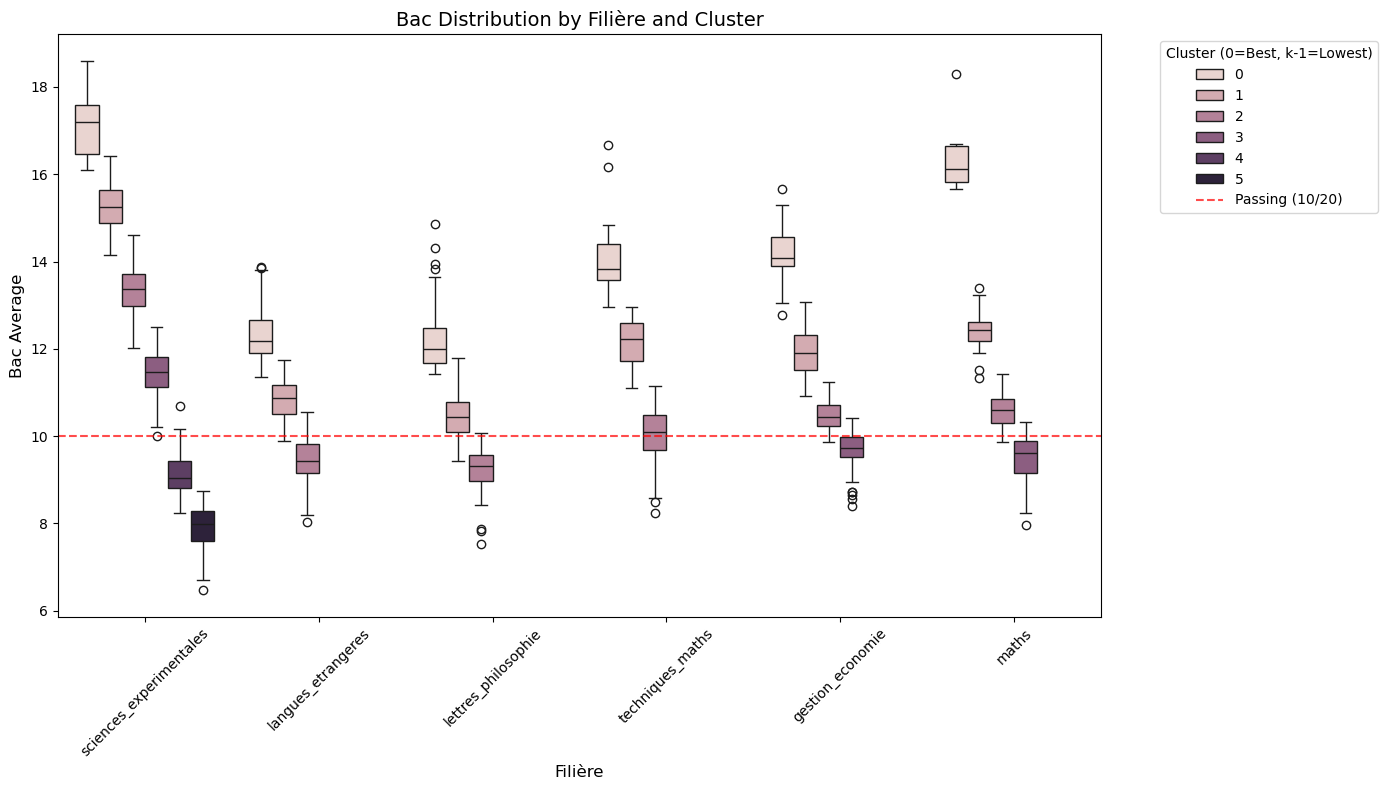

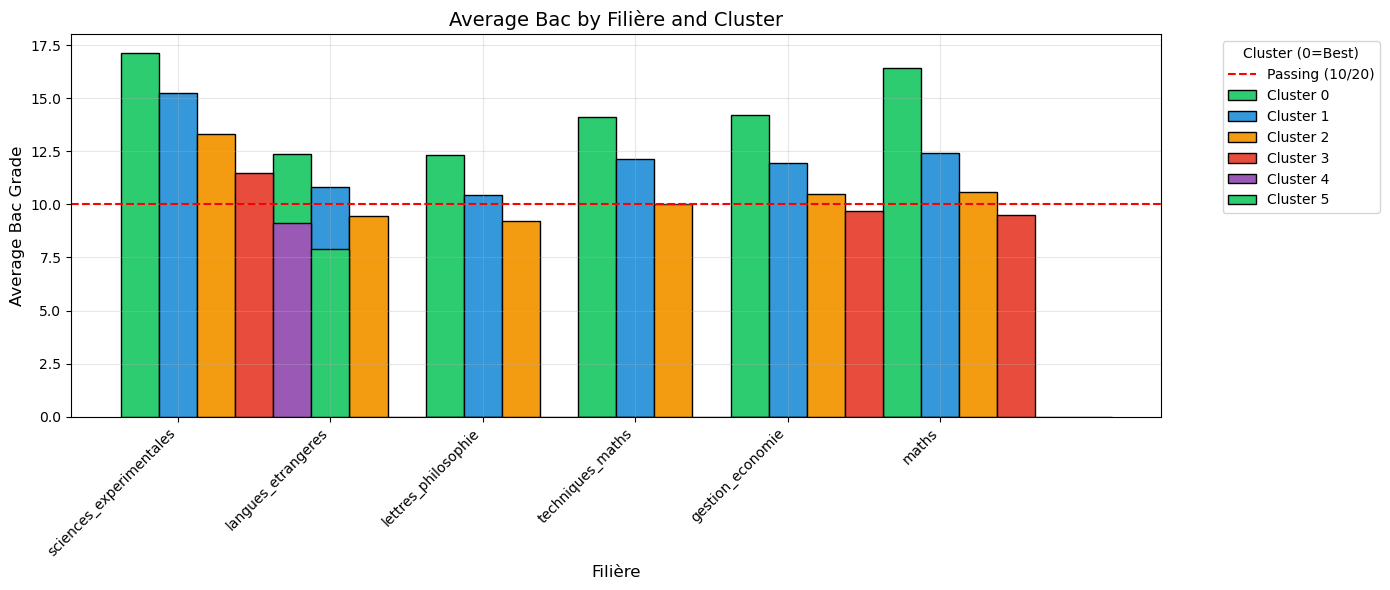

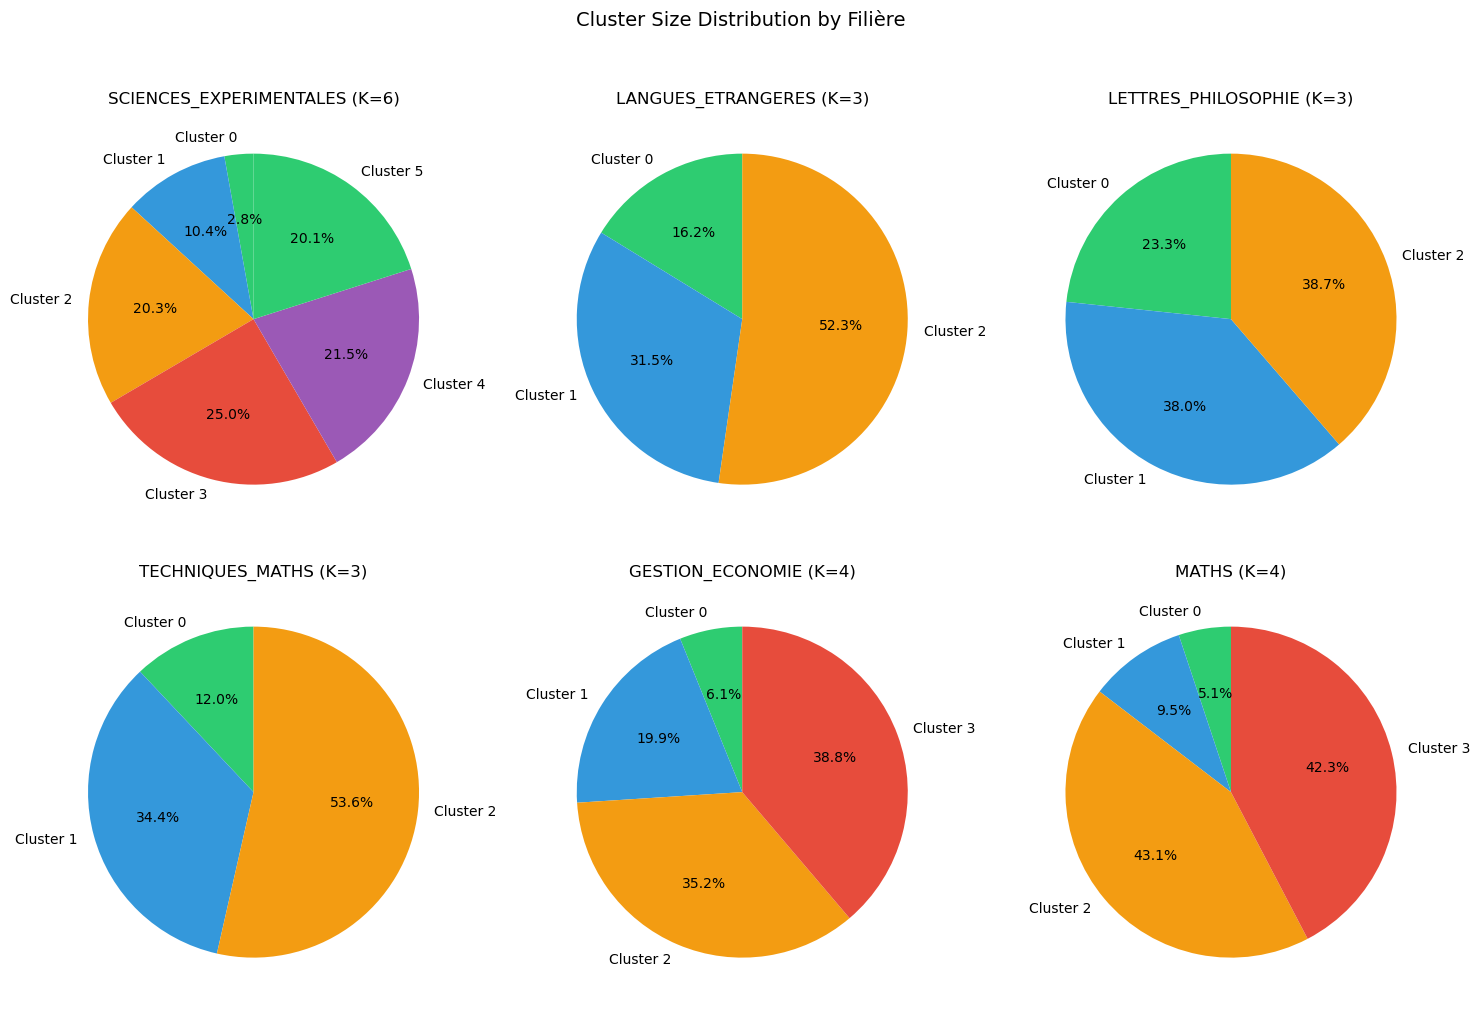


📊 CLUSTER SUMMARY TABLE
                Filière  Cluster  Students % of Filière Avg Bac
sciences_experimentales        0        18         2.8%   17.15
sciences_experimentales        1        66        10.4%   15.23
sciences_experimentales        2       129        20.3%   13.32
sciences_experimentales        3       159        25.0%   11.47
sciences_experimentales        4       137        21.5%    9.13
sciences_experimentales        5       128        20.1%    7.92
     langues_etrangeres        0        32        16.2%   12.37
     langues_etrangeres        1        62        31.5%   10.84
     langues_etrangeres        2       103        52.3%    9.44
    lettres_philosophie        0        35        23.3%   12.31
    lettres_philosophie        1        57        38.0%   10.42
    lettres_philosophie        2        58        38.7%    9.21
       techniques_maths        0        22        12.0%   14.12
       techniques_maths        1        63        34.4%   12.15
       techniqu

In [24]:
# Cell 16: Visualize Per-Filière Cluster Profiles

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("📊 VISUALIZING PER-FILIÈRE CLUSTER PROFILES")
print("=" * 60)

# Get all unique (filiere, cluster) combinations
cluster_list = []
for filiere in filieres:
    k = MANUAL_K[filiere]
    for c in range(k):
        cluster_list.append((filiere, c))

# Create a combined cluster label for visualization
df_ml['cluster_label'] = df_ml['filiere'] + "_C" + df_ml['cluster_filiere'].astype(str)

# ============================================
# PLOT 1: Bac Distribution by Filière and Cluster
# ============================================
plt.figure(figsize=(14, 8))

# Boxplot of Bac by filière and cluster
sns.boxplot(x='filiere', y='bac_avg', hue='cluster_filiere', data=df_ml)
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Passing (10/20)')
plt.xlabel('Filière', fontsize=12)
plt.ylabel('Bac Average', fontsize=12)
plt.title('Bac Distribution by Filière and Cluster', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Cluster (0=Best, k-1=Lowest)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# PLOT 2: Average Bac by Filière and Cluster (Bar Chart)
# ============================================
# Prepare data for grouped bar chart
plot_data = []
for filiere in filieres:
    k = MANUAL_K[filiere]
    for c in range(k):
        mask = (df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)
        if mask.any():
            mean_bac = df_ml[mask]['bac_avg'].mean()
            plot_data.append({
                'filiere': filiere,
                'cluster': c,
                'mean_bac': mean_bac
            })

plot_df = pd.DataFrame(plot_data)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique filières and clusters
unique_filieres = plot_df['filiere'].unique()
width = 0.25  # Width of each bar
x = np.arange(len(unique_filieres))

# Colors for clusters
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']

for c in range(max(MANUAL_K.values())):
    cluster_data = plot_df[plot_df['cluster'] == c]
    if len(cluster_data) > 0:
        # Align bars
        bars = ax.bar(x + c * width, 
                      [cluster_data[cluster_data['filiere'] == f]['mean_bac'].values[0] if len(cluster_data[cluster_data['filiere'] == f]) > 0 else 0 for f in unique_filieres],
                      width, 
                      label=f'Cluster {c}', 
                      color=colors[c % len(colors)],
                      edgecolor='black')

ax.set_xlabel('Filière', fontsize=12)
ax.set_ylabel('Average Bac Grade', fontsize=12)
ax.set_title('Average Bac by Filière and Cluster', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(unique_filieres, rotation=45, ha='right')
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Passing (10/20)')
ax.legend(title='Cluster (0=Best)', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PLOT 3: Cluster Size Distribution
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, filiere in enumerate(filieres):
    if idx >= len(axes):
        break
    
    k = MANUAL_K[filiere]
    filiere_df = df_ml[df_ml['filiere'] == filiere]
    
    sizes = []
    labels = []
    for c in range(k):
        count = (filiere_df['cluster_filiere'] == c).sum()
        sizes.append(count)
        labels.append(f'Cluster {c}')
    
    colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6'][:k]
    
    axes[idx].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
    axes[idx].set_title(f'{filiere.upper()} (K={k})', fontsize=12)

# Hide unused subplots
for idx in range(len(filieres), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Cluster Size Distribution by Filière', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# PLOT 4: Summary Table
# ============================================
print("\n" + "=" * 80)
print("📊 CLUSTER SUMMARY TABLE")
print("=" * 80)

summary_data = []
for filiere in filieres:
    k = MANUAL_K[filiere]
    for c in range(k):
        mask = (df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)
        if mask.any():
            count = mask.sum()
            pct = count / len(df_ml[df_ml['filiere'] == filiere]) * 100
            mean_bac = df_ml[mask]['bac_avg'].mean()
            summary_data.append({
                'Filière': filiere,
                'Cluster': c,
                'Students': count,
                '% of Filière': f'{pct:.1f}%',
                'Avg Bac': f'{mean_bac:.2f}'
            })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("✅ Visualization complete!")

In [145]:
# Cell 17: Assign Meaningful Archetype Names (Per-Filière, Mean Only)

print("=" * 60)
print("🏷️ ASSIGNING MEANINGFUL ARCHETYPE NAMES")
print("=" * 60)

# Store archetype names per (filiere, cluster)
archetype_names = {}

print("\n📊 Cluster Summary by Filière:")
print("=" * 70)

for filiere in filieres:
    k = MANUAL_K[filiere]
    
    print(f"\n{filiere.upper()} (K={k}):")
    print("-" * 50)
    
    for c in range(k):
        # Filter students for this filière and cluster
        mask = (df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)
        cluster_data = df_ml[mask]
        
        if len(cluster_data) == 0:
            continue
        
        mean_bac = cluster_data['bac_avg'].mean()
        count = len(cluster_data)
        pct = count / len(df_ml[df_ml['filiere'] == filiere]) * 100
        
        # Define names based on filière and cluster position
        if filiere == 'sciences_experimentales':
            if c == 0:
                name = f"🟢 EXCELLENT (Bac: {mean_bac:.1f})"
                desc = "Top performers, aim to maintain excellence"
            elif c == 1:
                name = f"🔵 VERY GOOD (Bac: {mean_bac:.1f})"
                desc = "Strong students, can reach Excellent"
            elif c == 2:
                name = f"🟡 GOOD (Bac: {mean_bac:.1f})"
                desc = "Solid foundation, needs consistency"
            elif c == 3:
                name = f"🟠 PASSABLE (Bac: {mean_bac:.1f})"
                desc = "Passing, significant room for improvement"
            else:
                name = f"🔴 FAILING (Bac: {mean_bac:.1f})"
                desc = "Urgent intervention needed"
        
        elif filiere == 'maths':
            if c == 0:
                name = f"🟢 EXCELLENT (Bac: {mean_bac:.1f})"
                desc = "Top of maths, target 16+"
            elif c == 1:
                name = f"🟡 GOOD (Bac: {mean_bac:.1f})"
                desc = "Solid performer"
            else:
                name = f"🔴 NEEDS SUPPORT (Bac: {mean_bac:.1f})"
                desc = "Below average for maths"
        
        elif filiere == 'techniques_maths':
            if c == 0:
                name = f"🟢 GOOD (Bac: {mean_bac:.1f})"
                desc = "Strong practical & theoretical skills"
            elif c == 1:
                name = f"🟡 AVERAGE (Bac: {mean_bac:.1f})"
                desc = "Room for improvement"
            else:
                name = f"🔴 FAILING (Bac: {mean_bac:.1f})"
                desc = "Targeted support needed"
        
        elif filiere == 'gestion_economie':
            if c == 0:
                name = f"🟢 GOOD (Bac: {mean_bac:.1f})"
                desc = "Above average understanding"
            elif c == 1:
                name = f"🟡 AVERAGE (Bac: {mean_bac:.1f})"
                desc = "Passing but can do better"
            else:
                name = f"🔴 AT RISK (Bac: {mean_bac:.1f})"
                desc = "Close to failing"
        
        elif filiere == 'langues_etrangeres':
            if c == 0:
                name = f"🟢 GOOD (Bac: {mean_bac:.1f})"
                desc = "Strong language skills"
            elif c == 1:
                name = f"🟡 AVERAGE (Bac: {mean_bac:.1f})"
                desc = "Adequate, needs practice"
            else:
                name = f"🔴 FAILING (Bac: {mean_bac:.1f})"
                desc = "Language fundamentals weak"
        
        else:  # lettres_philosophie
            if c == 0:
                name = f"🟢 GOOD (Bac: {mean_bac:.1f})"
                desc = "Strong analytical skills"
            elif c == 1:
                name = f"🟡 AVERAGE (Bac: {mean_bac:.1f})"
                desc = "Needs more structure"
            else:
                name = f"🔴 FAILING (Bac: {mean_bac:.1f})"
                desc = "Fundamental gaps"
        
        # Store
        key = f"{filiere}_{c}"
        archetype_names[key] = name
        
        # Print
        print(f"   Cluster {c}: {name}")
        print(f"      → {count} students ({pct:.1f}%)")
        print(f"      → {desc}")

# Add archetype column to dataframe
def get_archetype(row):
    key = f"{row['filiere']}_{row['cluster_filiere']}"
    return archetype_names.get(key, "Unknown")

df_ml['archetype'] = df_ml.apply(get_archetype, axis=1)

print("\n" + "=" * 70)
print("✅ ARCHETYPE NAMES ASSIGNED")
print("=" * 70)

# Final summary table
print("\n📊 FINAL SUMMARY TABLE:")
print("-" * 80)
print(f"{'Filière':<25} {'Cluster':<12} {'Students':<10} {'Avg Bac':<10}")
print("-" * 80)

for filiere in filieres:
    k = MANUAL_K[filiere]
    for c in range(k):
        mask = (df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)
        if mask.any():
            count = mask.sum()
            mean_bac = df_ml[mask]['bac_avg'].mean()
            print(f"{filiere:<25} {'C'+str(c):<12} {count:<10} {mean_bac:.2f}")

print("\n" + "=" * 70)
print("✅ Cell 17 complete! Ready for Cell 18")

🏷️ ASSIGNING MEANINGFUL ARCHETYPE NAMES

📊 Cluster Summary by Filière:

SCIENCES_EXPERIMENTALES (K=6):
--------------------------------------------------
   Cluster 0: 🟢 EXCELLENT (Bac: 17.2)
      → 18 students (2.8%)
      → Top performers, aim to maintain excellence
   Cluster 1: 🔵 VERY GOOD (Bac: 15.2)
      → 66 students (10.4%)
      → Strong students, can reach Excellent
   Cluster 2: 🟡 GOOD (Bac: 13.3)
      → 129 students (20.3%)
      → Solid foundation, needs consistency
   Cluster 3: 🟠 PASSABLE (Bac: 11.5)
      → 159 students (25.0%)
      → Passing, significant room for improvement
   Cluster 4: 🔴 FAILING (Bac: 9.1)
      → 137 students (21.5%)
      → Urgent intervention needed
   Cluster 5: 🔴 FAILING (Bac: 7.9)
      → 128 students (20.1%)
      → Urgent intervention needed

LANGUES_ETRANGERES (K=3):
--------------------------------------------------
   Cluster 0: 🟢 GOOD (Bac: 12.4)
      → 32 students (16.2%)
      → Strong language skills
   Cluster 1: 🟡 AVERAGE (Bac:

In [147]:
# Cell 18-19: Enhanced Student Profiler - Complete Analysis with Derived Features

import numpy as np
import pandas as pd

def analyze_student(student_id, df=df_ml):
    """
    Generate a COMPLETE personalized profile for a student including:
    - Archetype classification (per filière)
    - Strengths and weaknesses vs their group
    - All derived features (efficiency, grinder, momentum, etc.)
    - Detailed subject analysis
    - Habit breakdown with actionable insights
    - Personalized recommendations based on actual performance
    - What-if scenarios
    """
    
    # Get student data
    student = df[df['student_id'] == student_id].copy()
    
    if len(student) == 0:
        return {"error": f"Student {student_id} not found"}
    
    # ============================================
    # 1. BASIC INFO & CLUSTER
    # ============================================
    filiere = student['filiere'].iloc[0]
    cluster_id = int(student['cluster_filiere'].iloc[0])
    archetype = student['archetype'].iloc[0]
    student_bac = student['bac_avg'].iloc[0]
    student_mention = student['bac_mention'].iloc[0]
    
    # Get cluster average for comparison
    mask = (df['filiere'] == filiere) & (df['cluster_filiere'] == cluster_id)
    cluster_avg = df[mask][cluster_features].mean()
    cluster_bac_mean = df[mask]['bac_avg'].mean()
    cluster_size = mask.sum()
    
    # Calculate percentile within filière
    filiere_mask = (df['filiere'] == filiere)
    percentile = (df[filiere_mask]['bac_avg'] < student_bac).sum() / df[filiere_mask].shape[0] * 100
    
    # Get student values for comparison
    student_values = student[cluster_features].iloc[0]
    deviations = student_values - cluster_avg
    
    # Identify strengths (better than cluster average)
    strengths_series = deviations[deviations > 0.2]
    strengths = strengths_series.nlargest(4) if len(strengths_series) > 0 else pd.Series()
    
    # Identify weaknesses (worse than cluster average)
    weaknesses_series = deviations[deviations < -0.2]
    weaknesses = weaknesses_series.nsmallest(4) if len(weaknesses_series) > 0 else pd.Series()
    
    # ============================================
    # 2. DERIVED FEATURES (Calculated on the fly)
    # ============================================
    
    # Study efficiency (grade per study hour)
    study_efficiency = student['bac_avg'].iloc[0] / (student['weekly_study_hours'].iloc[0] + 0.1)
    
    # Grinder index (hours / efficiency)
    grinder_index = student['weekly_study_hours'].iloc[0] / (study_efficiency + 0.1)
    
    # Improvement momentum (2AS - 1AS)
    improvement_momentum = student['as2_avg_global'].iloc[0] - student['as1_avg_global'].iloc[0]
    
    # Grade volatility (std across subjects)
    subject_scores = [
        student['as2_math'].iloc[0], student['as2_physics'].iloc[0], 
        student['as2_science'].iloc[0], student['as2_arabic'].iloc[0], 
        student['as2_langues'].iloc[0], student['as2_hfada'].iloc[0]
    ]
    grade_volatility = np.std(subject_scores)
    
    # Resource reliance (tutoring dependency)
    resource_reliance = student['private_tutoring_hours'].iloc[0] / (student['weekly_study_hours'].iloc[0] + 0.1)
    
    # Stress performance ratio
    stress_performance = student['exam_anxiety'].iloc[0] / (student['bac_avg'].iloc[0] + 0.1)
    
    # Sleep debt
    sleep_debt = max(0, 8 - student['sleep_hours'].iloc[0])
    
    # Health stress index
    health_stress = (6 - student['health_state'].iloc[0]) * student['stress_level'].iloc[0]
    
    # Weakness count
    weak_cols = ['weak_math', 'weak_physics', 'weak_science', 'weak_arabic', 'weak_langues', 'weak_hfada']
    weakness_count = sum([student[w].iloc[0] > 0.6 for w in weak_cols])
    
    # Problem solving gap
    problem_solving_gap = (student['weak_math'].iloc[0] + student['weak_physics'].iloc[0]) / 2
    
    # Science vs Language gap
    science_weak = (student['weak_math'].iloc[0] + student['weak_physics'].iloc[0] + student['weak_science'].iloc[0]) / 3
    lang_weak = (student['weak_arabic'].iloc[0] + student['weak_langues'].iloc[0]) / 2
    science_lang_gap = science_weak - lang_weak
    
    # Subject balance
    subject_balance = np.std([
        student['as2_math'].iloc[0], student['as2_physics'].iloc[0], 
        student['as2_science'].iloc[0], student['as2_arabic'].iloc[0], 
        student['as2_langues'].iloc[0]
    ])
    
    # Consistent weak (studying hard but not smart)
    consistent_weak = student['study_consistency'].iloc[0] * weakness_count
    
    # Efficient stressed (burnout risk)
    efficient_stressed = study_efficiency * stress_performance
    
    # ============================================
    # 3. DERIVED FEATURES INTERPRETATION (Student-Friendly)
    # ============================================
    
    derived_insights = []
    
    # Study Efficiency
    if study_efficiency >= 1.2:
        derived_insights.append({"feature": "Study Efficiency", "value": f"{study_efficiency:.2f}", 
                                 "message": "✅ EXCELLENT: You gain 1.2+ grade points per hour. Very efficient!", 
                                 "status": "excellent"})
    elif study_efficiency >= 0.8:
        derived_insights.append({"feature": "Study Efficiency", "value": f"{study_efficiency:.2f}", 
                                 "message": "📈 GOOD: Your study methods work. Small improvements possible.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Study Efficiency", "value": f"{study_efficiency:.2f}", 
                                 "message": "⚠️ NEEDS WORK: You study hard but get low returns. Focus on quality over quantity.", 
                                 "status": "bad"})
    
    # Grinder Index
    if grinder_index < 15:
        derived_insights.append({"feature": "Study Balance", "value": f"{grinder_index:.0f}", 
                                 "message": "✅ BALANCED: You study efficiently. Keep this balance!", 
                                 "status": "excellent"})
    elif grinder_index < 30:
        derived_insights.append({"feature": "Study Balance", "value": f"{grinder_index:.0f}", 
                                 "message": "📈 MODERATE: You study adequately. Could be more efficient.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Study Balance", "value": f"{grinder_index:.0f}", 
                                 "message": "⚠️ GRINDING: You study too hard with poor returns. Reduce hours, improve methods.", 
                                 "status": "bad"})
    
    # Improvement Momentum
    if improvement_momentum > 0.5:
        derived_insights.append({"feature": "Progress Trend", "value": f"+{improvement_momentum:.1f}", 
                                 "message": "📈 IMPROVING: Your grades are rising! Keep the momentum!", 
                                 "status": "excellent"})
    elif improvement_momentum > 0:
        derived_insights.append({"feature": "Progress Trend", "value": f"+{improvement_momentum:.1f}", 
                                 "message": "✅ STEADY: You're maintaining your level. Aim for improvement.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Progress Trend", "value": f"{improvement_momentum:.1f}", 
                                 "message": "📉 DECLINING: Your grades are dropping. Review your study methods.", 
                                 "status": "bad"})
    
    # Grade Volatility
    if grade_volatility < 1.0:
        derived_insights.append({"feature": "Subject Consistency", "value": f"{grade_volatility:.2f}", 
                                 "message": "✅ CONSISTENT: You perform evenly across subjects. Great foundation!", 
                                 "status": "excellent"})
    elif grade_volatility < 2.0:
        derived_insights.append({"feature": "Subject Consistency", "value": f"{grade_volatility:.2f}", 
                                 "message": "📈 MODERATE VARIATION: Some subjects need attention.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Subject Consistency", "value": f"{grade_volatility:.2f}", 
                                 "message": "⚠️ HIGH VARIATION: Your performance varies significantly between subjects.", 
                                 "status": "bad"})
    
    # Sleep Debt
    if sleep_debt == 0:
        derived_insights.append({"feature": "Sleep", "value": f"{student['sleep_hours'].iloc[0]:.0f}h", 
                                 "message": "✅ OPTIMAL: 8 hours of sleep! This boosts memory and focus.", 
                                 "status": "excellent"})
    elif sleep_debt <= 1:
        derived_insights.append({"feature": "Sleep", "value": f"{student['sleep_hours'].iloc[0]:.0f}h", 
                                 "message": "📈 GOOD: Nearly optimal sleep. Try to reach 8 hours.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Sleep", "value": f"{student['sleep_hours'].iloc[0]:.0f}h", 
                                 "message": f"⚠️ SLEEP DEPRIVED: {sleep_debt}h deficit. Students with 8h sleep score +0.8 higher.", 
                                 "status": "bad"})
    
    # Stress Level
    if student['stress_level'].iloc[0] <= 2:
        derived_insights.append({"feature": "Stress", "value": f"{student['stress_level'].iloc[0]}/5", 
                                 "message": "✅ LOW STRESS: Great! Low stress helps learning and memory.", 
                                 "status": "excellent"})
    elif student['stress_level'].iloc[0] <= 3:
        derived_insights.append({"feature": "Stress", "value": f"{student['stress_level'].iloc[0]}/5", 
                                 "message": "📈 MODERATE STRESS: Manageable. Practice relaxation techniques.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Stress", "value": f"{student['stress_level'].iloc[0]}/5", 
                                 "message": "⚠️ HIGH STRESS: Affects performance. Try deep breathing and breaks.", 
                                 "status": "bad"})
    
    # Weakness Count
    if weakness_count == 0:
        derived_insights.append({"feature": "Weak Subjects", "value": "0", 
                                 "message": "✅ NO WEAKNESSES: Excellent balance across all subjects!", 
                                 "status": "excellent"})
    elif weakness_count <= 2:
        derived_insights.append({"feature": "Weak Subjects", "value": f"{weakness_count}", 
                                 "message": f"📈 MINOR WEAKNESSES: {weakness_count} subjects need attention. Focus 60% of time here.", 
                                 "status": "good"})
    else:
        derived_insights.append({"feature": "Weak Subjects", "value": f"{weakness_count}", 
                                 "message": f"⚠️ MAJOR WEAKNESSES: {weakness_count} subjects are weak. Urgent intervention needed.", 
                                 "status": "bad"})
    
    # ============================================
    # 4. SUBJECT-BY-SUBJECT ANALYSIS
    # ============================================
    
    subjects = {
        'Math': student['as2_math'].iloc[0],
        'Physics': student['as2_physics'].iloc[0],
        'Science': student['as2_science'].iloc[0],
        'Arabic': student['as2_arabic'].iloc[0],
        'Languages': student['as2_langues'].iloc[0],
        'Islamic Ed': student['as2_hfada'].iloc[0]
    }
    
    # Get cluster averages for subjects
    cluster_subjects = {
        'Math': cluster_avg['as2_math'],
        'Physics': cluster_avg['as2_physics'],
        'Science': cluster_avg['as2_science'],
        'Arabic': cluster_avg['as2_arabic'],
        'Languages': cluster_avg['as2_langues'],
        'Islamic Ed': cluster_avg['as2_hfada']
    }
    
    subject_analysis = []
    for subject, grade in subjects.items():
        cluster_grade = cluster_subjects.get(subject, 10)
        diff = grade - cluster_grade
        
        if diff > 0.5:
            status = "strength"
            message = f"✅ {diff:.1f} points above your group"
        elif diff < -0.5:
            status = "weakness"
            message = f"⚠️ {abs(diff):.1f} points below your group"
        else:
            status = "average"
            message = f"📊 At your group level"
        
        subject_analysis.append({
            "subject": subject,
            "grade": grade,
            "cluster_avg": cluster_grade,
            "diff": diff,
            "status": status,
            "message": message
        })
    
    # ============================================
    # 5. RISK SCORE CALCULATION
    # ============================================
    
    risk_score = 0
    risk_factors = []
    
    # Performance-based risk
    if student_bac < 10:
        risk_score += 40
        risk_factors.append(f"🔴 Below passing (Bac: {student_bac:.1f})")
    elif student_bac < 12:
        risk_score += 20
        risk_factors.append(f"🟠 At risk of failing (Bac: {student_bac:.1f})")
    
    # Weakness-based risk
    if weakness_count > 3:
        risk_score += 25
        risk_factors.append(f"📚 Too many weak subjects ({weakness_count})")
    elif weakness_count > 2:
        risk_score += 15
        risk_factors.append(f"📚 Multiple weak subjects ({weakness_count})")
    
    # Habit-based risk
    if sleep_debt > 2:
        risk_score += 15
        risk_factors.append(f"😴 Severe sleep deprivation ({sleep_debt}h deficit)")
    
    if stress_performance > 0.45:
        risk_score += 15
        risk_factors.append("😰 High exam anxiety affecting performance")
    
    if improvement_momentum < -0.5:
        risk_score += 20
        risk_factors.append(f"📉 Significant performance decline ({improvement_momentum:.1f} points drop)")
    
    if study_efficiency < 0.6 and student['weekly_study_hours'].iloc[0] > 20:
        risk_score += 15
        risk_factors.append("⚠️ Inefficient grinding (many hours, poor results)")
    
    # Risk level classification
    if risk_score >= 60:
        risk_level = "🔴 HIGH RISK"
    elif risk_score >= 30:
        risk_level = "🟡 MEDIUM RISK"
    else:
        risk_level = "🟢 LOW RISK"
    
    # ============================================
    # 6. PERSONALIZED RECOMMENDATIONS
    # ============================================
    
    recommendations = []
    
    # Based on Bac level
    if student_bac >= 16:
        recommendations.append({
            "action": "🌟 MAINTAIN EXCELLENCE",
            "details": f"You're in the top tier with Bac {student_bac:.1f}. Help struggling classmates to reinforce your own learning.",
            "expected_improvement": "0.0 (maintain)",
            "priority": "LOW"
        })
    elif student_bac >= 14:
        recommendations.append({
            "action": "📈 PUSH TO EXCELLENT",
            "details": f"You're at Bac {student_bac:.1f}. The jump to 16+ needs targeted effort on weak subjects.",
            "expected_improvement": "+1.5",
            "priority": "HIGH"
        })
    elif student_bac >= 12:
        recommendations.append({
            "action": "📚 BOOST TO GOOD",
            "details": f"You're at Bac {student_bac:.1f}. With targeted effort, you can reach 14+.",
            "expected_improvement": "+1.5",
            "priority": "HIGH"
        })
    elif student_bac >= 10:
        recommendations.append({
            "action": "🆘 URGENT: AVOID FAILING",
            "details": f"You're at Bac {student_bac:.1f} - dangerously close to failing. Immediate action needed.",
            "expected_improvement": "+1.5",
            "priority": "URGENT"
        })
    else:
        recommendations.append({
            "action": "🚨 CRITICAL: PASS BAC FIRST",
            "details": f"You're at Bac {student_bac:.1f}. Focus ONLY on passing (reach 10/20).",
            "expected_improvement": "+2.0",
            "priority": "CRITICAL"
        })
    
    # Efficiency recommendation
    if study_efficiency < 0.8:
        recommendations.append({
            "action": "⚡ IMPROVE STUDY EFFICIENCY",
            "details": f"Your efficiency is {study_efficiency:.2f} grade/hour. Try active recall and spaced repetition.",
            "expected_improvement": "+1.0",
            "priority": "HIGH"
        })
    
    # Sleep recommendation
    if sleep_debt > 1.5:
        recommendations.append({
            "action": "😴 FIX YOUR SLEEP",
            "details": f"Sleep {student['sleep_hours'].iloc[0]:.0f}h is hurting you. Target 7-8 hours for +0.8 points.",
            "expected_improvement": "+0.8",
            "priority": "HIGH"
        })
    
    # Weakness recommendation
    if weakness_count > 0:
        weak_subjects = [s['subject'] for s in subject_analysis if s['status'] == 'weakness'][:2]
        if weak_subjects:
            recommendations.append({
                "action": "🎯 FOCUS ON WEAK SUBJECTS",
                "details": f"Your weakest: {', '.join(weak_subjects)}. Spend 60% of study time here.",
                "expected_improvement": "+1.0",
                "priority": "HIGH"
            })
    
    # Stress recommendation
    if student['stress_level'].iloc[0] >= 4:
        recommendations.append({
            "action": "🧘 MANAGE EXAM STRESS",
            "details": "Try deep breathing, mock exams, and positive visualization before tests.",
            "expected_improvement": "+0.7",
            "priority": "MEDIUM"
        })
    
    # Grinder recommendation
    if grinder_index > 30:
        recommendations.append({
            "action": "📖 STOP GRINDING, START LEARNING",
            "details": f"You study {student['weekly_study_hours'].iloc[0]}h but efficiency is low. Reduce hours, improve quality.",
            "expected_improvement": "+1.5",
            "priority": "CRITICAL"
        })
    
    # Limit to top 5 recommendations
    recommendations = recommendations[:5]
    
    # ============================================
    # 7. WHAT-IF SCENARIOS
    # ============================================
    
    what_if = {}
    
    if student_bac < 14:
        if weakness_count > 0:
            weak_names = [s['subject'] for s in subject_analysis if s['status'] == 'weakness'][:2]
            what_if['fix_weaknesses'] = {
                "change": "🎯 Fix your weakest subjects",
                "method": f"Intensive focus on {', '.join(weak_names)}",
                "predicted_impact": f"+{min(2.0, weakness_count * 0.6):.1f} points"
            }
        
        if study_efficiency < 1.0:
            what_if['better_efficiency'] = {
                "change": "⚡ Improve study efficiency by 30%",
                "method": "Use active recall, spaced repetition, teach others",
                "predicted_impact": "+1.2 points"
            }
        
        if sleep_debt > 1.5:
            what_if['better_sleep'] = {
                "change": "😴 Sleep 8 hours for 2 weeks",
                "method": "Fixed bedtime, no phones 1h before sleep",
                "predicted_impact": "+0.8 points"
            }
    else:
        what_if['maintain'] = {
            "change": "🌟 Maintain current habits",
            "method": "Stay consistent, help others to reinforce learning",
            "predicted_impact": "Stable performance"
        }
        what_if['challenge'] = {
            "change": "🎯 Challenge yourself with advanced topics",
            "method": "Study beyond curriculum, solve hard problems",
            "predicted_impact": "+0.5 points"
        }
    
    # ============================================
    # 8. BUILD FINAL PROFILE
    # ============================================
    
    # Prepare strengths and weaknesses lists safely
    strengths_list = []
    for f in strengths.index:
        strengths_list.append({
            "factor": f.replace('_', ' ').title(), 
            "value": round(student_values[f], 2)
        })
    
    weaknesses_list = []
    for f in weaknesses.index:
        weaknesses_list.append({
            "factor": f.replace('_', ' ').title(), 
            "value": round(student_values[f], 2)
        })
    
    profile = {
        "student_id": student_id,
        "filiere": filiere,
        "archetype": archetype,
        "cluster_id": cluster_id,
        "bac_avg": round(student_bac, 2),
        "bac_mention": student_mention,
        "cluster_bac_avg": round(cluster_bac_mean, 2),
        "percentile": round(percentile, 1),
        "cluster_size": cluster_size,
        "risk_level": risk_level,
        "risk_score": risk_score,
        "risk_factors": risk_factors,
        "derived_insights": derived_insights,
        "subject_analysis": subject_analysis,
        "strengths": strengths_list,
        "weaknesses": weaknesses_list,
        "recommendations": recommendations,
        "what_if_scenarios": what_if,
        "stats": {
            "study_hours": int(student['weekly_study_hours'].iloc[0]),
            "sleep_hours": int(student['sleep_hours'].iloc[0]),
            "efficiency": round(study_efficiency, 2),
            "grinder_index": round(grinder_index, 1),
            "weakness_count": weakness_count,
            "improvement_momentum": round(improvement_momentum, 2),
            "consistency": round(student['study_consistency'].iloc[0], 2),
            "stress_level": int(student['stress_level'].iloc[0]),
            "tutoring_hours": int(student['private_tutoring_hours'].iloc[0])
        },
        "raw_features": {
            "study_efficiency": round(study_efficiency, 2),
            "grinder_index": round(grinder_index, 1),
            "improvement_momentum": round(improvement_momentum, 2),
            "grade_volatility": round(grade_volatility, 2),
            "resource_reliance": round(resource_reliance, 2),
            "stress_performance_ratio": round(stress_performance, 2),
            "sleep_debt": sleep_debt,
            "health_stress_index": health_stress,
            "problem_solving_gap": round(problem_solving_gap, 2),
            "science_lang_gap": round(science_lang_gap, 2),
            "subject_balance": round(subject_balance, 2),
            "consistent_weak": round(consistent_weak, 2),
            "efficient_stressed": round(efficient_stressed, 2)
        }
    }
    
    return profile


# ============================================
# TEST THE PROFILER
# ============================================
print("=" * 70)
print("🔍 TESTING ENHANCED STUDENT PROFILER")
print("=" * 70)

# Test one student
test_student_id = 0
profile = analyze_student(test_student_id)

print(f"\n{'─'*70}")
print(f"📚 STUDENT {test_student_id} - {profile['filiere'].upper()}")
print(f"{'─'*70}")

print(f"\n🎭 Archetype: {profile['archetype']}")
print(f"📊 Your Bac: {profile['bac_avg']} ({profile['bac_mention']})")
print(f"📊 Your group average: {profile['cluster_bac_avg']}")
print(f"📊 You are better than {profile['percentile']}% of students in your filière")
print(f"📊 Your group has {profile['cluster_size']} similar students")
print(f"⚠️ Risk: {profile['risk_level']} (Score: {profile['risk_score']})")

print(f"\n📊 DERIVED INSIGHTS:")
for insight in profile['derived_insights'][:4]:
    print(f"   {insight['message']}")

print(f"\n📊 SUBJECT ANALYSIS:")
for subject in profile['subject_analysis'][:3]:
    print(f"   {subject['subject']}: {subject['grade']:.1f} → {subject['message']}")

print(f"\n📝 TOP RECOMMENDATIONS:")
for i, rec in enumerate(profile['recommendations'][:3]):
    print(f"   {i+1}. {rec['action']}")
    print(f"      → Expected: {rec['expected_improvement']}")

print("\n" + "=" * 70)
print("✅ Enhanced student profiler ready!")
print("📝 Use: analyze_student(student_id) for complete personalized analysis")
print("=" * 70)

🔍 TESTING ENHANCED STUDENT PROFILER

──────────────────────────────────────────────────────────────────────
📚 STUDENT 0 - SCIENCES_EXPERIMENTALES
──────────────────────────────────────────────────────────────────────

🎭 Archetype: 🔵 VERY GOOD (Bac: 15.2)
📊 Your Bac: 15.09 (bien)
📊 Your group average: 15.23
📊 You are better than 91.1% of students in your filière
📊 Your group has 66 similar students
⚠️ Risk: 🟢 LOW RISK (Score: 0)

📊 DERIVED INSIGHTS:
   ⚠️ NEEDS WORK: You study hard but get low returns. Focus on quality over quantity.
   📈 MODERATE: You study adequately. Could be more efficient.
   ✅ STEADY: You're maintaining your level. Aim for improvement.
   ✅ CONSISTENT: You perform evenly across subjects. Great foundation!

📊 SUBJECT ANALYSIS:
   Math: 15.5 → 📊 At your group level
   Physics: 15.5 → 📊 At your group level
   Science: 14.4 → ⚠️ 0.8 points below your group

📝 TOP RECOMMENDATIONS:
   1. 📈 PUSH TO EXCELLENT
      → Expected: +1.5
   2. ⚡ IMPROVE STUDY EFFICIENCY
      →

In [148]:
# Cell 19: Final Summary - Per-Filière Student Profiling System

print("=" * 80)
print("🎓 ALGERIAN BAC STUDENT PROFILING SYSTEM - COMPLETE")
print("=" * 80)

# Summary statistics
print("\n📊 DATASET SUMMARY")
print("-" * 40)
print(f"Total students: {len(df_ml)}")
print(f"Filières: {len(filieres)}")
print(f"Total clusters across all filières: {sum(MANUAL_K.values())}")

print("\n📊 CLUSTER DISTRIBUTION BY FILIÈRE")
print("-" * 60)

for filiere in filieres:
    k = MANUAL_K[filiere]
    print(f"\n{filiere.upper()} (K={k}):")
    
    for c in range(k):
        mask = (df_ml['filiere'] == filiere) & (df_ml['cluster_filiere'] == c)
        count = mask.sum()
        pct = count / len(df_ml[df_ml['filiere'] == filiere]) * 100
        bac_avg = df_ml[mask]['bac_avg'].mean()
        
        # Get archetype name
        archetype = df_ml[mask]['archetype'].iloc[0] if count > 0 else "Unknown"
        
        print(f"   Cluster {c}: {count} students ({pct:.1f}%) | Bac: {bac_avg:.2f}")
        print(f"      → {archetype}")

print("\n" + "=" * 80)
print("🚀 SYSTEM READY FOR USE")
print("=" * 80)

print("""
📝 TO ANALYZE A STUDENT:
   profile = analyze_student(student_id)
   
   Returns:
   - Archetype with grade range
   - Bac and mention
   - Risk level (HIGH/MEDIUM/LOW)
   - Personalized strengths & weaknesses
   - Actionable recommendations
   - What-if scenarios

🎯 KEY INSIGHTS FROM THE DATA:
""")

# Key insights
print("\n1. BEST PERFORMING FILIÈRE:")
best_filiere = df_ml.groupby('filiere')['bac_avg'].mean().idxmax()
best_bac = df_ml.groupby('filiere')['bac_avg'].mean().max()
print(f"   → {best_filiere}: {best_bac:.2f}")

print("\n2. MOST STUDENTS NEEDING HELP (Bac < 10):")
for filiere in filieres:
    failing = df_ml[(df_ml['filiere'] == filiere) & (df_ml['bac_avg'] < 10)]
    pct = len(failing) / len(df_ml[df_ml['filiere'] == filiere]) * 100
    if pct > 0:
        print(f"   → {filiere}: {len(failing)} students ({pct:.1f}%)")

print("\n3. KABYLIE REGION EFFECT:")
kabyle_avg = df_ml[df_ml['kabylie_boost'] == 1]['bac_avg'].mean()
non_kabyle_avg = df_ml[df_ml['kabylie_boost'] == 0]['bac_avg'].mean()
print(f"   → Kabylie regions: {kabyle_avg:.2f}")
print(f"   → Other regions: {non_kabyle_avg:.2f}")
print(f"   → Difference: +{kabyle_avg - non_kabyle_avg:.2f} points")

print("\n" + "=" * 80)
print("✅ Ready for Student Interface (Cell 20)")
print("=" * 80)

🎓 ALGERIAN BAC STUDENT PROFILING SYSTEM - COMPLETE

📊 DATASET SUMMARY
----------------------------------------
Total students: 1500
Filières: 6
Total clusters across all filières: 23

📊 CLUSTER DISTRIBUTION BY FILIÈRE
------------------------------------------------------------

SCIENCES_EXPERIMENTALES (K=6):
   Cluster 0: 18 students (2.8%) | Bac: 17.15
      → 🟢 EXCELLENT (Bac: 17.2)
   Cluster 1: 66 students (10.4%) | Bac: 15.23
      → 🔵 VERY GOOD (Bac: 15.2)
   Cluster 2: 129 students (20.3%) | Bac: 13.32
      → 🟡 GOOD (Bac: 13.3)
   Cluster 3: 159 students (25.0%) | Bac: 11.47
      → 🟠 PASSABLE (Bac: 11.5)
   Cluster 4: 137 students (21.5%) | Bac: 9.13
      → 🔴 FAILING (Bac: 9.1)
   Cluster 5: 128 students (20.1%) | Bac: 7.92
      → 🔴 FAILING (Bac: 7.9)

LANGUES_ETRANGERES (K=3):
   Cluster 0: 32 students (16.2%) | Bac: 12.37
      → 🟢 GOOD (Bac: 12.4)
   Cluster 1: 62 students (31.5%) | Bac: 10.84
      → 🟡 AVERAGE (Bac: 10.8)
   Cluster 2: 103 students (52.3%) | Bac: 9.44
 

In [3]:
# Cell 20a: Multi-Step Student Input Form

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import numpy as np

# Custom CSS for better UI
display(HTML("""
<style>
    .step-container {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        border-radius: 15px;
        padding: 20px;
        margin: 10px 0;
        color: white;
        text-align: center;
    }
    .form-section {
        background: #f8f9fa;
        border-radius: 10px;
        padding: 20px;
        margin: 15px 0;
        border-left: 4px solid #667eea;
    }
    .progress-container {
        background: #e0e0e0;
        border-radius: 10px;
        margin: 20px 0;
    }
    .progress-bar {
        background: linear-gradient(90deg, #667eea, #764ba2);
        border-radius: 10px;
        height: 30px;
        text-align: center;
        line-height: 30px;
        color: white;
        font-weight: bold;
        transition: width 0.5s;
    }
    .btn-next {
        background: #667eea;
        color: white;
        border: none;
        padding: 10px 30px;
        border-radius: 25px;
        cursor: pointer;
        font-size: 16px;
        margin: 10px;
    }
    .btn-prev {
        background: #6c757d;
        color: white;
        border: none;
        padding: 10px 30px;
        border-radius: 25px;
        cursor: pointer;
        font-size: 16px;
        margin: 10px;
    }
    .btn-submit {
        background: #28a745;
        color: white;
        border: none;
        padding: 12px 40px;
        border-radius: 25px;
        cursor: pointer;
        font-size: 18px;
        font-weight: bold;
        margin: 10px;
    }
    h3 { color: #667eea; }
    .info-text { color: #6c757d; font-size: 14px; margin-top: 5px; }
</style>
"""))

# ============================================
# STEP 1: BASIC INFORMATION
# ============================================

step = 1
total_steps = 6

# Progress bar
progress_html = HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>')
display(progress_html)

# Section 1: Basic Info
print("\n" + "=" * 60)
print("📋 SECTION 1/6: BASIC INFORMATION")
print("=" * 60)

# Filière dropdown
filiere_options = [
    'Sciences Expérimentales', 'Maths', 'Techniques Maths', 
    'Gestion & Économie', 'Langues Étrangères', 'Lettres & Philosophie'
]
filiere_dropdown = widgets.Dropdown(
    options=filiere_options,
    value='Sciences Expérimentales',
    description='📚 Your Filière:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

# Region dropdown
region_options = ['Algiers', 'Oran', 'Constantine', 'Annaba', 'Setif', 
                  'Tizi Ouzou', 'Blida', 'Bejaia', 'Tlemcen', 'Other']
region_dropdown = widgets.Dropdown(
    options=region_options,
    value='Algiers',
    description='📍 Your Region:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

# Repeater dropdown
repeater_dropdown = widgets.Dropdown(
    options=['No', 'Yes'],
    value='No',
    description='🔄 Are you a repeater?:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

# Reason for choice
reason_options = ['Interest', 'Parents choice', 'Friends influence', 'Grades pressure', 'Academic guidance']
reason_dropdown = widgets.Dropdown(
    options=reason_options,
    value='Interest',
    description='💭 Why this filière?:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

display(filiere_dropdown, region_dropdown, repeater_dropdown, reason_dropdown)

# Navigation buttons
next_btn = widgets.Button(description='Next →', button_style='primary', layout=widgets.Layout(width='150px'))
output_step1 = widgets.Output()

display(next_btn, output_step1)

# Store all data in a dictionary
student_inputs = {}

def on_next_step1(b):
    with output_step1:
        student_inputs['filiere'] = filiere_dropdown.value
        student_inputs['region'] = region_dropdown.value
        student_inputs['is_repeater'] = 1 if repeater_dropdown.value == 'Yes' else 0
        student_inputs['reason_for_choice'] = reason_dropdown.value.lower()
        
        # Clear and show step 2
        clear_output(wait=True)
        show_step2()

next_btn.on_click(on_next_step1)

# ============================================
# STEP 2: BREVET GRADES
# ============================================

def show_step2():
    global step
    step = 2
    display(HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>'))
    
    print("\n" + "=" * 60)
    print("📖 SECTION 2/6: BREVET GRADES (Middle School)")
    print("=" * 60)
    print('<span class="info-text">⚠️ Minimum passing grade is 10/20</span>')
    
    brevet_math = widgets.FloatSlider(value=12, min=10, max=19.5, step=0.5, description='🧮 Math:', layout=widgets.Layout(width='500px'))
    brevet_physics = widgets.FloatSlider(value=12, min=10, max=19.5, step=0.5, description='⚡ Physics:', layout=widgets.Layout(width='500px'))
    brevet_science = widgets.FloatSlider(value=12, min=10, max=19.5, step=0.5, description='🔬 Science:', layout=widgets.Layout(width='500px'))
    brevet_arabic = widgets.FloatSlider(value=12, min=10, max=19.5, step=0.5, description='📖 Arabic:', layout=widgets.Layout(width='500px'))
    brevet_langues = widgets.FloatSlider(value=12, min=10, max=19.5, step=0.5, description='🌍 Foreign Languages:', layout=widgets.Layout(width='500px'))
    
    display(brevet_math, brevet_physics, brevet_science, brevet_arabic, brevet_langues)
    
    prev_btn = widgets.Button(description='← Previous', button_style='warning', layout=widgets.Layout(width='150px'))
    next_btn = widgets.Button(description='Next →', button_style='primary', layout=widgets.Layout(width='150px'))
    output_step2 = widgets.Output()
    
    display(prev_btn, next_btn, output_step2)
    
    def on_prev(b):
        with output_step2:
            clear_output(wait=True)
            show_step1()
    
    def on_next(b):
        with output_step2:
            student_inputs['brevet_math'] = brevet_math.value
            student_inputs['brevet_physics'] = brevet_physics.value
            student_inputs['brevet_science'] = brevet_science.value
            student_inputs['brevet_arabic'] = brevet_arabic.value
            student_inputs['brevet_langues'] = brevet_langues.value
            student_inputs['brevet_avg'] = np.mean([brevet_math.value, brevet_physics.value, brevet_science.value, 
                                                     brevet_arabic.value, brevet_langues.value])
            
            clear_output(wait=True)
            show_step3()
    
    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)

# ============================================
# STEP 3: 1AS GRADES
# ============================================

def show_step3():
    global step
    step = 3
    display(HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>'))
    
    print("\n" + "=" * 60)
    print("📘 SECTION 3/6: 1AS GRADES (First Year)")
    print("=" * 60)
    print('<span class="info-text">📊 Scale: 4 (failing) to 20 (excellent)</span>')
    
    as1_math = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='🧮 Math:', layout=widgets.Layout(width='500px'))
    as1_physics = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='⚡ Physics:', layout=widgets.Layout(width='500px'))
    as1_science = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='🔬 Science:', layout=widgets.Layout(width='500px'))
    as1_arabic = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='📖 Arabic:', layout=widgets.Layout(width='500px'))
    as1_langues = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='🌍 Foreign Languages:', layout=widgets.Layout(width='500px'))
    
    display(as1_math, as1_physics, as1_science, as1_arabic, as1_langues)
    
    prev_btn = widgets.Button(description='← Previous', button_style='warning', layout=widgets.Layout(width='150px'))
    next_btn = widgets.Button(description='Next →', button_style='primary', layout=widgets.Layout(width='150px'))
    output_step3 = widgets.Output()
    
    display(prev_btn, next_btn, output_step3)
    
    def on_prev(b):
        with output_step3:
            clear_output(wait=True)
            show_step2()
    
    def on_next(b):
        with output_step3:
            student_inputs['as1_math'] = as1_math.value
            student_inputs['as1_physics'] = as1_physics.value
            student_inputs['as1_science'] = as1_science.value
            student_inputs['as1_arabic'] = as1_arabic.value
            student_inputs['as1_langues'] = as1_langues.value
            student_inputs['as1_avg_global'] = np.mean([as1_math.value, as1_physics.value, as1_science.value, 
                                                         as1_arabic.value, as1_langues.value])
            
            clear_output(wait=True)
            show_step4()
    
    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)

# ============================================
# STEP 4: 2AS GRADES (Most Important)
# ============================================

def show_step4():
    global step
    step = 4
    display(HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>'))
    
    print("\n" + "=" * 60)
    print("📙 SECTION 4/6: 2AS GRADES (Second Year - MOST IMPORTANT)")
    print("=" * 60)
    print('<span class="info-text">⭐ These grades are the best predictor of your Bac results!</span>')
    
    as2_math = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='🧮 Math:', layout=widgets.Layout(width='500px'))
    as2_physics = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='⚡ Physics:', layout=widgets.Layout(width='500px'))
    as2_science = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='🔬 Science:', layout=widgets.Layout(width='500px'))
    as2_arabic = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='📖 Arabic:', layout=widgets.Layout(width='500px'))
    as2_langues = widgets.FloatSlider(value=11, min=4, max=19.5, step=0.5, description='🌍 Foreign Languages:', layout=widgets.Layout(width='500px'))
    
    display(as2_math, as2_physics, as2_science, as2_arabic, as2_langues)
    
    prev_btn = widgets.Button(description='← Previous', button_style='warning', layout=widgets.Layout(width='150px'))
    next_btn = widgets.Button(description='Next →', button_style='primary', layout=widgets.Layout(width='150px'))
    output_step4 = widgets.Output()
    
    display(prev_btn, next_btn, output_step4)
    
    def on_prev(b):
        with output_step4:
            clear_output(wait=True)
            show_step3()
    
    def on_next(b):
        with output_step4:
            student_inputs['as2_math'] = as2_math.value
            student_inputs['as2_physics'] = as2_physics.value
            student_inputs['as2_science'] = as2_science.value
            student_inputs['as2_arabic'] = as2_arabic.value
            student_inputs['as2_langues'] = as2_langues.value
            student_inputs['as2_avg_global'] = np.mean([as2_math.value, as2_physics.value, as2_science.value, 
                                                         as2_arabic.value, as2_langues.value])
            
            clear_output(wait=True)
            show_step5()
    
    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)

# ============================================
# STEP 5: STUDY HABITS & LIFESTYLE
# ============================================

def show_step5():
    global step
    step = 5
    display(HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>'))
    
    print("\n" + "=" * 60)
    print("💪 SECTION 5/6: STUDY HABITS & LIFESTYLE")
    print("=" * 60)
    
    study_hours = widgets.IntSlider(value=15, min=0, max=40, step=1, description='⏰ Weekly study hours:', layout=widgets.Layout(width='500px'))
    consistency = widgets.FloatSlider(value=0.7, min=0.1, max=1.0, step=0.05, description='📅 Study consistency (0.1=chaotic, 1=very consistent):', layout=widgets.Layout(width='500px'))
    sleep = widgets.IntSlider(value=7, min=4, max=9, step=1, description='😴 Sleep hours/night:', layout=widgets.Layout(width='500px'))
    stress = widgets.IntSlider(value=3, min=1, max=5, step=1, description='😰 Stress level (1=low, 5=high):', layout=widgets.Layout(width='500px'))
    anxiety = widgets.IntSlider(value=3, min=1, max=5, step=1, description='😟 Exam anxiety (1=calm, 5=very anxious):', layout=widgets.Layout(width='500px'))
    family_support = widgets.IntSlider(value=3, min=1, max=5, step=1, description='👨‍👩‍👧 Family support (1=low, 5=high):', layout=widgets.Layout(width='500px'))
    tutoring = widgets.Dropdown(options=['No', 'Yes (2-4h/week)', 'Yes (5-8h/week)', 'Yes (8+ h/week)'], value='No', description='📚 Private tutoring:', layout=widgets.Layout(width='500px'))
    
    display(study_hours, consistency, sleep, stress, anxiety, family_support, tutoring)
    
    prev_btn = widgets.Button(description='← Previous', button_style='warning', layout=widgets.Layout(width='150px'))
    next_btn = widgets.Button(description='Next →', button_style='primary', layout=widgets.Layout(width='150px'))
    output_step5 = widgets.Output()
    
    display(prev_btn, next_btn, output_step5)
    
    def on_prev(b):
        with output_step5:
            clear_output(wait=True)
            show_step4()
    
    def on_next(b):
        with output_step5:
            student_inputs['weekly_study_hours'] = study_hours.value
            student_inputs['study_consistency'] = consistency.value
            student_inputs['sleep_hours'] = sleep.value
            student_inputs['stress_level'] = stress.value
            student_inputs['exam_anxiety'] = anxiety.value
            student_inputs['family_support_score'] = family_support.value
            student_inputs['private_tutoring_hours'] = 0 if tutoring.value == 'No' else (3 if '2-4' in tutoring.value else (6 if '5-8' in tutoring.value else 10))
            student_inputs['learning_style'] = 'visual'
            student_inputs['comprehension_speed'] = 3
            student_inputs['focus_level'] = 3
            student_inputs['health_state'] = 4
            
            clear_output(wait=True)
            show_step6()
    
    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)

# ============================================
# STEP 6: REVIEW & SUBMIT
# ============================================

def show_step6():
    global step
    step = 6
    display(HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>'))
    
    print("\n" + "=" * 60)
    print("✅ SECTION 6/6: REVIEW YOUR INFORMATION")
    print("=" * 60)
    
    # Display summary
    print("\n📋 Basic Information:")
    print(f"   Filière: {student_inputs.get('filiere', 'N/A')}")
    print(f"   Region: {student_inputs.get('region', 'N/A')}")
    print(f"   Repeater: {'Yes' if student_inputs.get('is_repeater', 0) == 1 else 'No'}")
    
    print("\n📊 Brevet Average: {:.1f}/20".format(student_inputs.get('brevet_avg', 0)))
    print("📊 1AS Average: {:.1f}/20".format(student_inputs.get('as1_avg_global', 0)))
    print("📊 2AS Average: {:.1f}/20".format(student_inputs.get('as2_avg_global', 0)))
    
    print("\n💪 Habits:")
    print(f"   Study hours/week: {student_inputs.get('weekly_study_hours', 0)}h")
    print(f"   Sleep: {student_inputs.get('sleep_hours', 0)}h/night")
    print(f"   Stress level: {student_inputs.get('stress_level', 0)}/5")
    
    prev_btn = widgets.Button(description='← Previous', button_style='warning', layout=widgets.Layout(width='150px'))
    submit_btn = widgets.Button(description='🔍 ANALYZE MY PROFILE', button_style='success', layout=widgets.Layout(width='250px', height='50px'))
    output_step6 = widgets.Output()
    
    display(prev_btn, submit_btn, output_step6)
    
    def on_prev(b):
        with output_step6:
            clear_output(wait=True)
            show_step5()
    
    def on_submit(b):
        with output_step6:
            print("\n🔍 Processing your information...")
            # This will call Cell 20b (matching engine) and Cell 20c (dashboard)
            # We'll implement this in Cell 20c
            global final_student_inputs
            final_student_inputs = student_inputs.copy()
            clear_output(wait=True)
            display(HTML('<div style="background: #d4edda; padding: 20px; border-radius: 10px; text-align: center;"><h3>✅ Information collected!</h3><p>Run Cell 20c to see your results.</p></div>'))
    
    prev_btn.on_click(on_prev)
    submit_btn.on_click(on_submit)

# Start with step 1
def show_step1():
    global step
    step = 1
    clear_output(wait=True)
    display(HTML(f'<div class="progress-container"><div class="progress-bar" style="width: {step/total_steps*100}%">Step {step}/{total_steps}</div></div>'))
    
    print("\n" + "=" * 60)
    print("📋 SECTION 1/6: BASIC INFORMATION")
    print("=" * 60)
    
    display(filiere_dropdown, region_dropdown, repeater_dropdown, reason_dropdown)
    display(next_btn, output_step1)

show_step1()

print("\n💡 Fill in your information step by step. Your data is private and will only be used for analysis.")


📋 SECTION 1/6: BASIC INFORMATION


Dropdown(description='📚 Your Filière:', layout=Layout(width='500px'), options=('Sciences Expérimentales', 'Mat…

Dropdown(description='📍 Your Region:', layout=Layout(width='500px'), options=('Algiers', 'Oran', 'Constantine'…

Dropdown(description='🔄 Are you a repeater?:', layout=Layout(width='500px'), options=('No', 'Yes'), style=Desc…

Dropdown(description='💭 Why this filière?:', layout=Layout(width='500px'), options=('Interest', 'Parents choic…

Button(button_style='primary', description='Next →', layout=Layout(width='150px'), style=ButtonStyle())

Output()


💡 Fill in your information step by step. Your data is private and will only be used for analysis.


In [4]:
# Cell 20b: Matching Engine + Regression Prediction

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ============================================
# REGRESSION PREDICTION FUNCTION (ADDED)
# ============================================

def predict_bac_regression(user_inputs):
    """
    Predict Bac grade using weighted formula based on real correlations
    """
    
    # 1. Base prediction from grades (80% weight)
    grade_prediction = (
        user_inputs.get('as2_avg_global', 11) * 0.55 +
        user_inputs.get('as1_avg_global', 11) * 0.20 +
        user_inputs.get('brevet_avg', 12) * 0.10 +
        user_inputs.get('as2_math', 11) * 0.05 +
        user_inputs.get('as2_science', 11) * 0.05 +
        user_inputs.get('as2_langues', 11) * 0.05
    )
    
    # 2. Habit adjustments
    habit_adjustment = 0
    
    # Sleep effect
    sleep = user_inputs.get('sleep_hours', 7)
    if sleep >= 8:
        habit_adjustment += 0.8
    elif sleep <= 5:
        habit_adjustment -= 0.6
    
    # Study efficiency
    study_hours = user_inputs.get('weekly_study_hours', 15)
    as2_avg = user_inputs.get('as2_avg_global', 11)
    efficiency = as2_avg / (study_hours + 0.1)
    if efficiency >= 1.0:
        habit_adjustment += 0.5
    elif efficiency <= 0.6:
        habit_adjustment -= 0.8
    
    # Consistency
    consistency = user_inputs.get('study_consistency', 0.7)
    if consistency >= 0.8:
        habit_adjustment += 0.5
    elif consistency <= 0.4:
        habit_adjustment -= 0.5
    
    # Stress effect
    stress = user_inputs.get('stress_level', 3)
    if stress <= 2:
        habit_adjustment += 0.4
    elif stress >= 4:
        habit_adjustment -= 0.4
    
    # Family support
    family = user_inputs.get('family_support_score', 3)
    if family >= 4:
        habit_adjustment += 0.3
    
    # Private tutoring
    tutoring = user_inputs.get('private_tutoring_hours', 0)
    if 2 <= tutoring <= 6:
        habit_adjustment += 0.3
    
    # Kabylie regional boost
    region = user_inputs.get('region', '')
    if region in ['tizi_ouzou', 'bejaia', 'Tizi Ouzou', 'Bejaia']:
        habit_adjustment += 0.5
    
    # Repeater penalty
    if user_inputs.get('is_repeater', 0) == 1:
        habit_adjustment -= 0.8
    
    # 3. Final prediction
    final_bac = grade_prediction + habit_adjustment
    
    # 4. Clip to realistic range
    final_bac = np.clip(final_bac, 5, 19.5)
    
    # 5. Filière-specific adjustment
    filiere = user_inputs.get('filiere', '')
    filiere_adjustments = {
        'Sciences Expérimentales': 0.2,
        'Maths': 0.5,
        'Techniques Maths': 0.1,
        'Gestion & Économie': -0.2,
        'Langues Étrangères': -0.3,
        'Lettres & Philosophie': -0.3
    }
    if filiere in filiere_adjustments:
        final_bac += filiere_adjustments[filiere]
    
    return np.clip(final_bac, 5, 19.5)


# ============================================
# MATCHING ENGINE (ORIGINAL)
# ============================================

def find_closest_student(user_inputs):
    """
    Find the closest matching student from the real dataset
    based on ALL user inputs
    
    Returns:
    tuple: (student_id, match_info, regression_bac)
    """
    
    print("=" * 60)
    print("🔍 SEARCHING FOR SIMILAR STUDENTS")
    print("=" * 60)
    
    # Map filière name to internal code
    filiere_map = {
        'Sciences Expérimentales': 'sciences_experimentales',
        'Maths': 'maths',
        'Techniques Maths': 'techniques_maths',
        'Gestion & Économie': 'gestion_economie',
        'Langues Étrangères': 'langues_etrangeres',
        'Lettres & Philosophie': 'lettres_philosophie'
    }
    
    filiere = filiere_map[user_inputs['filiere']]
    
    # Filter dataset by filière
    filtered_df = df_ml[df_ml['filiere'] == filiere].copy()
    
    if len(filtered_df) == 0:
        print(f"❌ No students found in {filiere}")
        return None, None, None
    
    print(f"📊 Searching among {len(filtered_df)} students in {filiere}")
    
    # ============================================
    # Calculate similarity scores
    # ============================================
    
    # 2AS Grades (40% weight - most important)
    filtered_df['math_diff'] = np.abs(filtered_df['as2_math'] - user_inputs.get('as2_math', 11)) / 20
    filtered_df['physics_diff'] = np.abs(filtered_df['as2_physics'] - user_inputs.get('as2_physics', 11)) / 20
    filtered_df['science_diff'] = np.abs(filtered_df['as2_science'] - user_inputs.get('as2_science', 11)) / 20
    filtered_df['arabic_diff'] = np.abs(filtered_df['as2_arabic'] - user_inputs.get('as2_arabic', 11)) / 20
    filtered_df['langues_diff'] = np.abs(filtered_df['as2_langues'] - user_inputs.get('as2_langues', 11)) / 20
    
    # 1AS Grades (20% weight)
    filtered_df['as1_math_diff'] = np.abs(filtered_df['as1_math'] - user_inputs.get('as1_math', 11)) / 20
    filtered_df['as1_physics_diff'] = np.abs(filtered_df['as1_physics'] - user_inputs.get('as1_physics', 11)) / 20
    filtered_df['as1_science_diff'] = np.abs(filtered_df['as1_science'] - user_inputs.get('as1_science', 11)) / 20
    
    # Brevet Grades (15% weight)
    filtered_df['brevet_math_diff'] = np.abs(filtered_df['brevet_math'] - user_inputs.get('brevet_math', 12)) / 20
    filtered_df['brevet_physics_diff'] = np.abs(filtered_df['brevet_physics'] - user_inputs.get('brevet_physics', 12)) / 20
    filtered_df['brevet_science_diff'] = np.abs(filtered_df['brevet_science'] - user_inputs.get('brevet_science', 12)) / 20
    
    # Study Habits (15% weight)
    filtered_df['study_diff'] = np.abs(filtered_df['weekly_study_hours'] - user_inputs.get('weekly_study_hours', 15)) / 40
    filtered_df['consistency_diff'] = np.abs(filtered_df['study_consistency'] - user_inputs.get('study_consistency', 0.7)) / 1
    filtered_df['sleep_diff'] = np.abs(filtered_df['sleep_hours'] - user_inputs.get('sleep_hours', 7)) / 8
    
    # Lifestyle (10% weight)
    filtered_df['stress_diff'] = np.abs(filtered_df['stress_level'] - user_inputs.get('stress_level', 3)) / 5
    filtered_df['anxiety_diff'] = np.abs(filtered_df['exam_anxiety'] - user_inputs.get('exam_anxiety', 3)) / 5
    filtered_df['family_diff'] = np.abs(filtered_df['family_support_score'] - user_inputs.get('family_support_score', 3)) / 5
    
    # Calculate weighted similarity score (lower = more similar)
    filtered_df['similarity'] = (
        # 2AS grades (40%)
        filtered_df['math_diff'] * 0.08 +
        filtered_df['physics_diff'] * 0.08 +
        filtered_df['science_diff'] * 0.08 +
        filtered_df['arabic_diff'] * 0.08 +
        filtered_df['langues_diff'] * 0.08 +
        
        # 1AS grades (15%)
        filtered_df['as1_math_diff'] * 0.05 +
        filtered_df['as1_physics_diff'] * 0.05 +
        filtered_df['as1_science_diff'] * 0.05 +
        
        # Brevet grades (10%)
        filtered_df['brevet_math_diff'] * 0.035 +
        filtered_df['brevet_physics_diff'] * 0.035 +
        filtered_df['brevet_science_diff'] * 0.03 +
        
        # Study habits (20%)
        filtered_df['study_diff'] * 0.08 +
        filtered_df['consistency_diff'] * 0.06 +
        filtered_df['sleep_diff'] * 0.06 +
        
        # Lifestyle (15%)
        filtered_df['stress_diff'] * 0.05 +
        filtered_df['anxiety_diff'] * 0.05 +
        filtered_df['family_diff'] * 0.05
    )
    
    # Get top 5 matches
    top_matches = filtered_df.nsmallest(5, 'similarity')
    
    print("\n📊 Top 5 similar students found:")
    print("-" * 50)
    for idx, (_, row) in enumerate(top_matches.iterrows()):
        print(f"   {idx+1}. Student #{int(row['student_id'])} - Similarity: {row['similarity']:.3f}")
        print(f"      Bac: {row['bac_avg']:.1f}/20 | {row['bac_mention'].upper()}")
        print(f"      Cluster: {row['cluster_filiere']} | {row['archetype'][:50]}...")
    
    # Get best match
    best_match = top_matches.iloc[0]
    best_match_id = int(best_match['student_id'])
    best_similarity = best_match['similarity']
    
    # Calculate regression prediction
    regression_bac = predict_bac_regression(user_inputs)
    
    # Hybrid prediction: weight based on similarity
    if best_similarity < 0.1:
        # Very similar student → trust match more
        final_bac = best_match['bac_avg'] * 0.7 + regression_bac * 0.3
    elif best_similarity < 0.2:
        # Moderately similar → balance
        final_bac = best_match['bac_avg'] * 0.5 + regression_bac * 0.5
    else:
        # Poor match → trust regression more
        final_bac = best_match['bac_avg'] * 0.3 + regression_bac * 0.7
    
    final_bac = round(np.clip(final_bac, 5, 19.5), 1)
    
    print("\n" + "=" * 60)
    print(f"✅ BEST MATCH: Student #{best_match_id}")
    print(f"   Similarity score: {best_similarity:.3f} (lower = more similar)")
    print(f"   Match Bac: {best_match['bac_avg']:.1f}/20")
    print(f"   Regression Bac: {regression_bac:.1f}/20")
    print(f"   🎯 FINAL PREDICTED BAC: {final_bac}/20")
    print(f"   Archetype: {best_match['archetype']}")
    print("=" * 60)
    
    # Create match info
    match_info = {
        'student_id': best_match_id,
        'similarity': best_similarity,
        'bac': final_bac,  # Now using hybrid prediction
        'match_bac': best_match['bac_avg'],
        'regression_bac': regression_bac,
        'mention': best_match['bac_mention'],
        'archetype': best_match['archetype'],
        'cluster': int(best_match['cluster_filiere']),
        'filiere': filiere
    }
    
    return best_match_id, match_info


# ============================================
# TEST THE MATCHING ENGINE
# ============================================

if 'final_student_inputs' in locals():
    print("\n" + "=" * 60)
    print("🧪 TESTING WITH YOUR INPUTS")
    print("=" * 60)
    
    student_id, match_info = find_closest_student(final_student_inputs)
    
    if student_id:
        print(f"\n✅ Matching complete! Student ID: {student_id}")
        print(f"   🎯 Final predicted Bac: {match_info['bac']}/20")
        print(f"   Run Cell 20c to see your full analysis")
else:
    print("\n" + "=" * 60)
    print("⏳ Waiting for user inputs...")
    print("Please complete Cell 20a first, then run this cell again.")
    print("=" * 60)


🧪 TESTING WITH YOUR INPUTS
🔍 SEARCHING FOR SIMILAR STUDENTS


NameError: name 'df_ml' is not defined

In [2]:
# Cell 20c: Results Dashboard - Display Complete Student Profile

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from math import pi

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

def create_radar_chart(subject_analysis, student_name="You"):
    """Create radar chart comparing student vs cluster average"""
    
    subjects = [s['subject'] for s in subject_analysis]
    student_scores = [s['grade'] for s in subject_analysis]
    cluster_scores = [s['cluster_avg'] for s in subject_analysis]
    
    # Number of variables
    N = len(subjects)
    
    # Angles for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Initialize figure
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Draw one axe per variable and add labels
    plt.xticks(angles[:-1], subjects, size=10)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([5, 10, 15, 20], ["5", "10", "15", "20"], color="grey", size=8)
    plt.ylim(0, 20)
    
    # Plot student
    student_values = student_scores + student_scores[:1]
    ax.plot(angles, student_values, 'o-', linewidth=2, label=student_name, color='#667eea')
    ax.fill(angles, student_values, alpha=0.25, color='#667eea')
    
    # Plot cluster average
    cluster_values = cluster_scores + cluster_scores[:1]
    ax.plot(angles, cluster_values, 'o-', linewidth=2, label='Your Group', color='#f39c12')
    ax.fill(angles, cluster_values, alpha=0.25, color='#f39c12')
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.title('Subject Performance: You vs Similar Students', size=14, pad=20)
    
    plt.tight_layout()
    return fig

def create_gauge(risk_score, title="Risk Level"):
    """Create a gauge meter for risk level"""
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Define colors
    if risk_score >= 60:
        color = '#e74c3c'
        text_color = '#721c24'
        level = "HIGH RISK"
    elif risk_score >= 30:
        color = '#f39c12'
        text_color = '#856404'
        level = "MEDIUM RISK"
    else:
        color = '#2ecc71'
        text_color = '#155724'
        level = "LOW RISK"
    
    # Create gauge
    theta = np.linspace(0, pi, 100)
    x = np.cos(theta)
    y = np.sin(theta)
    
    # Normalize risk score to 0-1 for gauge (max 100)
    normalized_score = risk_score / 100
    
    # Create colored arc
    theta_colored = np.linspace(0, pi * normalized_score, 50)
    x_colored = np.cos(theta_colored)
    y_colored = np.sin(theta_colored)
    
    # Plot gauge background
    ax.plot(x, y, color='lightgray', linewidth=15, alpha=0.3)
    ax.plot(x_colored, y_colored, color=color, linewidth=15)
    
    # Add needle
    needle_angle = pi * normalized_score
    ax.arrow(0, 0, np.cos(needle_angle) * 0.8, np.sin(needle_angle) * 0.8,
             head_width=0.05, head_length=0.1, fc='black', ec='black')
    
    # Add center point
    ax.plot(0, 0, 'o', color='black', markersize=8)
    
    # Add text
    ax.text(0, -0.3, f'{risk_score}/100', ha='center', va='center', fontsize=20, fontweight='bold', color=color)
    ax.text(0, -0.5, level, ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)
    ax.text(0, -0.7, title, ha='center', va='center', fontsize=10, color='gray')
    
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.8, 1.2)
    ax.axis('off')
    
    plt.tight_layout()
    return fig

def create_efficiency_bar(efficiency, benchmark=1.0):
    """Create efficiency comparison bar chart"""
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    categories = ['You', 'Target']
    values = [efficiency, benchmark]
    colors = ['#667eea' if efficiency >= benchmark else '#e74c3c', '#2ecc71']
    
    bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Grade Points per Study Hour')
    ax.set_title('Study Efficiency: You vs Target (1.0)')
    ax.axhline(y=benchmark, color='gray', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add interpretation
    if efficiency >= benchmark:
        ax.text(0.5, -0.15, '✅ Excellent! Keep it up!', ha='center', transform=ax.transAxes, fontsize=10, color='green')
    else:
        gap = benchmark - efficiency
        ax.text(0.5, -0.15, f'⚠️ Need +{gap:.2f} points per hour to reach target', ha='center', transform=ax.transAxes, fontsize=10, color='orange')
    
    plt.tight_layout()
    return fig

def display_dashboard(profile, match_info=None):
    """Main dashboard display function with hybrid prediction info"""
    
    clear_output(wait=True)
    
    # Determine if we have hybrid prediction info
    if match_info and 'regression_bac' in match_info:
        prediction_note = f"""
        <p style="font-size: 12px; margin-top: 5px; opacity: 0.8;">
            🎯 Based on matching ({match_info.get('match_bac', 0):.1f}) + regression ({match_info.get('regression_bac', 0):.1f})
        </p>
        """
    else:
        prediction_note = ""
    
    # Create HTML header
    html_header = f"""
    <style>
        .dashboard {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1200px; margin: auto; }}
        .header {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                  color: white; padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px; }}
        .bac-card {{ background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
                    color: white; padding: 25px; border-radius: 15px; text-align: center; margin: 10px; }}
        .bac-number {{ font-size: 64px; font-weight: bold; }}
        .archetype-card {{ background: #e8f4f8; padding: 20px; border-radius: 15px; margin: 10px; }}
        .risk-card {{ padding: 20px; border-radius: 15px; margin: 10px; }}
        .recommendation-card {{ background: white; padding: 15px; margin: 10px 0; 
                               border-left: 4px solid #667eea; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
        .strength {{ color: #28a745; }}
        .weakness {{ color: #dc3545; }}
        .stat-box {{ background: #f8f9fa; padding: 15px; border-radius: 10px; text-align: center; margin: 5px; }}
        .grid-2 {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }}
        .grid-3 {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 20px; }}
    </style>
    
    <div class="dashboard">
        <div class="header">
            <h1>🎓 YOUR STUDENT PROFILE</h1>
            <p>{profile['filiere'].replace('_', ' ').title()}</p>
        </div>
        
        <div class="grid-2">
            <div class="bac-card">
                <h3>📊 PREDICTED BAC GRADE</h3>
                <div class="bac-number">{profile['bac_avg']}/20</div>
                <p><strong>{profile['bac_mention'].upper()}</strong></p>
                {prediction_note}
                <p>📈 Better than {profile['percentile']:.0f}% of students in your filière</p>
            </div>
            
            <div class="archetype-card">
                <h3>🏷️ YOUR ARCHETYPE</h3>
                <p><strong>{profile['archetype']}</strong></p>
                <p>👥 {profile['cluster_size']} similar students in your group</p>
                <p>🎯 You are in <strong>Cluster {profile['cluster_id']}</strong> of your filière</p>
            </div>
        </div>
    """
    
    display(HTML(html_header))
    
    # Create and display radar chart
    fig1 = create_radar_chart(profile['subject_analysis'])
    plt.show()
    
    # Risk and efficiency in grid
    display(HTML('<div class="grid-2">'))
    
    # Risk gauge
    fig2 = create_gauge(profile['risk_score'])
    plt.show()
    
    # Efficiency bar
    fig3 = create_efficiency_bar(profile['stats']['efficiency'])
    plt.show()
    
    display(HTML('</div>'))
    
    # Derived insights
    display(HTML('<div class="grid-3">'))
    for insight in profile['derived_insights'][:3]:
        icon = '✅' if insight['status'] == 'excellent' else ('📈' if insight['status'] == 'good' else '⚠️')
        color = '#28a745' if insight['status'] == 'excellent' else ('#f39c12' if insight['status'] == 'good' else '#dc3545')
        display(HTML(f"""
        <div class="stat-box" style="border-top: 3px solid {color}">
            <h3>{icon} {insight['feature']}</h3>
            <p><strong>{insight['value']}</strong></p>
            <p style="font-size: 12px; color: {color}">{insight['message'][:60]}...</p>
        </div>
        """))
    display(HTML('</div>'))
    
    # Strengths and weaknesses
    display(HTML('<div class="grid-2">'))
    
    if profile['strengths']:
        strengths_html = '<div class="stat-box"><h3>💪 YOUR STRENGTHS</h3>'
        for s in profile['strengths'][:3]:
            strengths_html += f'<p class="strength">✓ {s["factor"]}: {s["value"]} (above your group)</p>'
        strengths_html += '</div>'
        display(HTML(strengths_html))
    else:
        display(HTML('<div class="stat-box"><h3>💪 STRENGTHS</h3><p>No significant strengths above your group</p></div>'))
    
    if profile['weaknesses']:
        weaknesses_html = '<div class="stat-box"><h3>🔻 AREAS TO IMPROVE</h3>'
        for w in profile['weaknesses'][:3]:
            weaknesses_html += f'<p class="weakness">✗ {w["factor"]}: {w["value"]} (below your group)</p>'
        weaknesses_html += '</div>'
        display(HTML(weaknesses_html))
    else:
        display(HTML('<div class="stat-box"><h3>🔻 AREAS TO IMPROVE</h3><p>No significant weaknesses below your group</p></div>'))
    
    display(HTML('</div>'))
    
    # Recommendations
    display(HTML('<div class="archetype-card" style="margin-top: 20px;"><h3>📝 PERSONALIZED RECOMMENDATIONS</h3>'))
    for rec in profile['recommendations'][:3]:
        priority_color = {'CRITICAL': '#dc3545', 'URGENT': '#fd7e14', 'HIGH': '#28a745', 'MEDIUM': '#f39c12', 'LOW': '#6c757d'}.get(rec['priority'], '#667eea')
        display(HTML(f"""
        <div class="recommendation-card" style="border-left-color: {priority_color}">
            <strong>{rec['action']}</strong><br>
            <small style="color: {priority_color}">Priority: {rec['priority']}</small>
            <p style="margin-top: 8px;">📌 {rec['details'][:100]}...</p>
            <p>🎯 Expected improvement: <strong>{rec['expected_improvement']}</strong></p>
        </div>
        """))
    display(HTML('</div>'))
    
    # What-if scenarios
    display(HTML('<div class="archetype-card"><h3>🔮 WHAT-IF SCENARIOS</h3><div class="grid-2">'))
    for scenario, details in list(profile['what_if_scenarios'].items())[:2]:
        display(HTML(f"""
        <div class="recommendation-card">
            <strong>{details['change']}</strong><br>
            <small>{details['method'][:80]}...</small><br>
            <strong>→ {details['predicted_impact']}</strong>
        </div>
        """))
    display(HTML('</div></div>'))
    
    # Stats summary
    display(HTML(f"""
    <div class="grid-3">
        <div class="stat-box">
            <h3>⏰ STUDY HABITS</h3>
            <p>Hours/week: {profile['stats']['study_hours']}h</p>
            <p>Consistency: {profile['stats']['consistency']:.2f}</p>
            <p>Tutoring: {profile['stats']['tutoring_hours']}h/week</p>
        </div>
        <div class="stat-box">
            <h3>😴 LIFESTYLE</h3>
            <p>Sleep: {profile['stats']['sleep_hours']}h/night</p>
            <p>Stress: {profile['stats']['stress_level']}/5</p>
            <p>Weak subjects: {profile['stats']['weakness_count']}</p>
        </div>
        <div class="stat-box">
            <h3>📈 PROGRESS</h3>
            <p>Momentum: {profile['stats']['improvement_momentum']:+.1f}</p>
            <p>Grinder index: {profile['stats']['grinder_index']:.0f}</p>
            <p>Efficiency: {profile['stats']['efficiency']:.2f}</p>
        </div>
    </div>
    """))
    
    print("\n" + "=" * 60)
    print("✅ Analysis complete! These insights are based on real data from similar students.")
    print("📊 The recommendations are personalized to your specific profile.")
    print("=" * 60)


# ============================================
# MAIN EXECUTION
# ============================================

if 'final_student_inputs' in locals() and final_student_inputs:
    print("=" * 60)
    print("🎯 GENERATING YOUR PERSONALIZED DASHBOARD")
    print("=" * 60)
    
    # Find closest student (returns student_id and match_info with hybrid prediction)
    student_id, match_info = find_closest_student(final_student_inputs)
    
    if student_id:
        # Update the user's inputs with the hybrid predicted Bac
        final_student_inputs['bac_avg'] = match_info['bac']
        
        # Get full profile using Cell 18
        profile = analyze_student(student_id)
        
        # OVERRIDE the Bac in profile with hybrid prediction
        profile['bac_avg'] = match_info['bac']
        
        # Update mention based on new Bac
        if profile['bac_avg'] >= 18:
            profile['bac_mention'] = 'excellent'
        elif profile['bac_avg'] >= 16:
            profile['bac_mention'] = 'tres_bien'
        elif profile['bac_avg'] >= 14:
            profile['bac_mention'] = 'bien'
        elif profile['bac_avg'] >= 12:
            profile['bac_mention'] = 'assez_bien'
        elif profile['bac_avg'] >= 10:
            profile['bac_mention'] = 'passable'
        else:
            profile['bac_mention'] = 'echec'
        
        # Display dashboard with match_info for prediction note
        display_dashboard(profile, match_info)
        
        # Store profile for export
        final_profile = profile
    else:
        print("❌ Could not find a matching student. Please check your inputs.")
else:
    print("=" * 60)
    print("⏳ Please complete Cell 20a and Cell 20b first.")
    print("Run Cell 20a → Fill the form → Run Cell 20b → Then run this cell")
    print("=" * 60)

⏳ Please complete Cell 20a and Cell 20b first.
Run Cell 20a → Fill the form → Run Cell 20b → Then run this cell
